In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
try:
    df_train_price = pd.read_csv('ruc_Class25Q2_train_price.csv')
    
    df_test_price = pd.read_csv('ruc_Class25Q2_test_price.csv')
   

    print(f"成功加载 ruc_Class25Q2_train_price.csv，维度: {df_train_price.shape}")
   
    print(f"成功加载 ruc_Class25Q2_test_price.csv， 维度: {df_test_price.shape}")
   
except FileNotFoundError:
    print("错误")

C:\Users\31616\AppData\Local\Temp\ipykernel_25056\1041689871.py:2: DtypeWarning: Columns (3,32,34,43,46,49,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train_price = pd.read_csv('ruc_Class25Q2_train_price.csv')


成功加载 ruc_Class25Q2_train_price.csv，维度: (103871, 55)
成功加载 ruc_Class25Q2_test_price.csv， 维度: (34017, 55)


C:\Users\31616\AppData\Local\Temp\ipykernel_25056\1041689871.py:4: DtypeWarning: Columns (4,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test_price = pd.read_csv('ruc_Class25Q2_test_price.csv')


In [3]:
# 房价数据预测

In [4]:
# 查看数据前五行
print("\n--- 训练集前5行 ---")
print(df_train_price.head())

# 查看数据的摘要
print("\n--- 训练集信息 ---")
df_train_price.info()

# 查看数值型数据的基本统计
print("\n--- 训练集数值统计 ---")
print(df_train_price.describe())


--- 训练集前5行 ---
   城市     区域      板块    环线         Price      房屋户型        所在楼层     建筑面积  \
0   0  109.0   150.0  二至三环  6.194049e+06  2室1厅1厨1卫   中楼层 (共5层)    52.3㎡   
1   0   65.0   299.0  五至六环  4.354153e+06  3室1厅1厨1卫    顶层 (共6层)  127.44㎡   
2   0   62.0   911.0  五至六环  3.321992e+06  3室2厅1厨2卫   低楼层 (共6层)  118.02㎡   
3   0  123.0  1102.0   六环外  7.895656e+06  6室3厅1厨3卫    底层 (共2层)  293.23㎡   
4   0   81.0   295.0  三至四环  1.902960e+06     1房间1卫  中楼层 (共10层)   39.85㎡   

      套内面积     房屋朝向  ...     供水        供暖     供电            燃气费       供热费  \
0      NaN      南 北  ...     民水      集中供暖     民电       2.61元/m³     30元/㎡   
1   123.7㎡      南 北  ...  商水/民水       自采暖  商电/民电       2.61元/m³       NaN   
2  101.95㎡       东南  ...  商水/民水  集中供暖/自采暖  商电/民电       2.61元/m³     30元/㎡   
3  293.23㎡  东 南 西 北  ...     民水       自采暖     民电  2.61-2.63元/m³       NaN   
4   29.94㎡        南  ...  商水/民水  集中供暖/自采暖  商电/民电  2.61-2.63元/m³  30-45元/㎡   

      停车位  停车费用     coord_x    coord_y                      客户反馈  
0  

In [5]:
# 数据处理

In [6]:
# 定义要删除的列名
columns_to_drop = [
    '客户反馈',  # 1. 数据泄漏
    '抵押信息',  # 2. 完全无用 (100% 缺失)
    '别墅类型',  # 3. 信息过少 (98.6% 缺失)
    '物业办公电话', # 4. 非特征 (ID)
    
    # 5. 缺失率过高 (>70%) 且难以填充的列
    '户型介绍',
    '环线位置',
    '供暖',
    '供热费' 
]

# 删除这些列
df_train_price_cleaned = df_train_price.drop(columns=columns_to_drop).copy()

# 测试集上删除同样的列，保证训练集和测试集有相同的特征
try:
    df_test_price_cleaned = df_test_price.drop(columns=columns_to_drop).copy()
    
except NameError:
    print("错误")

In [7]:
# 清理 '建筑面积'
df_train_price_cleaned['建筑面积'] = df_train_price_cleaned['建筑面积'].str.replace('㎡', '').astype(float)
df_test_price_cleaned['建筑面积'] = df_test_price_cleaned['建筑面积'].str.replace('㎡', '').astype(float)

# 清理 '套内面积'
df_train_price_cleaned['套内面积'] = df_train_price_cleaned['套内面积'].str.replace('㎡', '').astype(float)
df_test_price_cleaned['套内面积'] = df_test_price_cleaned['套内面积'].str.replace('㎡', '').astype(float)

In [8]:
# 分离 X 和 y
y = df_train_price_cleaned['Price']
X = df_train_price_cleaned.drop(columns=['Price'])

# 进行 80/20 分割 
X_train, X_val, y_train, y_val = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=111 # 确保可复现
)

# 使用 .copy() 来创建 X_train 和 X_val 的独立副本
X_train = X_train.copy()
X_val = X_val.copy()
# 为测试集创建一个新变量名
X_test_price = df_test_price_cleaned.copy() 

In [9]:
# 删除'ID'列
if 'ID' in X_test_price.columns:
    X_test_price = X_test_price.drop(columns=['ID'])

In [10]:
# 识别要填充的列
numerical_features = X_train.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

print(f"将使用 '中位数' 填充 {len(numerical_features)} 个数值型特征")
print(f"将使用 'Unknown' 填充 {len(categorical_features)} 个类别型特征")

# 填充数值型特征 (用 X_train 的中位数)
for col in numerical_features:
    # 从“X_train”计算中位数
    median_value = X_train[col].median()
    
    # 用这个值填充所有三个数据集
    X_train[col] = X_train[col].fillna(median_value)
    X_val[col] = X_val[col].fillna(median_value)
    
    # 确保测试集中也有这一列
    if col in X_test_price.columns:
        X_test_price[col] = X_test_price[col].fillna(median_value)

# --- 3. 填充类别型特征 ("Unknown") ---
fill_value = "Unknown" 

for col in categorical_features:
    # 填充所有三个数据集
    X_train[col] = X_train[col].fillna(fill_value)
    X_val[col] = X_val[col].fillna(fill_value)
    
    # 确保测试集中也有这一列
    if col in X_test_price.columns:
        X_test_price[col] = X_test_price[col].fillna(fill_value)

将使用 '中位数' 填充 14 个数值型特征
将使用 'Unknown' 填充 32 个类别型特征


In [11]:
# 找出 X_train 中所有 object 类型的列
categorical_features = X_train.select_dtypes(include=['object']).columns

print(f"在 X_train 中找到了 {len(categorical_features)} 个 object (文本) 类型的特征。")

# 计算并打印它们各自的“基数”（唯一值的数量）
print("\n--- 类别特征的基数 (唯一值数量) 检查 ---")
cardinality = X_train[categorical_features].nunique()

# 按照唯一值的数量从低到高排序，方便查看
print(cardinality.sort_values())

在 X_train 中找到了 32 个 object (文本) 类型的特征。

--- 类别特征的基数 (唯一值数量) 检查 ---
产权所属             2
配备电梯             3
供电               4
供水               4
房屋年限             4
装修情况             5
建筑结构             8
环线              12
交易权属            15
建筑结构_comm       16
房屋用途            21
房屋优势            28
房屋朝向           162
产权描述           167
楼栋总数           209
物业类别           227
绿 化 率          233
停车费用           248
所在楼层           254
燃气费            261
梯户比例           315
房屋户型           362
建筑年代           723
物 业 费         1011
交易时间          1585
房屋总数          1723
物业公司          1850
开发商           1984
上次交易          8036
交通出行         19357
周边配套         22524
核心卖点         55079
dtype: int64


In [12]:
# 特征工程

In [13]:
# 创建“二元”特征
# 定义我们要转换的“自由文本”列
text_to_binary_cols = ['交通出行', '周边配套', '核心卖点']

# 循环处理每一列
for col in text_to_binary_cols:
    new_col_name = f'Has_{col}'
    X_train[new_col_name] = X_train[col].apply(lambda x: 1 if x != 'Unknown' else 0)
    X_val[new_col_name] = X_val[col].apply(lambda x: 1 if x != 'Unknown' else 0)
    X_test_price[new_col_name] = X_test_price[col].apply(lambda x: 1 if x != 'Unknown' else 0)

print(f"成功创建 {len(text_to_binary_cols)} 个二元特征 (例如: 'Has_核心卖点')。")

成功创建 3 个二元特征 (例如: 'Has_核心卖点')。


In [14]:
import re
import numpy as np

# 定义解析年代函数
def parse_build_year(text_data):
    """
    解析建筑年代：
    - "2020年" -> 2020
    - "2014-2018年" -> (2014+2018)/2 = 2016
    - "Unknown" 或其他 -> np.nan
    """
    # 确保输入是字符串
    if not isinstance(text_data, str):
        return np.nan
    
    # re.findall(r'(\d{4})', text_data) 会找到所有4位数的年份
    numbers = re.findall(r'(\d{4})', text_data)
    
    if len(numbers) == 0:
        # 没找到年份 
        return np.nan
    elif len(numbers) == 1:
        # 只找到一个
        return float(numbers[0])
    else:
        # 找到多个
        # 我们取第一个和最后一个年份的平均值
        first_year = float(numbers[0])
        last_year = float(numbers[-1]) # [-1] 表示最后一个
        return (first_year + last_year) / 2

print(" 智能处理 '建筑年代' ---")

# 将这个函数应用到 '建筑年代' 列 
# .apply() 会让每一行都执行一次 parse_build_year 函数
year_extracted_train = X_train['建筑年代'].apply(parse_build_year)
year_extracted_val = X_val['建筑年代'].apply(parse_build_year)
year_extracted_test = X_test_price['建筑年代'].apply(parse_build_year)

# 计算 'House_Age' (房龄) 
# 基准定为2025年
X_train['House_Age'] = 2025 - year_extracted_train
X_val['House_Age'] = 2025 - year_extracted_val
X_test_price['House_Age'] = 2025 - year_extracted_test

print("已使用'平均年份'策略，成功创建 'House_Age' 特征。")

# --- 4. 填充新产生的 NaN (来自 "Unknown" 等) ---
print("\n--- 为 'House_Age' 填充 NaN ---")

# 1. 只从 X_train 学习中位数
median_age = X_train['House_Age'].median()

# 2. 应用到所有三个数据集
X_train['House_Age'] = X_train['House_Age'].fillna(median_age)
X_val['House_Age'] = X_val['House_Age'].fillna(median_age)
X_test_price['House_Age'] = X_test_price['House_Age'].fillna(median_age)

print(f"已使用中位数 {median_age:.2f} 填充 'House_Age' 的 NaN 值。")

 智能处理 '建筑年代' ---
已使用'平均年份'策略，成功创建 'House_Age' 特征。

--- 为 'House_Age' 填充 NaN ---
已使用中位数 16.50 填充 'House_Age' 的 NaN 值。


In [15]:
#  '物业费' 的解析函数 
def parse_property_fee(text_data):
    """
    解析物业费：
    - "5.7元/月/m^2" -> 5.7
    - "2.00-2.38元/月/m^2" -> (2.00+2.38)/2 = 2.19
    - "Unknown" 或其他 -> np.nan
    """
    # 确保输入是字符串
    if not isinstance(text_data, str):
        return np.nan
    
    # re.findall(r'(\d+\.?\d*)', text_data) 会找到所有数字 (包括小数)
    numbers = re.findall(r'(\d+\.?\d*)', text_data)
    
    # 过滤掉空字符串 (如果正则表达式匹配到了空)
    numbers = [n for n in numbers if n] 
    
    if len(numbers) == 0:
        # 没找到数字 (e.g., "Unknown")
        return np.nan
    elif len(numbers) == 1:
        # 只找到一个 (e.g., "5.7元...")
        return float(numbers[0])
    else:
        # 找到多个
        # 我们取第一个和最后一个数字的平均值
        first_num = float(numbers[0])
        last_num = float(numbers[-1]) # [-1] 表示最后一个
        return (first_num + last_num) / 2

print(" 处理 '物 业 费' ---")

# --- 2. 将这个函数应用到 '物 业 费' 列 ---
X_train['Property_Fee'] = X_train['物 业 费'].apply(parse_property_fee)
X_val['Property_Fee'] = X_val['物 业 费'].apply(parse_property_fee)
X_test_price['Property_Fee'] = X_test_price['物 业 费'].apply(parse_property_fee)

print("已使用'平均值'策略，成功创建 'Property_Fee' 特征。")

# --- 3. 填充新产生的 NaN (来自 "Unknown" 等) ---
print("\n--- 为 'Property_Fee' 填充 NaN ---")

# 1. 只从 X_train 学习中位数
median_fee = X_train['Property_Fee'].median()

# 2. 应用到所有三个数据集
X_train['Property_Fee'] = X_train['Property_Fee'].fillna(median_fee)
X_val['Property_Fee'] = X_val['Property_Fee'].fillna(median_fee)
X_test_price['Property_Fee'] = X_test_price['Property_Fee'].fillna(median_fee)

print(f"已使用中位数 {median_fee:.2f} 填充 'Property_Fee' 的 NaN 值。")

 处理 '物 业 费' ---
已使用'平均值'策略，成功创建 'Property_Fee' 特征。

--- 为 'Property_Fee' 填充 NaN ---
已使用中位数 1.90 填充 'Property_Fee' 的 NaN 值。


In [16]:
print("--- 处理 '房屋总数' ---")

# --- 1. 定义 '房屋总数' 的解析函数 ---
# 我们使用一个简单的函数来提取第一个数字
def parse_total_units(text_data):
    """
    解析房屋总数：
    - "109户" -> 109
    - "Unknown" 或其他 -> np.nan
    """
    if not isinstance(text_data, str):
        return np.nan
    
    # re.search(r'(\d+)', text_data) 会查找第一个连续的数字
    match = re.search(r'(\d+)', text_data)
    
    if match:
        return float(match.group(1)) # group(1) 就是第一个括号里的内容
    else:
        return np.nan

# --- 2. 将这个函数应用到 '房屋总数' 列 ---
X_train['Total_Units'] = X_train['房屋总数'].apply(parse_total_units)
X_val['Total_Units'] = X_val['房屋总数'].apply(parse_total_units)
X_test_price['Total_Units'] = X_test_price['房屋总数'].apply(parse_total_units)

print("已成功创建 'Total_Units' (房屋总数) 特征。")

# --- 3. 填充新产生的 NaN (来自 "Unknown" 等) ---
print("\n--- 为 'Total_Units' 填充 NaN ---")

# 1. 只从 X_train 学习中位数
median_units = X_train['Total_Units'].median()

# 2. 应用到所有三个数据集
X_train['Total_Units'] = X_train['Total_Units'].fillna(median_units)
X_val['Total_Units'] = X_val['Total_Units'].fillna(median_units)
X_test_price['Total_Units'] = X_test_price['Total_Units'].fillna(median_units)

print(f"已使用中位数 {median_units:.0f} 填充 'Total_Units' 的 NaN 值。")

--- 处理 '房屋总数' ---
已成功创建 'Total_Units' (房屋总数) 特征。

--- 为 'Total_Units' 填充 NaN ---
已使用中位数 1371 填充 'Total_Units' 的 NaN 值。


In [17]:
import numpy as np
import pandas as pd 

# --- 1. 处理 '交易时间' ---
train_dates = pd.to_datetime(X_train['交易时间'], errors='coerce')
val_dates = pd.to_datetime(X_val['交易时间'], errors='coerce')
test_dates = pd.to_datetime(X_test_price['交易时间'], errors='coerce')

X_train['Transaction_Year'] = train_dates.dt.year
X_train['Transaction_Month'] = train_dates.dt.month
X_val['Transaction_Year'] = val_dates.dt.year
X_val['Transaction_Month'] = val_dates.dt.month
X_test_price['Transaction_Year'] = test_dates.dt.year
X_test_price['Transaction_Month'] = test_dates.dt.month

print("已创建 'Transaction_Year' 和 'Transaction_Month'。")

# --- 2. 处理 '上次交易' ---
last_trans_year_train = pd.to_datetime(X_train['上次交易'], errors='coerce').dt.year
last_trans_year_val = pd.to_datetime(X_val['上次交易'], errors='coerce').dt.year
last_trans_year_test = pd.to_datetime(X_test_price['上次交易'], errors='coerce').dt.year

X_train['Years_Since_Last_Transaction'] = X_train['Transaction_Year'] - last_trans_year_train
X_val['Years_Since_Last_Transaction'] = X_val['Transaction_Year'] - last_trans_year_val
X_test_price['Years_Since_Last_Transaction'] = X_test_price['Transaction_Year'] - last_trans_year_test

print("已创建 'Years_Since_Last_Transaction' (此时仍包含 NaN)。")

# --- 3. 填充 NaN ---
print("\n--- 步骤 6.3 填充 ---")

# (A) 填充 'Transaction_Year' 和 'Transaction_Month'
# 这里的 NaN 意味着 '交易时间' 本身是缺失的，用中位数是合理的
for col in ['Transaction_Year', 'Transaction_Month']:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_val[col] = X_val[col].fillna(median_val)
    X_test_price[col] = X_test_price[col].fillna(median_val)
    print(f"已使用中位数 {median_val:.0f} 填充 '{col}'。")

# (B) 填充 'Years_Since_Last_Transaction'
# 这里的 NaN 意味着 '上次交易' 是缺失的
# 采取“新房”假设，用 0 填充
X_train['Years_Since_Last_Transaction'] = X_train['Years_Since_Last_Transaction'].fillna(0)
X_val['Years_Since_Last_Transaction'] = X_val['Years_Since_Last_Transaction'].fillna(0)
X_test_price['Years_Since_Last_Transaction'] = X_test_price['Years_Since_Last_Transaction'].fillna(0)
print("已采纳你的'新房'假设，使用 0 填充 'Years_Since_Last_Transaction' 的 NaN。")

已创建 'Transaction_Year' 和 'Transaction_Month'。


C:\Users\31616\AppData\Local\Temp\ipykernel_25056\481978157.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  last_trans_year_train = pd.to_datetime(X_train['上次交易'], errors='coerce').dt.year


已创建 'Years_Since_Last_Transaction' (此时仍包含 NaN)。

--- 步骤 6.3 填充 ---
已使用中位数 2024 填充 'Transaction_Year'。
已使用中位数 7 填充 'Transaction_Month'。
已采纳你的'新房'假设，使用 0 填充 'Years_Since_Last_Transaction' 的 NaN。


In [18]:
print("--- 开始量化 '房屋户型' ---")

# --- 1. '房屋户型' 的解析函数 ---
def parse_layout(text_data):
    """
    智能解析房屋户型：
    - "2室1厅1厨1卫" -> (2, 1, 1, 1)
    - "1房间1卫" -> (1, 0, 0, 1)  (我们把“房间”也当作“室”)
    - "Unknown" -> (NaN, NaN, NaN, NaN)
    """
    if not isinstance(text_data, str):
        return (np.nan, np.nan, np.nan, np.nan)

    # (r'(\d+)室') 会查找 "X室" 并提取 X
    # (r'(\d+)房间') 会查找 "X房间" 并提取 X
    # | (竖线) 的意思是“或”
    
    # re.search(...) 查找匹配
    # .group(1) 提取第一个括号内的数字
    # int(...) 转换为整数
    # 'else 0' 表示如果没找到 (e.g., "1房间1卫" 中没有 "厅")，就默认为 0
    
    # (r'(\d+)(?:室|房间)') : 查找 X室 或 X房间
    room_match = re.search(r'(\d+)(?:室|房间)', text_data)
    num_rooms = int(room_match.group(1)) if room_match else 0
    
    living_match = re.search(r'(\d+)厅', text_data)
    num_living = int(living_match.group(1)) if living_match else 0
    
    kitchen_match = re.search(r'(\d+)厨', text_data)
    num_kitchen = int(kitchen_match.group(1)) if kitchen_match else 0
    
    bath_match = re.search(r'(\d+)卫', text_data)
    num_bath = int(bath_match.group(1)) if bath_match else 0

    # 如果所有值都是0 (比如 "Unknown" 或 "0室0厅0厨0卫")，
    # 我们将其视为无效数据，返回 NaN，让中位数来填充
    if num_rooms == 0 and num_living == 0 and num_kitchen == 0 and num_bath == 0:
         return (np.nan, np.nan, np.nan, np.nan)
    
    return (num_rooms, num_living, num_kitchen, num_bath)


# --- 2. 将函数应用到所有三个数据集 ---
# .apply() 会对每一行运行 parse_layout
# 'result_type="expand"' 会把返回的 (2, 1, 1, 1) 拆分成4列
new_cols_train = X_train['房屋户型'].apply(lambda x: pd.Series(parse_layout(x), index=['Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths']))
new_cols_val = X_val['房屋户型'].apply(lambda x: pd.Series(parse_layout(x), index=['Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths']))
new_cols_test = X_test_price['房屋户型'].apply(lambda x: pd.Series(parse_layout(x), index=['Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths']))

# --- 3. 将这4个新列合并回我们的主 DataFrame ---
X_train = pd.concat([X_train, new_cols_train], axis=1)
X_val = pd.concat([X_val, new_cols_val], axis=1)
X_test_price = pd.concat([X_test_price, new_cols_test], axis=1)

print("已成功创建 4 个新特征：'Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths'。")


# --- 4. 填充新产生的 NaN (来自 "Unknown" 等) ---
new_layout_cols = ['Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths']
print(f"\n--- 步骤 6.5：为 {len(new_layout_cols)} 个新户型特征填充 NaN ---")

for col in new_layout_cols:
    # 1. 只从 X_train 学习中位数
    median_val = X_train[col].median()
    
    # 2. 应用到所有三个数据集
    X_train[col] = X_train[col].fillna(median_val)
    X_val[col] = X_val[col].fillna(median_val)
    X_test_price[col] = X_test_price[col].fillna(median_val)
    
    print(f"已使用中位数 {median_val:.0f} 填充 '{col}'。")

--- 开始量化 '房屋户型' ---
已成功创建 4 个新特征：'Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths'。

--- 步骤 6.5：为 4 个新户型特征填充 NaN ---
已使用中位数 3 填充 'Num_Rooms'。
已使用中位数 2 填充 'Num_LivingRooms'。
已使用中位数 1 填充 'Num_Kitchens'。
已使用中位数 1 填充 'Num_Baths'。


In [19]:
import re
import numpy as np
import pandas as pd 

print(" 开始量化 '所在楼层' ---")
print("将'低/中/高'直接映射为比例。")

# --- 1.  '总楼层数' 的解析函数 ---
def parse_total_floors(text_data):
    if not isinstance(text_data, str): return 1.0 # 默认至少1层
    match = re.search(r'共(\d+)层', text_data)
    if match:
        floors = float(match.group(1))
        return max(floors, 1.0) # 至少为 1
    else:
        return 1.0 # 默认至少1层

# --- 2. 创建 'Total_Floors' (总楼层数) 特征 ---
X_train['Total_Floors'] = X_train['所在楼层'].apply(parse_total_floors)
X_val['Total_Floors'] = X_val['所在楼层'].apply(parse_total_floors)
X_test_price['Total_Floors'] = X_test_price['所在楼层'].apply(parse_total_floors)
print("已成功创建 'Total_Floors' 特征。")

# --- 3. 定义 '楼层比例' 的映射字典 ---
floor_ratio_mapping = {
    'Unknown': np.nan,  # 将用中位数 0.5 填充
    '地下室': 0.0,
    '底层': 0.0,
    '低楼层': 0.25,
    '中楼层': 0.5,
    '高楼层': 0.75,
    '顶层': 1.0
}

# --- 4. 创建 `Floor_Ratio` (楼层比例) 特征 ---
def extract_floor_category(text_data):
    if not isinstance(text_data, str): return 'Unknown'
    if '地下室' in text_data: return '地下室'
    if '顶层' in text_data: return '顶层'
    if '高楼层' in text_data: return '高楼层'
    if '中楼层' in text_data: return '中楼层'
    if '低楼层' in text_data: return '低楼层'
    if '底层' in text_data: return '底层'
    return 'Unknown' 

X_train['Floor_Ratio'] = X_train['所在楼层'].apply(extract_floor_category).map(floor_ratio_mapping)
X_val['Floor_Ratio'] = X_val['所在楼层'].apply(extract_floor_category).map(floor_ratio_mapping)
X_test_price['Floor_Ratio'] = X_test_price['所在楼层'].apply(extract_floor_category).map(floor_ratio_mapping)
print("已成功创建 'Floor_Ratio' 特征。")

# --- 5. 填充 'Floor_Ratio' 的 NaN (来自 "Unknown") ---
print(f"\n--- 步骤 6.5 (续)：为 'Floor_Ratio' 填充 NaN ---")
median_floor_ratio = X_train['Floor_Ratio'].median() # 应该会是 0.5
X_train['Floor_Ratio'] = X_train['Floor_Ratio'].fillna(median_floor_ratio)
X_val['Floor_Ratio'] = X_val['Floor_Ratio'].fillna(median_floor_ratio)
X_test_price['Floor_Ratio'] = X_test_price['Floor_Ratio'].fillna(median_floor_ratio)
print(f"已使用中位数 {median_floor_ratio:.2f} 填充 'Floor_Ratio'。")

# --- 6. ！！创建 'Estimated_Floor' (交互项) 创新特征！！ ---
X_train['Estimated_Floor'] = X_train['Total_Floors'] * X_train['Floor_Ratio']
X_val['Estimated_Floor'] = X_val['Total_Floors'] * X_val['Floor_Ratio']
X_test_price['Estimated_Floor'] = X_test_price['Total_Floors'] * X_test_price['Floor_Ratio']
print("已成功创建 'Estimated_Floor' 交互特征！")

 开始量化 '所在楼层' ---
将'低/中/高'直接映射为比例。
已成功创建 'Total_Floors' 特征。
已成功创建 'Floor_Ratio' 特征。

--- 步骤 6.5 (续)：为 'Floor_Ratio' 填充 NaN ---
已使用中位数 0.50 填充 'Floor_Ratio'。
已成功创建 'Estimated_Floor' 交互特征！


In [20]:
import re
import numpy as np
import pandas as pd 

print("--- 开始量化 '梯户比例' ---")

# --- 1a. 定义中文数字转阿拉伯数字的辅助函数 (支持到 999) ---
cn_num_map = {'零': 0, '一': 1, '二': 2, '三': 3, '四': 4, '五': 5, '六': 6, '七': 7, '八': 8, '九': 9, '两': 2}
cn_unit_map = {'十': 10, '百': 100} 

def chinese_to_arabic(cn_num_str):
    """将中文数字字符串 (零到九百九十九) 转换为阿拉伯数字整数"""
    if not cn_num_str:
        return np.nan
    # 简单情况：直接是单个数字
    if len(cn_num_str) == 1 and cn_num_str in cn_num_map:
         return cn_num_map[cn_num_str]
         
    num = 0
    temp_num = 0
    current_unit = 1
    
    # 从右往左处理，遇到单位则乘，遇到数字则加
    # 稍微简化处理逻辑，优先匹配 百 和 十
    parts_hundred = cn_num_str.split('百', 1)
    if len(parts_hundred) == 2: # 包含 '百'
        hundred_part = parts_hundred[0]
        rest_part = parts_hundred[1]
        
        if hundred_part == '十': # 处理 "十一" 到 "十九" 开头的百位 (不太常见，但处理一下)
            num += 10 * 100
        elif hundred_part:
            num += chinese_to_arabic(hundred_part) * 100 # 递归处理百位前的数字
        else: # 处理 "一百"
             num += 1 * 100 
             
        cn_num_str = rest_part # 处理百位之后的部分
        
    parts_ten = cn_num_str.split('十', 1)
    if len(parts_ten) == 2: # 包含 '十'
        ten_part = parts_ten[0]
        rest_part = parts_ten[1]
        
        if ten_part:
            num += chinese_to_arabic(ten_part) * 10 # 递归处理十位前的数字
        else: # 处理 "十" 开头，例如 "十一", "十五"
             num += 1 * 10
             
        cn_num_str = rest_part # 处理十位之后的部分
        
    if cn_num_str: # 处理个位或 '零'
        digit = cn_num_map.get(cn_num_str)
        if digit is not None:
             num += digit
             
    # 处理 "十" 单独出现的情况 (如果前面没有百位)
    if num == 0 and cn_num_str == '十' and len(parts_hundred) == 1 and len(parts_ten) == 1:
         num = 10

    # 如果解析后仍然是 0，且原始字符串非'零', 可能解析有误或不支持更高位数
    if num == 0 and cn_num_str != '零' and cn_num_str != '': 
        # print(f"警告：无法完全解析中文数字 '{cn_num_str_original}'，返回 NaN。")
        return np.nan # 或尝试其他回退逻辑
        
    return float(num) # 返回 float 类型以保持一致性

# --- 1b. 定义用于匹配中文数字的正则表达式 ---
# 匹配 一 到 九百九十九 的常见组合 (不完美，但能覆盖大部分)
# 允许 '零' 出现在中间，例如 '二百零五'
# 允许 '十' 开头，例如 '十三'
# 允许 '百' 结尾，例如 '二百'
complex_chinese_num_regex = r'([一二三四五六七八九十百零两]+)' # 捕获一个或多个中文数字/单位字符

# --- 2. '梯户比例' 的解析函数 ---
def parse_elevator_ratio(text_data):
    """
    智能解析梯户比例 (支持三位中文数字)：
    - "一梯两户" -> (1, 2)
    - "二十梯一百户" -> (20, 100)
    - "11梯22户" -> (11, 22)
    - "Unknown" -> (NaN, NaN)
    """
    if not isinstance(text_data, str):
        return (np.nan, np.nan)
        
    num_elevators = np.nan
    num_households = np.nan

    # --- 解析 '梯' (Elevators) ---
    # 优先匹配中文数字
    elevator_match_cn = re.search(complex_chinese_num_regex + '梯', text_data)
    if elevator_match_cn:
        cn_str = elevator_match_cn.group(1)
        num_elevators = chinese_to_arabic(cn_str)
    else:
        # 回退到匹配阿拉伯数字
        elevator_match_num = re.search(r'(\d+)梯', text_data)
        if elevator_match_num:
            num_elevators = float(elevator_match_num.group(1))
            
    # --- 解析 '户' (Households) ---
    # 优先匹配中文数字
    household_match_cn = re.search(complex_chinese_num_regex + '户', text_data)
    if household_match_cn:
        cn_str = household_match_cn.group(1)
        num_households = chinese_to_arabic(cn_str)
    else:
        # 回退到匹配阿拉伯数字
        household_match_num = re.search(r'(\d+)户', text_data)
        if household_match_num:
            num_households = float(household_match_num.group(1))

    return (num_elevators, num_households)

# --- 3. 将函数应用到所有三个数据集 ---
try:
    if 'X_train' not in locals(): raise NameError("X_train not defined") 
    new_cols_train = X_train['梯户比例'].apply(lambda x: pd.Series(parse_elevator_ratio(x), index=['Num_Elevators', 'Num_Households']))
    new_cols_val = X_val['梯户比例'].apply(lambda x: pd.Series(parse_elevator_ratio(x), index=['Num_Elevators', 'Num_Households']))
    new_cols_test = X_test_price['梯户比例'].apply(lambda x: pd.Series(parse_elevator_ratio(x), index=['Num_Elevators', 'Num_Households']))
except KeyError:
     print("警告：'梯户比例' 列不存在，跳过此步骤。")
     X_train['Num_Elevators'] = np.nan; X_train['Num_Households'] = np.nan
     X_val['Num_Elevators'] = np.nan; X_val['Num_Households'] = np.nan
     X_test_price['Num_Elevators'] = np.nan; X_test_price['Num_Households'] = np.nan
except Exception as e:
     print(f"应用 parse_elevator_ratio 时出错: {e}")

# --- 4. 将这2个新列合并回我们的主 DataFrame ---
if 'new_cols_train' in locals(): 
    X_train = pd.concat([X_train, new_cols_train], axis=1)
    X_val = pd.concat([X_val, new_cols_val], axis=1)
    X_test_price = pd.concat([X_test_price, new_cols_test], axis=1)
    print("已成功创建 'Num_Elevators' 和 'Num_Households' 特征。")

# --- 5. 填充新产生的 NaN (来自 "Unknown" 等) ---
print(f"\n--- 步骤 6.5 (续)：为新梯户特征填充 NaN ---")
new_elevator_cols = ['Num_Elevators', 'Num_Households']
try:
    for col in new_elevator_cols:
        # 仅在列存在时填充
        if col in X_train.columns:
            median_val = X_train[col].median()
            fill_val = median_val if not np.isnan(median_val) else 1.0 # 如果中位数也是NaN，填充1
            X_train[col] = X_train[col].fillna(fill_val)
            X_val[col] = X_val[col].fillna(fill_val)
            X_test_price[col] = X_test_price[col].fillna(fill_val)
            print(f"已使用中位数 {fill_val:.0f} 填充 '{col}'。")
        else:
            print(f"警告：列 '{col}' 不存在，跳过填充。")
except Exception as e:
     print(f"填充梯户特征 NaN 时出错: {e}")

# --- 6. 创建 'Elevator_Ratio' (梯户比) 创新特征 ---
try:
    # 仅在列存在时创建
    if 'Num_Elevators' in X_train.columns and 'Num_Households' in X_train.columns:
        X_train['Elevator_Ratio'] = X_train['Num_Elevators'] / X_train['Num_Households'].clip(lower=1)
        X_val['Elevator_Ratio'] = X_val['Num_Elevators'] / X_val['Num_Households'].clip(lower=1)
        X_test_price['Elevator_Ratio'] = X_test_price['Num_Elevators'] / X_test_price['Num_Households'].clip(lower=1)
        print("已成功创建 'Elevator_Ratio' 交互特征！")
    else:
        print("警告：无法创建 'Elevator_Ratio'，缺少 Num_Elevators 或 Num_Households。")
except Exception as e:
     print(f"创建 Elevator_Ratio 时出错: {e}")

--- 开始量化 '梯户比例' ---
已成功创建 'Num_Elevators' 和 'Num_Households' 特征。

--- 步骤 6.5 (续)：为新梯户特征填充 NaN ---
已使用中位数 2 填充 'Num_Elevators'。
已使用中位数 4 填充 'Num_Households'。
已成功创建 'Elevator_Ratio' 交互特征！


In [21]:
print("--- 量化 '绿 化 率' ---")

# --- 复用我们的“智能数字提取”函数 ---
try:
    parse_property_fee
except NameError:
    print("重新定义 parse_property_fee 函数...")
    def parse_property_fee(text_data):
        if not isinstance(text_data, str): return np.nan
        numbers = re.findall(r'(\d+\.?\d*)', text_data)
        numbers = [n for n in numbers if n] 
        if len(numbers) == 0: return np.nan
        elif len(numbers) == 1: return float(numbers[0])
        else: return (float(numbers[0]) + float(numbers[-1])) / 2

# --- 2. 将函数应用到 '绿 化 率' 列，并转换为比例 ---
# .apply() 会提取 "30%" 中的 "30"
# 然后我们除以 100 得到 0.30
X_train['Greening_Rate'] = X_train['绿 化 率'].apply(parse_property_fee) / 100.0
X_val['Greening_Rate'] = X_val['绿 化 率'].apply(parse_property_fee) / 100.0
X_test_price['Greening_Rate'] = X_test_price['绿 化 率'].apply(parse_property_fee) / 100.0

print("已成功创建 'Greening_Rate' (绿化率) 特征。")

# --- 3. 填充新产生的 NaN (来自 "Unknown" 等) ---
print(f"\n--- 步骤 6.5 (续)：为 'Greening_Rate' 填充 NaN ---")

# 1. 只从 X_train 学习中位数
median_rate = X_train['Greening_Rate'].median()

# 2. 应用到所有三个数据集
X_train['Greening_Rate'] = X_train['Greening_Rate'].fillna(median_rate)
X_val['Greening_Rate'] = X_val['Greening_Rate'].fillna(median_rate)
X_test_price['Greening_Rate'] = X_test_price['Greening_Rate'].fillna(median_rate)

print(f"已使用中位数 {median_rate:.2f} 填充 'Greening_Rate' 的 NaN 值。")

--- 量化 '绿 化 率' ---
已成功创建 'Greening_Rate' (绿化率) 特征。

--- 步骤 6.5 (续)：为 'Greening_Rate' 填充 NaN ---
已使用中位数 0.34 填充 'Greening_Rate' 的 NaN 值。


In [22]:
print("--- 量化 '燃气费' ---")

try:
    parse_property_fee
except NameError:
    print("重新定义 parse_property_fee 函数...")
    def parse_property_fee(text_data):
        if not isinstance(text_data, str): return np.nan
        numbers = re.findall(r'(\d+\.?\d*)', text_data)
        numbers = [n for n in numbers if n] 
        if len(numbers) == 0: return np.nan
        elif len(numbers) == 1: return float(numbers[0])
        else: return (float(numbers[0]) + float(numbers[-1])) / 2

# --- 2. 将函数应用到 '燃气费' 列 ---
X_train['Gas_Fee'] = X_train['燃气费'].apply(parse_property_fee)
X_val['Gas_Fee'] = X_val['燃气费'].apply(parse_property_fee)
X_test_price['Gas_Fee'] = X_test_price['燃气费'].apply(parse_property_fee)

print("已成功创建 'Gas_Fee' (燃气费) 特征。")

# --- 3. 填充新产生的 NaN (来自 "Unknown" 等) ---
print(f"\n--- 步骤 6.5 (续)：为 'Gas_Fee' 填充 NaN ---")

# 1. 只从 X_train 学习中位数
median_gas_fee = X_train['Gas_Fee'].median()

# 2. 应用到所有三个数据集
X_train['Gas_Fee'] = X_train['Gas_Fee'].fillna(median_gas_fee)
X_val['Gas_Fee'] = X_val['Gas_Fee'].fillna(median_gas_fee)
X_test_price['Gas_Fee'] = X_test_price['Gas_Fee'].fillna(median_gas_fee)

print(f"已使用中位数 {median_gas_fee:.2f} 填充 'Gas_Fee' 的 NaN 值。")

--- 量化 '燃气费' ---
已成功创建 'Gas_Fee' (燃气费) 特征。

--- 步骤 6.5 (续)：为 'Gas_Fee' 填充 NaN ---
已使用中位数 2.61 填充 'Gas_Fee' 的 NaN 值。


In [23]:
import re
import numpy as np
import pandas as pd # 确保 pandas 已导入

print("--- 量化 '停车费用' ---")
print("直接映射你指定的特殊情况到期望值。")

# --- 1. 创建你的“硬编码查找表” ---
# (使用你提供的文本和期望值)
hardcoded_parking_fees = {
    "一元钱一小时，单次24小时内最高12元一次": 12.0 * 30, 
    "小区没有停车费": 0.0,
    "无固定车位不收费": 0.0,
    "售价:30万/位；租价450元/位/月": 450.0,
    "每小时2元每个月70元": 70.0, 
    "每小时2元/位 , 每个月50元/位": 50.0, 
    "露天250元/月/位，3元/时/位；室内500元/月/位，3元/时/位": np.mean([250.0, 500.0]), 
    "露天16元/小时，室内700/月": 700.0, 
    # "临保无法核实月保无法核实": np.nan, # 我们让基本逻辑处理这个->NaN
    "临保2.5元/小时月保400元/月": 400.0, 
    "临保2.5元/时/位，月保400元/月/位": 400.0, 
    "临保:4元/小时/位,月保:550元/位/月": 550.0, 
    "固定车位1400元/年，非固定车位100元/月": np.mean([1400.0 / 12.0, 100.0]), # 年月平均
    "第一小时5块，后面1小时1块，一天15封顶": 15.0 * 30, 
    "地下400，地上免费": np.mean([400.0, 0.0]), 
    "地下350元/月/位 加60管理费/月": 350.0 + 60.0, 
    "地上免费  地下400元/月": np.mean([0.0, 400.0]), 
    "地上4元/小时/位": 4.0 * 8.0 * 30.0, # 按小时费假设
    "地上150元/月/位，地下2元/时/位，地下固定车位450元/月/位": np.mean([150.0, 2.0 * 8.0 * 30.0, 450.0]) # 三种费用的平均
}
# 注意：'暂无' 我们将在下面的函数中处理为 0

# --- 2. 定义结合“硬编码”和“基本逻辑”的解析函数 ---
def parse_parking_fee_hardcoded(text_data):
    if not isinstance(text_data, str):
        return np.nan
    
    text_original = text_data.strip() # 保留原始格式用于字典查找
    text_lower = text_original.lower() # 转小写用于通用规则

    # --- 优先级 1: 硬编码查找 ---
    if text_original in hardcoded_parking_fees:
        return hardcoded_parking_fees[text_original]

    # --- 优先级 2: 明确的 0 值 (包括 '暂无') ---
    zero_keywords = ['免费', '没有停车费', '不收费']
    if any(keyword in text_lower for keyword in zero_keywords) or text_lower == '无' or text_lower == '暂无' or text_lower == '0':
        return 0.0
        
    # --- 优先级 3: 明确的未知 ---
    unknown_keywords = ['unknown', '未知', '无法核实', '无法获知']
    if any(keyword in text_lower for keyword in unknown_keywords):
        return np.nan

    # --- 优先级 4: 基本数字提取与平均 (作为最后的备用) ---
    numbers = re.findall(r'(\d+\.?\d*)', text_original)
    numbers = [float(n) for n in numbers if n] 
    
    if len(numbers) > 0:
        return np.mean(numbers)
        
    # --- 优先级 5: 无法解析 ---
    return np.nan


# --- 3. 将(硬编码版)函数应用到 '停车费用' 列 ---
X_train['Parking_Fee'] = X_train['停车费用'].apply(parse_parking_fee_hardcoded)
X_val['Parking_Fee'] = X_val['停车费用'].apply(parse_parking_fee_hardcoded)
X_test_price['Parking_Fee'] = X_test_price['停车费用'].apply(parse_parking_fee_hardcoded)

print("已成功创建 'Parking_Fee' (此时仍包含 NaN)。")

# --- 4. 验证中位数 (再次检查) ---
print("\n--- 'Parking_Fee' 填充前验证 ---")
parking_fee_non_nan = X_train['Parking_Fee'].dropna() 
median_parking_fee = parking_fee_non_nan.median() 
num_non_nan = len(parking_fee_non_nan)
num_zeros = (parking_fee_non_nan == 0).sum()

print(f"总共 {num_non_nan} 行有已知的停车费数据。")
print(f"其中，有 {num_zeros} 行的值为 0 (占比: {num_zeros / num_non_nan:.1%})。") # 占比会因'暂无'是0而升高
print(f"我们用来填充的中位数是: {median_parking_fee:.2f}") 

# --- 5. 填充新产生的 NaN (来自 "Unknown", "无法核实" 等) ---
print(f"\n--- 步骤 6.5 (续)：为 'Parking_Fee' 填充 NaN ---")

X_train['Parking_Fee'] = X_train['Parking_Fee'].fillna(median_parking_fee)
X_val['Parking_Fee'] = X_val['Parking_Fee'].fillna(median_parking_fee)
X_test_price['Parking_Fee'] = X_test_price['Parking_Fee'].fillna(median_parking_fee)

print(f"已使用中位数 {median_parking_fee:.2f} 填充 'Parking_Fee' 的 NaN 值。")

--- 量化 '停车费用' ---
直接映射你指定的特殊情况到期望值。
已成功创建 'Parking_Fee' (此时仍包含 NaN)。

--- 'Parking_Fee' 填充前验证 ---
总共 54686 行有已知的停车费数据。
其中，有 2472 行的值为 0 (占比: 4.5%)。
我们用来填充的中位数是: 300.00

--- 步骤 6.5 (续)：为 'Parking_Fee' 填充 NaN ---
已使用中位数 300.00 填充 'Parking_Fee' 的 NaN 值。


In [24]:
print("--- 量化 '楼栋总数' ---")

try:
    parse_total_units
except NameError:
    print("重新定义 parse_total_units 函数...")
    def parse_total_units(text_data):
        if not isinstance(text_data, str): return np.nan
        match = re.search(r'(\d+)', text_data)
        if match: return float(match.group(1))
        else: return np.nan

# --- 2. 将函数应用到 '楼栋总数' 列 ---
X_train['Total_Buildings'] = X_train['楼栋总数'].apply(parse_total_units)
X_val['Total_Buildings'] = X_val['楼栋总数'].apply(parse_total_units)
X_test_price['Total_Buildings'] = X_test_price['楼栋总数'].apply(parse_total_units)

print("已成功创建 'Total_Buildings' (楼栋总数) 特征。")

# --- 3. 填充新产生的 NaN (来自 "Unknown" 等) ---
print(f"\n--- 步骤 6.5 (续)：为 'Total_Buildings' 填充 NaN ---")

# 1. 只从 X_train 学习中位数
median_buildings = X_train['Total_Buildings'].median()

# 2. 应用到所有三个数据集
X_train['Total_Buildings'] = X_train['Total_Buildings'].fillna(median_buildings)
X_val['Total_Buildings'] = X_val['Total_Buildings'].fillna(median_buildings)
X_test_price['Total_Buildings'] = X_test_price['Total_Buildings'].fillna(median_buildings)

print(f"已使用中位数 {median_buildings:.0f} 填充 'Total_Buildings' 的 NaN 值。")

--- 量化 '楼栋总数' ---
已成功创建 'Total_Buildings' (楼栋总数) 特征。

--- 步骤 6.5 (续)：为 'Total_Buildings' 填充 NaN ---
已使用中位数 15 填充 'Total_Buildings' 的 NaN 值。


In [25]:
print("--- 创建 Polynomial Features ---")

# --- 1. 创建 '建筑面积' 的平方项 ---
X_train['Area_sq'] = X_train['建筑面积'] ** 2
X_val['Area_sq'] = X_val['建筑面积'] ** 2
X_test_price['Area_sq'] = X_test_price['建筑面积'] ** 2

print("已成功创建 'Area_sq' (建筑面积的平方) 特征。")

# --- 3. 更新维度 ---
print(f"\nX_train 新维度: {X_train.shape}") 
# (列数应该增加了 1)

--- 创建 Polynomial Features ---
已成功创建 'Area_sq' (建筑面积的平方) 特征。

X_train 新维度: (83096, 70)


--- 开始对目标变量 y (Price) 进行 Log Transformation ---
已成功对 y_train 和 y_val 应用 log1p 转换。


C:\Users\31616\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\31616\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


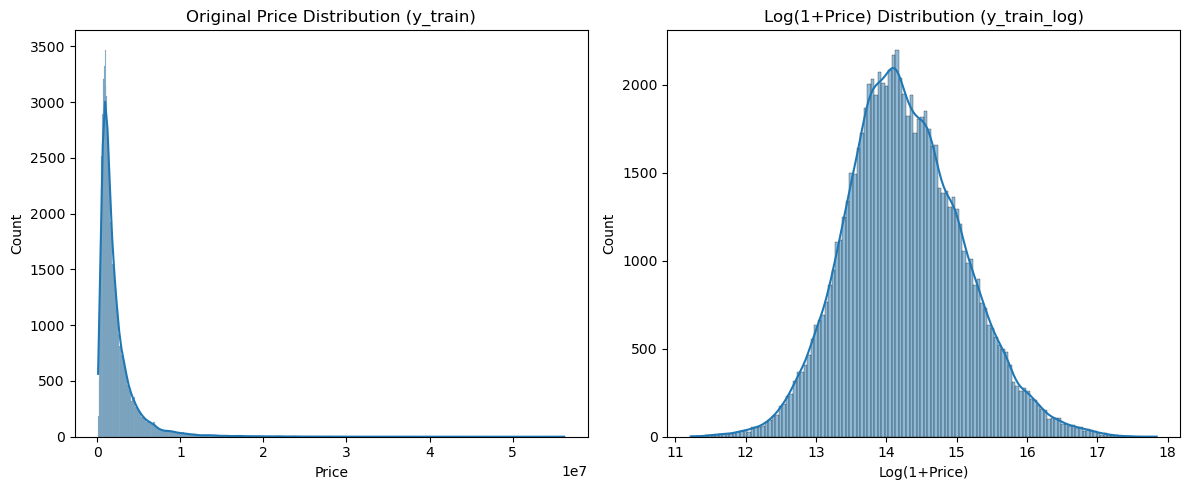


现在我们的目标变量是 y_train_log 和 y_val_log。
记得在最后评估时使用 np.expm1() 将预测结果转换回来！


In [26]:
import matplotlib.pyplot as plt

print("--- 开始对目标变量 y (Price) 进行 Log Transformation ---")

# --- 1. 应用 np.log1p() ---
# 我们直接在 y_train 和 y_val 上操作
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

print("已成功对 y_train 和 y_val 应用 log1p 转换。")

# --- 2. 可视化对比 ---

plt.figure(figsize=(12, 5))

# 图 1: 原始 Price 的分布
plt.subplot(1, 2, 1)
sns.histplot(y_train, kde=True)
plt.title('Original Price Distribution (y_train)')
plt.xlabel('Price')

# 图 2: Log(1+Price) 的分布
plt.subplot(1, 2, 2)
sns.histplot(y_train_log, kde=True)
plt.title('Log(1+Price) Distribution (y_train_log)')
plt.xlabel('Log(1+Price)')

plt.tight_layout() # 调整布局防止重叠
plt.show()

# --- 3. 更新我们的目标变量 ---
# 我们使用新变量名 y_train_log, y_val_log

print("\n现在我们的目标变量是 y_train_log 和 y_val_log。")
print("记得在最后评估时使用 np.expm1() 将预测结果转换回来！")

In [27]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

print("--- 目标编码准备：计算全局均值 ---")
quantified_group1 = ['交通出行', '周边配套', '核心卖点'] 
quantified_group2 = ['建筑年代', '房屋总数', '物 业 费', '交易时间', '上次交易']
decided_to_drop = ['开发商', '物业公司'] # 也删除我们不用的 ID
advanced_quantified = ['房屋户型', '所在楼层', '梯户比例', '绿 化 率', '燃气费', '停车费用', '楼栋总数']
all_object_cols_to_drop = quantified_group1 + quantified_group2 + decided_to_drop + advanced_quantified
cols_to_drop_final_step = [col for col in all_object_cols_to_drop if col in X_train.columns] # 只删除存在的

X_train_pre_TE = X_train.drop(columns=cols_to_drop_final_step, errors='ignore').copy()
X_val_pre_TE = X_val.drop(columns=cols_to_drop_final_step, errors='ignore').copy()
X_test_price_pre_TE = X_test_price.drop(columns=cols_to_drop_final_step, errors='ignore').copy()
print("最终清理完成 (保留数值 ID 用于 TE)。")
print(f"清理后维度 (TE 之前): {X_train_pre_TE.shape}") # 应该接近 53 列

# --- 7. 计算 Log Target ---
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

# --- 8. 计算全局均值 (用于平滑) ---
global_mean_log_price = y_train_log.mean()
print(f"\n全局平均对数价格 (Global Mean for Smoothing): {global_mean_log_price:.4f}")

print("\n--- 重置状态完成，准备进行目标编码 ---")

--- 目标编码准备：计算全局均值 ---
最终清理完成 (保留数值 ID 用于 TE)。
清理后维度 (TE 之前): (83096, 53)

全局平均对数价格 (Global Mean for Smoothing): 14.2646

--- 重置状态完成，准备进行目标编码 ---


In [28]:
print("--- 步骤 6.7 (TE): 开始对 '城市' 进行目标编码 + 平滑 ---")

# --- 1. 准备数据 (合并 X_train 和 y_train 以便分组计算) ---
# (确保 X_train_pre_TE 和 y_train_log 索引一致)
train_data_for_encoding = pd.concat([X_train_pre_TE, y_train_log], axis=1)
# 确保目标列名正确 (y_train_log 是 Series，其 name 属性通常是 'Price' 或 None)
target_col_name = y_train_log.name if y_train_log.name is not None else 'Price' # 获取 Series 的名字

# --- 2. 计算每个城市的均值和计数 (仅基于训练集) ---
city_stats = train_data_for_encoding.groupby('城市')[target_col_name].agg(['mean', 'count'])
print(f"从训练集中计算了 {len(city_stats)} 个城市的统计信息。")

# --- 3. 定义平滑参数和全局均值 ---
m = 20  # 平滑因子 (可以调整)
global_mean = global_mean_log_price # 使用之前计算的值

# --- 4. 应用平滑公式计算 TE_City ---
city_stats['TE_City_Smoothed'] = (city_stats['count'] * city_stats['mean'] + m * global_mean) / (city_stats['count'] + m)

# --- 5. 创建编码映射字典 ---
# 我们只需要 'TE_City_Smoothed' 这一列
city_encoding_map = city_stats['TE_City_Smoothed'].to_dict()
print(f"创建了包含 {len(city_encoding_map)} 个城市的编码映射。")
# print(city_encoding_map) # 可以取消注释查看具体的编码值

# --- 6. 将编码映射应用到所有三个数据集 ---
print("正在将 TE_City 应用到 X_train, X_val, X_test...")

# (A) 应用到 X_train
# .map() 会根据 '城市' 列的值查找字典中的编码
# 对于训练集中存在的城市，这会直接应用计算好的平滑值
X_train_pre_TE['TE_City'] = X_train_pre_TE['城市'].map(city_encoding_map) 

# (B) 应用到 X_val
# .map() 会自动处理新城市 (在 map 中找不到的键) -> NaN
X_val_pre_TE['TE_City'] = X_val_pre_TE['城市'].map(city_encoding_map) 
# 用全局均值填充在训练集中未见过的新城市
X_val_pre_TE['TE_City'].fillna(global_mean, inplace=True) 

# (C) 应用到 X_test
X_test_price_pre_TE['TE_City'] = X_test_price_pre_TE['城市'].map(city_encoding_map) 
X_test_price_pre_TE['TE_City'].fillna(global_mean, inplace=True) 

# --- 7. (可选) 检查新特征 ---
print("\n--- TE_City 特征创建完毕 ---")
print("X_train_pre_TE['TE_City'] (前5行):")
print(X_train_pre_TE['TE_City'].head())
print("\nX_val_pre_TE['TE_City'] (前5行，可能包含全局均值填充):")
print(X_val_pre_TE['TE_City'].head())

# 检查是否有 NaN (应该没有了)
print(f"\nX_train 中 TE_City 的 NaN 数量: {X_train_pre_TE['TE_City'].isnull().sum()}")
print(f"X_val 中 TE_City 的 NaN 数量: {X_val_pre_TE['TE_City'].isnull().sum()}")
print(f"X_test 中 TE_City 的 NaN 数量: {X_test_price_pre_TE['TE_City'].isnull().sum()}")

--- 步骤 6.7 (TE): 开始对 '城市' 进行目标编码 + 平滑 ---
从训练集中计算了 12 个城市的统计信息。
创建了包含 12 个城市的编码映射。
正在将 TE_City 应用到 X_train, X_val, X_test...

--- TE_City 特征创建完毕 ---
X_train_pre_TE['TE_City'] (前5行):
20486    13.741883
53134    14.378936
8277     15.117574
45156    13.772659
99942    14.389813
Name: TE_City, dtype: float64

X_val_pre_TE['TE_City'] (前5行，可能包含全局均值填充):
92052    14.389813
22088    13.741883
91045    14.389813
23282    13.772659
34552    13.772659
Name: TE_City, dtype: float64

X_train 中 TE_City 的 NaN 数量: 0
X_val 中 TE_City 的 NaN 数量: 0
X_test 中 TE_City 的 NaN 数量: 0


In [29]:
print("\n--- 步骤 6.7 (TE): 开始对 '区域' 进行目标编码 + 平滑 ---")

# --- 1. 准备数据 (确保 train_data_for_encoding 仍然包含 y_train_log) ---
try:
    if target_col_name not in train_data_for_encoding.columns:
         train_data_for_encoding = pd.concat([X_train_pre_TE, y_train_log], axis=1)
except NameError:
     train_data_for_encoding = pd.concat([X_train_pre_TE, y_train_log], axis=1)
     target_col_name = y_train_log.name if y_train_log.name is not None else 'Price'

# --- 2. 计算每个区域的均值和计数 (仅基于训练集) ---
district_stats = train_data_for_encoding.groupby('区域')[target_col_name].agg(['mean', 'count'])
print(f"从训练集中计算了 {len(district_stats)} 个区域的统计信息。")

# --- 3. 定义平滑参数和全局均值 (保持不变) ---
m = 20  # 平滑因子
# global_mean 应该仍然是 14.2646

# --- 4. 应用平滑公式计算 TE_District ---
district_stats['TE_District_Smoothed'] = (district_stats['count'] * district_stats['mean'] + m * global_mean) / (district_stats['count'] + m)

# --- 5. 创建编码映射字典 ---
district_encoding_map = district_stats['TE_District_Smoothed'].to_dict()
print(f"创建了包含 {len(district_encoding_map)} 个区域的编码映射。")

# --- 6. 将编码映射应用到所有三个数据集 ---
print("正在将 TE_District 应用到 X_train, X_val, X_test...")

X_train_pre_TE['TE_District'] = X_train_pre_TE['区域'].map(district_encoding_map) 

X_val_pre_TE['TE_District'] = X_val_pre_TE['区域'].map(district_encoding_map) 
X_val_pre_TE['TE_District'].fillna(global_mean, inplace=True) # 用全局均值填充新区域

X_test_price_pre_TE['TE_District'] = X_test_price_pre_TE['区域'].map(district_encoding_map) 
X_test_price_pre_TE['TE_District'].fillna(global_mean, inplace=True) # 用全局均值填充新区域

# --- 7. (可选) 检查新特征 ---
print("\n--- TE_District 特征创建完毕 ---")
print("X_train_pre_TE['TE_District'] (前5行):")
print(X_train_pre_TE['TE_District'].head())

# 检查是否有 NaN
print(f"\nX_train 中 TE_District 的 NaN 数量: {X_train_pre_TE['TE_District'].isnull().sum()}")
print(f"X_val 中 TE_District 的 NaN 数量: {X_val_pre_TE['TE_District'].isnull().sum()}")
print(f"X_test 中 TE_District 的 NaN 数量: {X_test_price_pre_TE['TE_District'].isnull().sum()}")


--- 步骤 6.7 (TE): 开始对 '区域' 进行目标编码 + 平滑 ---
从训练集中计算了 115 个区域的统计信息。
创建了包含 115 个区域的编码映射。
正在将 TE_District 应用到 X_train, X_val, X_test...

--- TE_District 特征创建完毕 ---
X_train_pre_TE['TE_District'] (前5行):
20486    13.659887
53134    14.545506
8277     15.512856
45156    14.011839
99942    14.989314
Name: TE_District, dtype: float64

X_train 中 TE_District 的 NaN 数量: 0
X_val 中 TE_District 的 NaN 数量: 0
X_test 中 TE_District 的 NaN 数量: 0


In [30]:
import pandas as pd
import numpy as np

print("\n--- 步骤 6.7 (TE): 开始对 '板块' 进行目标编码 + 分层平滑 ---")

# --- 1. 确保 train_data_for_encoding 包含 y_train_log ---
try:
    if target_col_name not in train_data_for_encoding.columns:
         train_data_for_encoding = pd.concat([X_train_pre_TE, y_train_log], axis=1)
except NameError:
     train_data_for_encoding = pd.concat([X_train_pre_TE, y_train_log], axis=1)
     target_col_name = y_train_log.name if y_train_log.name is not None else 'Price'

# --- 2. 计算每个板块的均值和计数 (仅基于训练集) ---
#    (我们需要同时知道板块所属的区域，所以按 ['区域', '板块'] 分组)
block_stats = train_data_for_encoding.groupby(['区域', '板块'])[target_col_name].agg(['mean', 'count'])
print(f"从训练集中计算了 {len(block_stats)} 个板块的统计信息。")

# --- 3. 获取区域的原始均值 (用于平滑) ---
#    (district_stats 变量应该还存在，包含 'mean' 列)
try:
    district_mean_map = district_stats['mean'].to_dict() # 使用原始均值
except NameError:
    print("错误：district_stats 未定义，请确保上一步已运行。")
    # 停止
    
# --- 4. 应用分层平滑公式计算 TE_Block_Stratified ---
m = 20  # 平滑因子
# global_mean 仍然是全局均值

# 定义一个函数来应用分层平滑
def stratified_smooth(row, district_means, global_m, global_mean):
    block_mean = row['mean']
    block_count = row['count']
    # 从 MultiIndex (区域, 板块) 中获取区域 ID
    district_id = row.name[0] 
    # 获取该区域的原始均值，如果区域未知则用全局均值
    district_mean = district_means.get(district_id, global_mean) 
    
    smoothed_mean = (block_count * block_mean + global_m * district_mean) / (block_count + global_m)
    return smoothed_mean

print("正在计算分层平滑编码...")
# .apply() 在 DataFrame 上按行应用函数
block_stats['TE_Block_Stratified'] = block_stats.apply(
    stratified_smooth, 
    axis=1, # 按行应用
    district_means=district_mean_map, 
    global_m=m, 
    global_mean=global_mean
)

# --- 5. 创建编码映射字典 (使用 MultiIndex) ---
#    (键是 (区域ID, 板块ID) 的元组)
block_encoding_map = block_stats['TE_Block_Stratified'].to_dict()
print(f"创建了包含 {len(block_encoding_map)} 个板块的分层平滑编码映射。")

# --- 6. 将编码映射应用到所有三个数据集 ---
print("正在将 TE_Block_Stratified 应用到 X_train, X_val, X_test...")

# 定义一个辅助函数来应用映射，处理新板块/新区域
def apply_block_encoding(row, block_map, district_map_smoothed, global_mean_val):
    district_id = row['区域']
    block_id = row['板块']
    key = (district_id, block_id)
    
    # 1. 尝试直接用 (区域, 板块) 查找
    block_value = block_map.get(key)
    if block_value is not None:
        return block_value
    else:
        # 2. 如果板块未见过，尝试用区域的平滑均值 (TE_District)
        district_value = district_map_smoothed.get(district_id)
        if district_value is not None:
            return district_value # 返回区域的 TE 值
        else:
            # 3. 如果区域也未见过，使用全局均值
            return global_mean_val

# district_encoding_map 包含区域的平滑编码 (TE_District)
# (确保它仍然存在)
try:
    district_encoding_map
except NameError:
    print("错误：district_encoding_map 未定义！")
    # 停止

# (A) 应用到 X_train (理论上所有板块都在 map 中)
X_train_pre_TE['TE_Block_Stratified'] = X_train_pre_TE.apply(
    apply_block_encoding, axis=1, 
    block_map=block_encoding_map, 
    district_map_smoothed=district_encoding_map, # 用于备用填充
    global_mean_val=global_mean
)

# (B) 应用到 X_val (需要处理新板块/区域)
X_val_pre_TE['TE_Block_Stratified'] = X_val_pre_TE.apply(
    apply_block_encoding, axis=1, 
    block_map=block_encoding_map, 
    district_map_smoothed=district_encoding_map, 
    global_mean_val=global_mean
)

# (C) 应用到 X_test (需要处理新板块/区域)
X_test_price_pre_TE['TE_Block_Stratified'] = X_test_price_pre_TE.apply(
    apply_block_encoding, axis=1, 
    block_map=block_encoding_map, 
    district_map_smoothed=district_encoding_map, 
    global_mean_val=global_mean
)

# --- 7. (可选) 检查新特征 ---
print("\n--- TE_Block_Stratified 特征创建完毕 ---")
print("X_train_pre_TE['TE_Block_Stratified'] (前5行):")
print(X_train_pre_TE['TE_Block_Stratified'].head())

# 检查是否有 NaN (应该没有了)
print(f"\nX_train 中 TE_Block_Stratified 的 NaN 数量: {X_train_pre_TE['TE_Block_Stratified'].isnull().sum()}")
print(f"X_val 中 TE_Block_Stratified 的 NaN 数量: {X_val_pre_TE['TE_Block_Stratified'].isnull().sum()}")
print(f"X_test 中 TE_Block_Stratified 的 NaN 数量: {X_test_price_pre_TE['TE_Block_Stratified'].isnull().sum()}")


--- 步骤 6.7 (TE): 开始对 '板块' 进行目标编码 + 分层平滑 ---
从训练集中计算了 1026 个板块的统计信息。
正在计算分层平滑编码...
创建了包含 1026 个板块的分层平滑编码映射。
正在将 TE_Block_Stratified 应用到 X_train, X_val, X_test...

--- TE_Block_Stratified 特征创建完毕 ---
X_train_pre_TE['TE_Block_Stratified'] (前5行):
20486    13.578721
53134    15.008319
8277     15.773642
45156    13.725297
99942    15.318706
Name: TE_Block_Stratified, dtype: float64

X_train 中 TE_Block_Stratified 的 NaN 数量: 0
X_val 中 TE_Block_Stratified 的 NaN 数量: 0
X_test 中 TE_Block_Stratified 的 NaN 数量: 0


In [31]:
print("\n--- 清理原始 ID 列 ('城市', '区域', '板块') ---")

# --- 1. 定义要移除的原始 ID 列 ---
original_id_cols_to_drop = ['城市', '区域', '板块']

# --- 2. 从三个数据集中移除 ---
try:
    # 检查列是否存在，然后删除
    cols_present_train = [col for col in original_id_cols_to_drop if col in X_train_pre_TE.columns]
    if cols_present_train: # 只有当列存在时才删除
        X_train_post_TE = X_train_pre_TE.drop(columns=cols_present_train)
        X_val_post_TE = X_val_pre_TE.drop(columns=cols_present_train)
        X_test_price_post_TE = X_test_price_pre_TE.drop(columns=cols_present_train)
        print(f"已从数据集中移除原始 ID 列: {cols_present_train}")
    else:
         X_train_post_TE = X_train_pre_TE.copy() # 如果列不存在，保持不变
         X_val_post_TE = X_val_pre_TE.copy()
         X_test_price_post_TE = X_test_price_pre_TE.copy()
         print("原始 ID 列在数据集中未找到，可能已被删除。")

    # --- 3. 检查最终维度 ---
    print(f"\n清理原始 ID 列后的维度:")
    print(f"X_train: {X_train_post_TE.shape}") # 列数应为 53 + 3 (TE features) - 3 (Original IDs) = 53
    print(f"X_val:   {X_val_post_TE.shape}")
    print(f"X_test:  {X_test_price_post_TE.shape}")

    # --- 4. (可选) 确认列已移除 ---
    # print(f"'城市' 是否仍在 X_train 中? {'城市' in X_train_post_TE.columns}") 

except NameError:
     print("错误：无法找到 X_train_pre_TE。请确保之前的步骤已成功运行。")

print("\n--- 原始 ID 列清理完毕 ---")


--- 清理原始 ID 列 ('城市', '区域', '板块') ---
已从数据集中移除原始 ID 列: ['城市', '区域', '板块']

清理原始 ID 列后的维度:
X_train: (83096, 53)
X_val:   (20775, 53)
X_test:  (34017, 53)

--- 原始 ID 列清理完毕 ---


In [32]:
print("--- (多标签)处理 '房屋朝向' ---")

# --- 1. 定义基本朝向标签 ---
orientation_labels = ['东', '南', '西', '北', '东北', '东南', '西北', '西南']
print(f"将基于以下 {len(orientation_labels)} 个基本朝向创建指示变量...")

# --- 2. 执行多标签二值化 ---
try:
    if 'X_train_post_TE' not in locals(): raise NameError("X_train_post_TE not defined")

    # 对每个数据集进行操作
    for df in [X_train_post_TE, X_val_post_TE, X_test_price_post_TE]:
        if '房屋朝向' not in df.columns:
            print("警告：'房屋朝向' 列不在数据集中，跳过处理。")
            continue
            
        # 对每个基本标签创建新列
        for label in orientation_labels:
            new_col_name = f'Orientation_{label}'
            # 检查原始字符串是否包含该标签 (忽略 'Unknown')
            # 使用 .astype(str) 确保是字符串类型
            df[new_col_name] = df['房屋朝向'].astype(str).apply(
                lambda x: 1 if label in x and x != 'Unknown' else 0
            )

    print("已为 '房屋朝向' 创建了指示变量列。")

    # --- 3. 移除原始 '房屋朝向' 列 ---
    print("正在移除原始 '房屋朝向' 列...")
    if '房屋朝向' in X_train_post_TE.columns:
        X_train_post_TE.drop(columns=['房屋朝向'], inplace=True)
        X_val_post_TE.drop(columns=['房屋朝向'], inplace=True)
        X_test_price_post_TE.drop(columns=['房屋朝向'], inplace=True)
        print("原始列移除完毕。")
    else:
        print("原始 '房屋朝向' 列已不存在。")

    # --- 4. 检查结果 ---
    new_orientation_cols = [f'Orientation_{label}' for label in orientation_labels]
    print("\n--- 新创建的朝向特征 (X_train, 前5行) ---")
    # 过滤一下，只看存在的列
    present_new_cols = [col for col in new_orientation_cols if col in X_train_post_TE.columns]
    if present_new_cols:
         print(X_train_post_TE[present_new_cols].head())
    else:
         print("未找到新创建的朝向列。")
         
    print(f"\n处理后 X_train_post_TE 维度: {X_train_post_TE.shape}") 
    # 列数 = (原来的列数 - 1 + 8) 

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"处理房屋朝向时发生意外错误: {e}")

--- (多标签)处理 '房屋朝向' ---
将基于以下 8 个基本朝向创建指示变量...
已为 '房屋朝向' 创建了指示变量列。
正在移除原始 '房屋朝向' 列...
原始列移除完毕。

--- 新创建的朝向特征 (X_train, 前5行) ---
       Orientation_东  Orientation_南  Orientation_西  Orientation_北  \
20486              0              1              0              1   
53134              0              1              0              0   
8277               0              1              0              0   
45156              1              1              0              0   
99942              0              1              0              0   

       Orientation_东北  Orientation_东南  Orientation_西北  Orientation_西南  
20486               0               0               0               0  
53134               0               0               0               0  
8277                0               0               0               0  
45156               0               1               0               0  
99942               0               0               0               0  

处理后 X_train_post_TE 维度: (

In [33]:
print("\n--- (多标签)处理 '房屋优势' ---")

# --- 1. 定义基本优势标签 ---
#    (基于常见描述和之前的 OHE 输出推断)
advantage_labels = ['地铁', '装修', '房本满两年', '房本满五年'] 
#    (注意：'房本满两年' 和 '房本满五年' 有包含关系，
#     但分开做指示变量通常没问题，模型可以学习到)
print(f"将基于以下 {len(advantage_labels)} 个基本优势创建指示变量...")

# --- 2. 执行多标签二值化 ---
try:
    if 'X_train_post_TE' not in locals(): raise NameError("X_train_post_TE not defined")

    # 对每个数据集进行操作
    for df in [X_train_post_TE, X_val_post_TE, X_test_price_post_TE]:
        if '房屋优势' not in df.columns:
            print("警告：'房屋优势' 列不在数据集中，跳过处理。")
            continue
            
        # 对每个基本标签创建新列
        for label in advantage_labels:
            # 简化列名
            if label == '房本满两年': 
                new_col_name = 'Advantage_满2年'
            elif label == '房本满五年':
                new_col_name = 'Advantage_满5年'
            else:
                new_col_name = f'Advantage_{label}'
                
            # 检查原始字符串是否包含该标签 (忽略 'Unknown' 和空的 '、')
            df[new_col_name] = df['房屋优势'].astype(str).apply(
                lambda x: 1 if label in x and x != 'Unknown' and x != '、' else 0
            )
            
    print("已为 '房屋优势' 创建了指示变量列。")

    # --- 3. 移除原始 '房屋优势' 列 ---
    print("正在移除原始 '房屋优势' 列...")
    if '房屋优势' in X_train_post_TE.columns:
        X_train_post_TE.drop(columns=['房屋优势'], inplace=True)
        X_val_post_TE.drop(columns=['房屋优势'], inplace=True)
        X_test_price_post_TE.drop(columns=['房屋优势'], inplace=True)
        print("原始列移除完毕。")
    else:
        print("原始 '房屋优势' 列已不存在。")

    print(f"\n处理后 X_train_post_TE 维度: {X_train_post_TE.shape}") 
    # 列数 = (原来的列数 - 1 + 4) 

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"处理房屋优势时发生意外错误: {e}")


--- (多标签)处理 '房屋优势' ---
将基于以下 4 个基本优势创建指示变量...
已为 '房屋优势' 创建了指示变量列。
正在移除原始 '房屋优势' 列...
原始列移除完毕。

处理后 X_train_post_TE 维度: (83096, 63)


In [34]:
import pandas as pd
import numpy as np
from collections import Counter
import re

print("\n--- (多标签)处理 '物业类别' ---")

# --- 1. 查找并定义基本物业类型标签 ---
try:
    if 'X_train_post_TE' not in locals(): raise NameError("X_train_post_TE not defined")

    # 定义一个简单的清洗函数，处理 "公寓（住宅）" -> "公寓"
    def clean_prop_type(ptype):
        ptype = ptype.strip()
        # 移除括号内容，例如 公寓（住宅） -> 公寓
        ptype = re.sub(r'\（[^）]*\）', '', ptype) 
        ptype = re.sub(r'\([^)]*\)', '', ptype) 
        # 可以添加更多清洗规则
        return ptype

    # 找出所有非 Unknown 值，拆分，清洗，并统计频率
    all_base_types = Counter()
    valid_prop_types = X_train_post_TE[X_train_post_TE['物业类别'] != 'Unknown']['物业类别']
    
    for prop_string in valid_prop_types:
        parts = prop_string.split('/')
        cleaned_parts = set(clean_prop_type(part) for part in parts if clean_prop_type(part)) # 使用 set 去重
        all_base_types.update(cleaned_parts)

    # 决定保留哪些基本标签（全部保留）
    min_frequency = 1
    prop_type_labels = sorted([label for label, count in all_base_types.items() if count >= min_frequency])
    
    # 将频率低的归入 'Other' 
    prop_type_labels.append('PropType_Other') # 添加 'Other' 类别
    
    print(f"将基于以下 {len(prop_type_labels)} 个基本物业类型 (频率 >= {min_frequency} 或 Other) 创建指示变量:")
    print(prop_type_labels)

    # --- 2. 执行多标签二值化 ---
    print("正在创建物业类型指示变量...")
    # 对每个数据集进行操作
    for df in [X_train_post_TE, X_val_post_TE, X_test_price_post_TE]:
        if '物业类别' not in df.columns:
            print("警告：'物业类别' 列不在数据集中，跳过处理。")
            continue
            
        temp_other_col = [] # 临时存储是否属于 Other
        
        # 对每个保留的基本标签创建新列
        for label in prop_type_labels:
            if label == 'PropType_Other': continue # Other 列最后处理
                
            new_col_name = f'PropType_{label}'
            
            # 定义检查函数
            def check_label(prop_string, target_label):
                if prop_string == 'Unknown': return 0
                parts = prop_string.split('/')
                cleaned_parts = [clean_prop_type(part) for part in parts if clean_prop_type(part)]
                return 1 if target_label in cleaned_parts else 0

            df[new_col_name] = df['物业类别'].apply(check_label, target_label=label)
            
        # 处理 Other 列：如果一行数据的所有已知标签列都为 0 (且原始值不是 Unknown)
        known_prop_type_cols = [f'PropType_{l}' for l in prop_type_labels if l != 'PropType_Other']
        # 计算已知标签的和
        known_labels_sum = df[known_prop_type_cols].sum(axis=1)
        # 如果原始值不是 Unknown 且所有已知标签都为 0，则属于 Other
        is_other = (df['物业类别'] != 'Unknown') & (known_labels_sum == 0)
        df['PropType_Other'] = is_other.astype(int)

    print("已为 '物业类别' 创建了指示变量列。")

    # --- 3. 移除原始 '物业类别' 列 ---
    print("正在移除原始 '物业类别' 列...")
    if '物业类别' in X_train_post_TE.columns:
        X_train_post_TE.drop(columns=['物业类别'], inplace=True)
        X_val_post_TE.drop(columns=['物业类别'], inplace=True)
        X_test_price_post_TE.drop(columns=['物业类别'], inplace=True)
        print("原始列移除完毕。")
    else:
        print("原始 '物业类别' 列已不存在。")
         
    print(f"\n处理后 X_train_post_TE 维度: {X_train_post_TE.shape}") 
    # 列数 = (原来的列数 - 1 + len(prop_type_labels))

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"处理物业类别时发生意外错误: {e}")


--- (多标签)处理 '物业类别' ---
将基于以下 26 个基本物业类型 (频率 >= 1 或 Other) 创建指示变量:
['人防车位', '住宅', '住宅式公寓', '公寓', '写字楼', '别墅', '单身公寓', '商业', '商业办公类', '商住两用', '商务公寓', '商务型公寓', '四合院', '地下仓储', '工业厂房', '平房', '库房', '底商', '新式里弄', '旧式里弄', '普通住宅', '老公寓', '花园洋房', '车库', '酒店式公寓', 'PropType_Other']
正在创建物业类型指示变量...
已为 '物业类别' 创建了指示变量列。
正在移除原始 '物业类别' 列...
原始列移除完毕。

处理后 X_train_post_TE 维度: (83096, 88)


In [35]:
import pandas as pd
import numpy as np
from collections import Counter
import re

print("\n--- (多标签)处理 '建筑结构_comm' ---")

# --- 1. 查找并定义基本建筑结构标签 ---
try:
    if 'X_train_post_TE' not in locals(): raise NameError("X_train_post_TE not defined")
    
    # 清洗函数 (可能不需要复杂清洗)
    def clean_structure_type(stype):
        return stype.strip()

    # 找出所有非 Unknown 值，拆分，清洗，并统计频率
    all_base_structures = Counter()
    # 确保列名正确
    structure_col = '建筑结构_comm' 
    if structure_col not in X_train_post_TE.columns:
         print(f"警告：列 '{structure_col}' 不存在，跳过处理。")
         # 如果列不存在，跳到下一步
         structure_labels = [] # 定义空列表以防后续代码出错
    else:
        valid_structure_types = X_train_post_TE[X_train_post_TE[structure_col] != 'Unknown'][structure_col]
        
        for structure_string in valid_structure_types:
            parts = structure_string.split('/')
            cleaned_parts = set(clean_structure_type(part) for part in parts if clean_structure_type(part))
            all_base_structures.update(cleaned_parts)

        # 决定保留哪些基本标签 
        # 基数不高（约16），我们可能可以保留所有非空的标签
        structure_labels = sorted([label for label, count in all_base_structures.items() if label]) 
        
        
        print(f"将基于以下 {len(structure_labels)} 个基本建筑结构创建指示变量:")
        print(structure_labels)

        # --- 2. 执行多标签二值化 ---
        print("正在创建建筑结构指示变量...")
        # 对每个数据集进行操作
        for df in [X_train_post_TE, X_val_post_TE, X_test_price_post_TE]:
            if structure_col not in df.columns: continue # 如果列不存在则跳过
                
            temp_other_col = [] # 如果使用 Other
            
            # 对每个保留的基本标签创建新列
            for label in structure_labels:
                # if label == 'StructComm_Other': continue # 如果使用 Other
                    
                new_col_name = f'StructComm_{label}'
                
                # 定义检查函数
                def check_struct_label(struct_string, target_label):
                    if struct_string == 'Unknown': return 0
                    parts = struct_string.split('/')
                    cleaned_parts = [clean_structure_type(part) for part in parts if clean_structure_type(part)]
                    return 1 if target_label in cleaned_parts else 0

                df[new_col_name] = df[structure_col].apply(check_struct_label, target_label=label)
                

        print("已为 '建筑结构_comm' 创建了指示变量列。")

        # --- 3. 移除原始 '建筑结构_comm' 列 ---
        print(f"正在移除原始 '{structure_col}' 列...")
        if structure_col in X_train_post_TE.columns:
            X_train_post_TE.drop(columns=[structure_col], inplace=True)
            X_val_post_TE.drop(columns=[structure_col], inplace=True)
            X_test_price_post_TE.drop(columns=[structure_col], inplace=True)
            print("原始列移除完毕。")
        else:
            print(f"原始 '{structure_col}' 列已不存在。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"处理建筑结构_comm时发生意外错误: {e}")


print(f"\n处理后 X_train_post_TE 维度: {X_train_post_TE.shape}") 
# 列数 = (原来的列数 - 1 + len(structure_labels))


--- (多标签)处理 '建筑结构_comm' ---
将基于以下 4 个基本建筑结构创建指示变量:
['塔板结合', '塔楼', '平房', '板楼']
正在创建建筑结构指示变量...
已为 '建筑结构_comm' 创建了指示变量列。
正在移除原始 '建筑结构_comm' 列...
原始列移除完毕。

处理后 X_train_post_TE 维度: (83096, 91)


In [36]:
import pandas as pd
import numpy as np
from collections import Counter
import re

print("\n--- (多标签)处理 '产权描述' ---")

# --- 1. 查找并定义基本产权类型标签 ---
try:
    if 'X_train_post_TE' not in locals(): raise NameError("X_train_post_TE not defined")
    
    # 清洗函数 (可能不需要)
    def clean_right_type(rtype):
        return rtype.strip()

    # 找出所有非 Unknown 值，拆分，清洗，并统计频率
    all_base_rights = Counter()
    right_col = '产权描述' 
    if right_col not in X_train_post_TE.columns:
         print(f"警告：列 '{right_col}' 不存在，跳过处理。")
         right_labels = [] 
    else:
        valid_right_types = X_train_post_TE[X_train_post_TE[right_col] != 'Unknown'][right_col]
        
        for right_string in valid_right_types:
            parts = right_string.split('/')
            cleaned_parts = set(clean_right_type(part) for part in parts if clean_right_type(part))
            all_base_rights.update(cleaned_parts)

        # 决定保留哪些基本标签 (全部保留)
        min_frequency_right = 1
        right_labels = sorted([label for label, count in all_base_rights.items() if count >= min_frequency_right and label])
        
        # 添加 'Other' 类别
        right_labels.append('Rights_Other')
        
        print(f"将基于以下 {len(right_labels)} 个基本产权类型 (频率 >= {min_frequency_right} 或 Other) 创建指示变量:")
        print(right_labels)

        # --- 2. 执行多标签二值化 ---
        print("正在创建产权描述指示变量...")
        # 对每个数据集进行操作
        for df in [X_train_post_TE, X_val_post_TE, X_test_price_post_TE]:
            if right_col not in df.columns: continue 
                
            temp_other_col = [] 
            
            # 对每个保留的基本标签创建新列
            for label in right_labels:
                if label == 'Rights_Other': continue 
                    
                new_col_name = f'Rights_{label}'
                
                # 定义检查函数
                def check_right_label(right_string, target_label):
                    if right_string == 'Unknown': return 0
                    parts = right_string.split('/')
                    cleaned_parts = [clean_right_type(part) for part in parts if clean_right_type(part)]
                    return 1 if target_label in cleaned_parts else 0

                df[new_col_name] = df[right_col].apply(check_right_label, target_label=label)
                
            # 处理 Other 列
            known_right_cols = [f'Rights_{l}' for l in right_labels if l != 'Rights_Other']
            known_labels_sum = df[known_right_cols].sum(axis=1)
            is_other = (df[right_col] != 'Unknown') & (known_labels_sum == 0)
            df['Rights_Other'] = is_other.astype(int)

        print("已为 '产权描述' 创建了指示变量列。")

        # --- 3. 移除原始 '产权描述' 列 ---
        print(f"正在移除原始 '{right_col}' 列...")
        if right_col in X_train_post_TE.columns:
            X_train_post_TE.drop(columns=[right_col], inplace=True)
            X_val_post_TE.drop(columns=[right_col], inplace=True)
            X_test_price_post_TE.drop(columns=[right_col], inplace=True)
            print("原始列移除完毕。")
        else:
            print(f"原始 '{right_col}' 列已不存在。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"处理产权描述时发生意外错误: {e}")
         
print(f"\n处理后 X_train_post_TE 维度: {X_train_post_TE.shape}") 
# 列数 = (原来的列数 - 1 + len(right_labels))


--- (多标签)处理 '产权描述' ---
将基于以下 25 个基本产权类型 (频率 >= 1 或 Other) 创建指示变量:
['一类经济适用房', '乡产', '二类经济适用房', '使用权', '公租房', '共有产权房', '军产', '动迁安置房', '售后公房', '商品房', '回迁房', '央产房', '宅基房', '定向安置房', '已购公房', '廉租房', '房改房', '拆迁还建房', '校产', '私产', '经济适用房', '自住型商品房', '限价商品房', '集资房', 'Rights_Other']
正在创建产权描述指示变量...
已为 '产权描述' 创建了指示变量列。
正在移除原始 '产权描述' 列...
原始列移除完毕。

处理后 X_train_post_TE 维度: (83096, 115)


In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # 导入绘图库

print("--- 地理聚类 步骤 1: 准备并缩放坐标数据 ---")

# --- 1. 定义坐标列 ---
coord_cols = ['lon', 'lat']

try:
    # 确保操作的是正确的 DataFrame
    if 'X_train_post_TE' not in locals(): raise NameError("X_train_post_TE 未定义")
    if 'X_val_post_TE' not in locals(): raise NameError("X_val_post_TE 未定义")
    if 'X_test_price_post_TE' not in locals(): raise NameError("X_test_price_post_TE 未定义")
    
    # --- 2. 提取坐标数据 ---
    # (只在坐标存在且非空的数据上进行训练)
    X_train_coords = X_train_post_TE[coord_cols].dropna()
    # (X_val 和 X_test 上的坐标也会在后续被转换)
    print(f"从 X_train 中提取了 {len(X_train_coords)} 行有效的坐标数据用于训练聚类模型。")

    # --- 3. 初始化并 Fit 缩放器 ---
    # K-Means 对尺度敏感，必须先缩放
    coord_scaler = StandardScaler()
    print("正在 Fit 坐标缩放器 (StandardScaler)...")
    # 只在训练集的坐标上 Fit
    coord_scaler.fit(X_train_coords) 

    # --- 4. 转换(Scale)所有三个数据集的坐标 ---
    #    (创建新的变量来存储缩放后的坐标)
    print("正在缩放 X_train, X_val, X_test 的坐标...")
    # (这里的 .loc 是为了安全地处理原始 DataFrame)
    X_train_coords_scaled = coord_scaler.transform(X_train_post_TE[coord_cols])
    X_val_coords_scaled = coord_scaler.transform(X_val_post_TE[coord_cols])
    X_test_coords_scaled = coord_scaler.transform(X_test_price_post_TE[coord_cols])
    
    print("坐标数据准备和缩放完毕。")
    print(f"X_train_coords_scaled 维度: {X_train_coords_scaled.shape}")

except NameError as e:
     print(f"🚨 错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except KeyError as e:
     print(f"🚨 错误：列 '{e}' 缺失。请检查 'lon' 和 'lat' 是否存在。")
except Exception as e:
     print(f"🚨 准备坐标数据时发生意外错误: {e}")

--- 地理聚类 步骤 1: 准备并缩放坐标数据 ---
从 X_train 中提取了 83096 行有效的坐标数据用于训练聚类模型。
正在 Fit 坐标缩放器 (StandardScaler)...
正在缩放 X_train, X_val, X_test 的坐标...
坐标数据准备和缩放完毕。
X_train_coords_scaled 维度: (83096, 2)


--- 地理聚类 步骤 2: 使用肘部法则寻找最佳 k ---
正在使用全部 83096 个训练样本点进行肘部法则计算...
  正在计算 k = 2...
  正在计算 k = 3...
  正在计算 k = 4...
  正在计算 k = 5...
  正在计算 k = 6...
  正在计算 k = 7...
  正在计算 k = 8...
  正在计算 k = 9...
  正在计算 k = 10...
  正在计算 k = 11...
  正在计算 k = 12...
  正在计算 k = 13...
  正在计算 k = 14...
  正在计算 k = 15...
  正在计算 k = 16...
  正在计算 k = 17...
  正在计算 k = 18...
  正在计算 k = 19...
  正在计算 k = 20...
WCSS 计算完毕。

--- 肘部法则图 (Elbow Method Plot) ---


C:\Users\31616\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31751 (\N{CJK UNIFIED IDEOGRAPH-7C07}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31616\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31616\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31616\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31616\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  fig.canvas.print_figure(bytes_

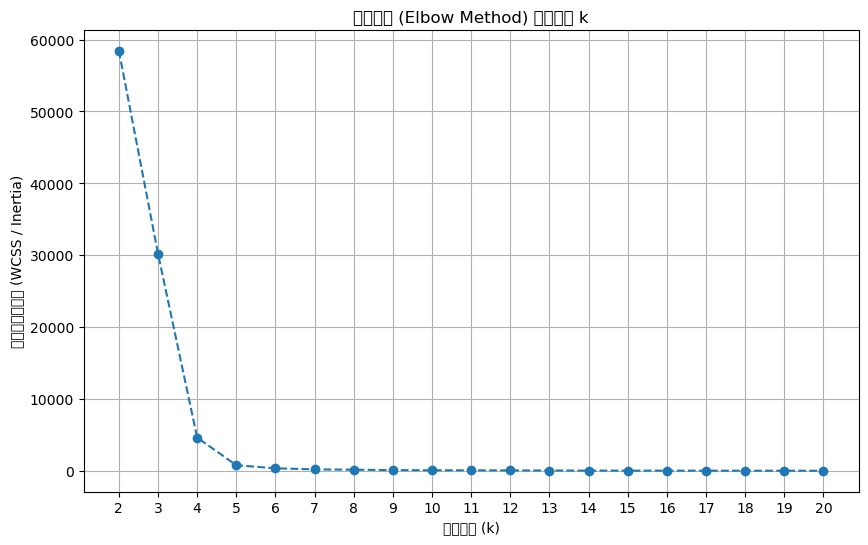

In [38]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("--- 地理聚类 步骤 2: 使用肘部法则寻找最佳 k ---")

# --- 1. 准备数据和参数 ---
try:
    # 确保缩放后的坐标数据存在
    if 'X_train_coords_scaled' not in locals(): 
        raise NameError("X_train_coords_scaled 未定义")
    
    
    data_for_elbow = X_train_coords_scaled
    print(f"正在使用全部 {len(data_for_elbow)} 个训练样本点进行肘部法则计算...")

    wcss = [] # 存储簇内误差平方和 (Inertia)
    k_range = range(2, 21) # 尝试 k = 2 到 20

    # --- 2. 循环计算不同 k 值的 WCSS ---
    for k in k_range:
        print(f"  正在计算 k = {k}...")
        # n_init='auto' 是较新版本 sklearn 的推荐设置，它会自动选择 n_init 次数
        # random_state 确保结果可复现
        kmeans_model = KMeans(n_clusters=k, init='k-means++', n_init='auto', max_iter=300, random_state=111)
        kmeans_model.fit(data_for_elbow)
        wcss.append(kmeans_model.inertia_) # inertia_ 就是 WCSS

    print("WCSS 计算完毕。")

    # --- 3. 绘制肘部法则图 ---
    print("\n--- 肘部法则图 (Elbow Method Plot) ---")
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, wcss, marker='o', linestyle='--')
    plt.xlabel('聚类数量 (k)')
    plt.ylabel('簇内误差平方和 (WCSS / Inertia)')
    plt.title('肘部法则 (Elbow Method) 寻找最佳 k')
    plt.xticks(k_range) # 确保 x 轴显示所有 k 值
    plt.grid(True)
    plt.show()

except NameError as e:
     print(f"🚨 错误：变量未找到 ({e})。请确保步骤 1 已成功运行。")
except Exception as e:
     print(f"🚨 寻找 k 时发生意外错误: {e}")

In [39]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

print("--- 地理聚类 步骤 3: 执行聚类 (k=5) 并分配标签 ---")

# --- 1. 设定选择的 k 值 ---
k_best = 5 
print(f"将使用 k = {k_best} 进行最终聚类。")

try:
    # 确保缩放后的坐标数据和主 DataFrame 存在
    if 'X_train_coords_scaled' not in locals(): raise NameError("X_train_coords_scaled 未定义")
    if 'X_train_post_TE' not in locals(): raise NameError("X_train_post_TE 未定义")

    # --- 2. 初始化并训练 K-Means 模型 ---
    print(f"正在 X_train_coords_scaled (训练集坐标) 上训练 K-Means (k={k_best})...")
    kmeans_final_model = KMeans(n_clusters=k_best, init='k-means++', n_init='auto', max_iter=300, random_state=111)
    
    # 在训练集坐标上 Fit
    kmeans_final_model.fit(X_train_coords_scaled)
    print("K-Means 模型训练完毕。")

    # --- 3. 为所有三个数据集分配聚类标签 ---
    print("正在为 X_train, X_val, X_test 分配聚类标签...")
    
    # 预测训练集
    cluster_labels_train = kmeans_final_model.predict(X_train_coords_scaled)
    # 预测验证集
    cluster_labels_val = kmeans_final_model.predict(X_val_coords_scaled)
    # 预测测试集
    cluster_labels_test = kmeans_final_model.predict(X_test_coords_scaled)

    # --- 4. 将标签作为新特征添加到主 DataFrame ---
    # 我们将其转换为字符串 (object) 类型，以便后续的 OHE 步骤能正确识别它
    new_cluster_col = 'Geo_Cluster'
    
    X_train_post_TE[new_cluster_col] = cluster_labels_train.astype(str)
    X_val_post_TE[new_cluster_col] = cluster_labels_val.astype(str)
    X_test_price_post_TE[new_cluster_col] = cluster_labels_test.astype(str)
    
    print(f"已成功将新的类别特征 '{new_cluster_col}' (k={k_best}) 添加到主 DataFrame。")
         
    print(f"\n处理后 X_train_post_TE 维度: {X_train_post_TE.shape}") 
    # 列数 = (原来的列数 + 1) -> 111 + 1 = 112

except NameError as e:
     print(f"🚨 错误：变量未找到 ({e})。请确保步骤 1 已成功运行。")
except Exception as e:
     print(f"🚨 执行聚类或分配标签时发生意外错误: {e}")

--- 地理聚类 步骤 3: 执行聚类 (k=5) 并分配标签 ---
将使用 k = 5 进行最终聚类。
正在 X_train_coords_scaled (训练集坐标) 上训练 K-Means (k=5)...
K-Means 模型训练完毕。
正在为 X_train, X_val, X_test 分配聚类标签...
已成功将新的类别特征 'Geo_Cluster' (k=5) 添加到主 DataFrame。

处理后 X_train_post_TE 维度: (83096, 116)


In [40]:
import pandas as pd
import numpy as np

print("\n--- 创建 5 个交互项 ---")

# --- 1. 定义要创建的交互项 (原 3 + 新 2) ---
interaction_pairs = [
    # 面积 x 地理位置 (Size x Location)
    ('建筑面积', 'TE_Block_Stratified', 'Area_x_TE_Block'), 
    # 面积 x 房龄 (Size x Age)
    ('建筑面积', 'House_Age', 'Area_x_Age'),
    # 面积 x 质量 (Size x Quality)
    ('建筑面积', 'Num_Baths', 'Area_x_Baths'),
    # 地理位置 x 楼层 (Location x Floor)
    ('TE_Block_Stratified', 'Estimated_Floor', 'TE_Block_x_Floor'),
    # 房龄 x 质量 (Age x Quality)
    ('House_Age', 'Advantage_装修', 'Age_x_Reno') # 假设 Advantage_装修 列存在
]

try:
    # 确保操作的 DataFrame 存在
    if 'X_train_post_TE' not in locals(): raise NameError("X_train_post_TE 未定义")

    print(f"正在为 X_train_post_TE, X_val_post_TE, X_test_price_post_TE 创建 {len(interaction_pairs)} 个交互项...")

    # 对每个数据集进行操作
    for df in [X_train_post_TE, X_val_post_TE, X_test_price_post_TE]:
        
        for col1, col2, new_col_name in interaction_pairs:
            # 检查两个源列是否存在
            if col1 in df.columns and col2 in df.columns:
                df[new_col_name] = df[col1] * df[col2]
            else:
                # 如果源列不存在 (例如在测试集中)，创建 NaN 列
                df[new_col_name] = np.nan
                print(f"警告：在 DataFrame 中创建 '{new_col_name}' 失败，因为 '{col1}' 或 '{col2}' 不存在。")

    print("交互项创建完毕。")
         
    print(f"\n处理后 X_train_post_TE 维度: {X_train_post_TE.shape}") 
    # 列数 = (原来的列数 + 5) -> 116 + 5 = 121

except NameError as e:
     print(f"🚨 错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"🚨 创建交互项时发生意外错误: {e}")


--- 创建 5 个交互项 ---
正在为 X_train_post_TE, X_val_post_TE, X_test_price_post_TE 创建 5 个交互项...
交互项创建完毕。

处理后 X_train_post_TE 维度: (83096, 121)


In [41]:
import pandas as pd
import numpy as np

print("\n--- 创建多项式特征 (平方项) ---")

# --- 1. 定义要创建的平方项 ---
polynomial_features_to_create = [
    ('House_Age', 'House_Age_sq'),
    ('Estimated_Floor', 'Estimated_Floor_sq')
]

try:
    # 确保操作的 DataFrame 存在
    if 'X_train_post_TE' not in locals(): raise NameError("X_train_post_TE 未定义")

    print(f"正在为 X_train_post_TE, X_val_post_TE, X_test_price_post_TE 创建 {len(polynomial_features_to_create)} 个平方项特征...")

    # 对每个数据集进行操作
    for df in [X_train_post_TE, X_val_post_TE, X_test_price_post_TE]:
        
        for source_col, new_col_name in polynomial_features_to_create:
            # 检查源列是否存在
            if source_col in df.columns:
                df[new_col_name] = df[source_col] ** 2
            else:
                # 如果源列不存在 (例如在测试集中)，创建 NaN 列
                df[new_col_name] = np.nan
                print(f"警告：在 DataFrame 中创建 '{new_col_name}' 失败，因为源列 '{source_col}' 不存在。")

    print("平方项特征创建完毕。")
         
    print(f"\n处理后 X_train_post_TE 维度: {X_train_post_TE.shape}") 
    # 列数 = (原来的列数 + 2) -> 116 + 2 = 118

except NameError as e:
     print(f"🚨 错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"🚨 创建平方项时发生意外错误: {e}")


--- 创建多项式特征 (平方项) ---
正在为 X_train_post_TE, X_val_post_TE, X_test_price_post_TE 创建 2 个平方项特征...
平方项特征创建完毕。

处理后 X_train_post_TE 维度: (83096, 123)


In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print(" OHE + 清理 + Outlier(IQR) + Scale ---")

# --- 1. 识别最终要 OHE 的类别列 ---
try:
   
    if 'X_train_post_TE' not in locals(): raise NameError("X_train_post_TE (含所有指示变量和 Geo_Cluster) 未定义")
    
    categorical_cols_for_ohe_final = X_train_post_TE.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    print(f"将对最后 {len(categorical_cols_for_ohe_final)} 个类别列进行 OHE (drop_first=True):")
    print(categorical_cols_for_ohe_final) 
    # 预期: ['Geo_Cluster', '环线', '建筑结构', '装修情况', '配备电梯', '交易权属', '房屋用途', '房屋年限', '产权所属', '供水', '供电'] (11 列)

    # --- 2. 执行最终 OHE ---
    if categorical_cols_for_ohe_final:
        X_train_final_ohe = pd.get_dummies(X_train_post_TE, columns=categorical_cols_for_ohe_final, dummy_na=False, dtype=int, drop_first=True)
        X_val_final_ohe = pd.get_dummies(X_val_post_TE, columns=categorical_cols_for_ohe_final, dummy_na=False, dtype=int, drop_first=True)
        X_test_price_final_ohe = pd.get_dummies(X_test_price_post_TE, columns=categorical_cols_for_ohe_final, dummy_na=False, dtype=int, drop_first=True)
    else:
        X_train_final_ohe = X_train_post_TE.copy()
        X_val_final_ohe = X_val_post_TE.copy()
        X_test_price_final_ohe = X_test_price_post_TE.copy()
        
    print("OHE 完成。")

    # --- 3. 执行最终对齐 ---
    final_train_columns = X_train_final_ohe.columns
    X_val_final_ohe = X_val_final_ohe.reindex(columns=final_train_columns, fill_value=0)
    X_test_price_final_ohe = X_test_price_final_ohe.reindex(columns=final_train_columns, fill_value=0)
    print("对齐完成。")
    print(f"OHE 和对齐后维度: {X_train_final_ohe.shape}") 

    # --- 4. 执行最终清理 (移除 9 列 + 2 列) ---
    final_cols_to_drop = [
        '套内面积', '年份', '区县', '板块_comm', 
        'coord_x', 'coord_y', 
        'Total_Floors', 
        'Num_Elevators', 'Num_Households',
        'lon', 'lat'  # <-- lon 和 lat 仍被移除
    ]
    
    cols_present_train = [col for col in final_cols_to_drop if col in X_train_final_ohe.columns]
    if cols_present_train: 
        X_train_final_cleaned = X_train_final_ohe.drop(columns=cols_present_train)
        X_val_final_cleaned = X_val_final_ohe.drop(columns=cols_present_train)
        X_test_price_final_cleaned = X_test_price_final_ohe.drop(columns=cols_present_train)
        print(f"最终清理完成，移除了: {cols_present_train}")
    else:
         X_train_final_cleaned = X_train_final_ohe.copy() 
         X_val_final_cleaned = X_val_final_ohe.copy()
         X_test_price_final_cleaned = X_test_price_final_ohe.copy()
         print("需要移除的列未找到。")
    print(f"最终清理后维度: {X_train_final_cleaned.shape}") # 最终维度！

    # --- 5. 异常值处理 (IQR 方法) ---
    print("\n正在执行异常值处理 (IQR)...")
    
    # 自动检测逻辑会 *自动包含* 新的 'House_Age_sq' 和 'Estimated_Floor_sq'
    # 因为它们是 float 类型 (非 int32) 且 unique > 2
    cols_to_treat_present = []
    for col in X_train_final_cleaned.columns:
         if X_train_final_cleaned[col].dtype != 'int32' and len(X_train_final_cleaned[col].unique()) > 2:
               cols_to_treat_present.append(col)
               
    print(f"将对 {len(cols_to_treat_present)} 个特征应用 IQR 规则...")
    
    iqr_bounds = {} 
    for col in cols_to_treat_present:
        Q1 = X_train_final_cleaned[col].quantile(0.25)
        Q3 = X_train_final_cleaned[col].quantile(0.75)
        IQR_val = Q3 - Q1
        lower_bound = Q1 - (1.5 * IQR_val)
        upper_bound = Q3 + (1.5 * IQR_val)
        if IQR_val > 0: 
             iqr_bounds[col] = (lower_bound, upper_bound)

    X_train_iqr_treated = X_train_final_cleaned.copy()
    X_val_iqr_treated = X_val_final_cleaned.copy()
    X_test_price_iqr_treated = X_test_price_final_cleaned.copy()
    
    for col in iqr_bounds: 
        lower_bound, upper_bound = iqr_bounds[col]
        X_train_iqr_treated[col] = X_train_iqr_treated[col].clip(lower=lower_bound, upper=upper_bound)
        X_val_iqr_treated[col] = X_val_iqr_treated[col].clip(lower=lower_bound, upper=upper_bound)
        X_test_price_iqr_treated[col] = X_test_price_iqr_treated[col].clip(lower=lower_bound, upper=upper_bound)
        
    print("IQR 异常值处理 (Clipping) 完成。")
    
    # --- 6. 特征缩放 (Scaling) ---
    print("\n正在执行特征缩放...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_iqr_treated) 
    X_val_scaled = scaler.transform(X_val_iqr_treated)     
    X_test_scaled = scaler.transform(X_test_price_iqr_treated) 
    
    final_columns = X_train_iqr_treated.columns 
    X_train_scaled_df = pd.DataFrame(X_train_scaled, index=X_train_iqr_treated.index, columns=final_columns)
    X_val_scaled_df = pd.DataFrame(X_val_scaled, index=X_val_iqr_treated.index, columns=final_columns)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, index=X_test_price_iqr_treated.index, columns=final_columns)
    print("Scaling 完成。")

    # --- 7. 最终确认 ---
    print(f"\n--- 数据准备最终完成 (v6 K-Means + IQR + Poly)！---")
    print(f"最终用于建模的特征维度: {X_train_scaled_df.shape}") 
    print("\n--- X_train_scaled_df 类型确认 ---")
    X_train_scaled_df.info() # 应为 float64

except NameError as e:
     print(f"🚨 错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except KeyError as e:
     print(f"🚨 错误：列 '{e}' 缺失。请检查列名或流程。")
except Exception as e:
     print(f"🚨 处理过程中发生意外错误: {e}")

 OHE + 清理 + Outlier(IQR) + Scale ---
将对最后 11 个类别列进行 OHE (drop_first=True):
['环线', '建筑结构', '装修情况', '配备电梯', '交易权属', '房屋用途', '房屋年限', '产权所属', '供水', '供电', 'Geo_Cluster']
OHE 完成。
对齐完成。
OHE 和对齐后维度: (83096, 184)
最终清理完成，移除了: ['套内面积', '年份', '区县', '板块_comm', 'coord_x', 'coord_y', 'Total_Floors', 'Num_Elevators', 'Num_Households', 'lon', 'lat']
最终清理后维度: (83096, 173)

正在执行异常值处理 (IQR)...
将对 29 个特征应用 IQR 规则...
IQR 异常值处理 (Clipping) 完成。

正在执行特征缩放...
Scaling 完成。

--- 数据准备最终完成 (v6 K-Means + IQR + Poly)！---
最终用于建模的特征维度: (83096, 173)

--- X_train_scaled_df 类型确认 ---
<class 'pandas.core.frame.DataFrame'>
Index: 83096 entries, 20486 to 77652
Columns: 173 entries, 建筑面积 to Geo_Cluster_4
dtypes: float64(173)
memory usage: 110.3 MB


In [43]:
# --- OLS 建模 ---

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error 
import numpy as np
import pandas as pd 
import warnings 

# --- 1. 评估函数 ---
try:
    evaluate_model_safe
except NameError:
    print("重新定义 evaluate_model_safe 函数...")
    def evaluate_model_safe(y_true_log, y_pred_log, model_name="Model"):
        # ... (函数定义和之前一样) ...
        mae, rmse = np.nan, np.nan 
        y_true_orig = np.expm1(y_true_log)
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")
            try:
                y_pred_orig = np.expm1(y_pred_log)
                if not np.all(np.isfinite(y_pred_orig)): raise ValueError("Overflow/NaN after expm1")
                mae = mean_absolute_error(y_true_orig, y_pred_orig)
                rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
            except (OverflowError, ValueError) as e: print(f"🚨 错误：计算 {model_name} 原始尺度指标时发生溢出或无效值！将返回 NaN。")
            except NameError: print("🚨 错误: 'mean_absolute_error' or 'mean_squared_error' not imported!")
        print(f"--- {model_name} Performance ---")
        if not np.isnan(mae): print(f"MAE (原始价格): {mae:,.2f}"); print(f"RMSE (原始价格): {rmse:,.2f}")
        else: print(f"MAE (原始价格): N/A"); print(f"RMSE (原始价格): N/A")
        mae_log = mean_absolute_error(y_true_log, y_pred_log); rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
        print(f"MAE (对数尺度): {mae_log:.4f}"); print(f"RMSE (对数尺度): {rmse_log:.4f}")
        return mae, rmse

# --- 2. 初始化并训练 OLS 模型 ---
ols_model = LinearRegression()
print("正在训练 OLS 模型 (使用 160 个特征)...")
# --- 使用最终的数据 ---
ols_model.fit(X_train_scaled_df, y_train_log) 
print("OLS 模型训练完毕。")

# --- 3. 样本内评估 ---
print("\n--- (A) 样本内 (In-sample) 评估 (OLS v3) ---")
y_train_pred_log_ols = ols_model.predict(X_train_scaled_df)
mae_in_ols, rmse_in_ols = evaluate_model_safe(y_train_log, y_train_pred_log_ols, "OLS v3 In-sample")

# --- 4. 样本外评估 ---
print("\n--- (B) 样本外 (Out-of-sample) 评估 (OLS v3) ---")
y_val_pred_log_ols = ols_model.predict(X_val_scaled_df) 
# --- 这次 OLS 应该稳定运行 ---
mae_out_ols, rmse_out_ols = evaluate_model_safe(y_val_log, y_val_pred_log_ols, "OLS v3 Out-of-sample")

# --- 5. 准备记录结果 ---
model_performance = pd.DataFrame(index=['MAE_in', 'RMSE_in', 'MAE_out', 'RMSE_out'])
model_performance['OLS'] = [mae_in_ols, rmse_in_ols, mae_out_ols, rmse_out_ols]
print("\n--- OLS v3 模型性能已记录 ---")
print(model_performance)

重新定义 evaluate_model_safe 函数...
正在训练 OLS 模型 (使用 160 个特征)...
OLS 模型训练完毕。

--- (A) 样本内 (In-sample) 评估 (OLS v3) ---
--- OLS v3 In-sample Performance ---
MAE (原始价格): 450,208.97
RMSE (原始价格): 1,029,328.95
MAE (对数尺度): 0.1848
RMSE (对数尺度): 0.2460

--- (B) 样本外 (Out-of-sample) 评估 (OLS v3) ---
--- OLS v3 Out-of-sample Performance ---
MAE (原始价格): 446,989.28
RMSE (原始价格): 1,033,547.67
MAE (对数尺度): 0.1849
RMSE (对数尺度): 0.2457

--- OLS v3 模型性能已记录 ---
                   OLS
MAE_in    4.502090e+05
RMSE_in   1.029329e+06
MAE_out   4.469893e+05
RMSE_out  1.033548e+06


In [44]:
# ---LassoCV ---

from sklearn.linear_model import LassoCV
import numpy as np
import pandas as pd
import warnings
import time

print("\n--- 使用 LassoCV 进行超参数调优 ---")

# --- 1. 定义 alpha 候选范围 ---
alphas_lasso_final = np.logspace(-5, -2, 20) # 搜索更小的值，因为特征更少
print(f"Lasso 将尝试以下 alpha 值 (约): {alphas_lasso_final}")

# --- 2. 初始化并运行 LassoCV ---
lasso_cv_model_final = LassoCV(alphas=alphas_lasso_final,
                             cv=6, # 6 折
                             random_state=111,
                             n_jobs=-1, # 可以尝试 -1，内存应该够了
                             max_iter=10000, # 增加迭代次数
                             tol=1e-4, # 使用更严格的 tol
                             verbose=0) # 可以设为 1 看进度

print(f"正在运行 LassoCV ...")
start_time = time.time()
# --- 使用最终的 160 特征数据 ---
lasso_cv_model_final.fit(X_train_scaled_df, y_train_log) # 变量名保持一致
end_time = time.time()
elapsed_time = end_time - start_time
print(f"LassoCV 完成。耗时: {elapsed_time:.2f} 秒")

# --- 3. 获取最佳 alpha ---
best_alpha_lasso_final = lasso_cv_model_final.alpha_
print(f"\nLassoCV 找到的最佳 alpha 是: {best_alpha_lasso_final:.6f}")

# --- 4. 使用最佳 alpha 模型评估 ---
best_lasso_model_final = lasso_cv_model_final
coeffs_best_lasso_final = best_lasso_model_final.coef_
num_non_zero_coeffs_final = np.sum(coeffs_best_lasso_final != 0)
print(f"Best Lasso (最终) 选择了 {num_non_zero_coeffs_final} 个特征 / {X_train_scaled_df.shape[1]}。")

print("\n--- (A) 样本内评估 (Best Lasso v3) ---")
y_train_pred_log_best_lasso = best_lasso_model_final.predict(X_train_scaled_df)
mae_in_best_lasso, rmse_in_best_lasso = evaluate_model_safe(y_train_log, y_train_pred_log_best_lasso, "Best Lasso v3 In-sample")

print("\n--- (B) 样本外评估 (Best Lasso v3) ---")
y_val_pred_log_best_lasso = best_lasso_model_final.predict(X_val_scaled_df)
mae_out_best_lasso, rmse_out_best_lasso = evaluate_model_safe(y_val_log, y_val_pred_log_best_lasso, "Best Lasso v3 Out-of-sample")

# --- 5. 更新性能记录表 ---
try:
    # 移除之前的 Lasso 列
    lasso_cols_to_drop = [col for col in model_performance.columns if 'Lasso' in col]
    if lasso_cols_to_drop: model_performance = model_performance.drop(columns=lasso_cols_to_drop)
    # 添加新的最佳 Lasso 结果
    model_performance[f'Lasso (alpha={best_alpha_lasso_final:.4f})'] = [mae_in_best_lasso, rmse_in_best_lasso, mae_out_best_lasso, rmse_out_best_lasso]
except NameError: pass

print("\n--- Best Lasso v3 模型性能已记录 ---")
print(model_performance)


--- 使用 LassoCV 进行超参数调优 ---
Lasso 将尝试以下 alpha 值 (约): [1.00000000e-05 1.43844989e-05 2.06913808e-05 2.97635144e-05
 4.28133240e-05 6.15848211e-05 8.85866790e-05 1.27427499e-04
 1.83298071e-04 2.63665090e-04 3.79269019e-04 5.45559478e-04
 7.84759970e-04 1.12883789e-03 1.62377674e-03 2.33572147e-03
 3.35981829e-03 4.83293024e-03 6.95192796e-03 1.00000000e-02]
正在运行 LassoCV ...
LassoCV 完成。耗时: 1848.16 秒

LassoCV 找到的最佳 alpha 是: 0.000014
Best Lasso (最终) 选择了 167 个特征 / 173。

--- (A) 样本内评估 (Best Lasso v3) ---
--- Best Lasso v3 In-sample Performance ---
MAE (原始价格): 450,217.46
RMSE (原始价格): 1,029,553.25
MAE (对数尺度): 0.1848
RMSE (对数尺度): 0.2461

--- (B) 样本外评估 (Best Lasso v3) ---
--- Best Lasso v3 Out-of-sample Performance ---
MAE (原始价格): 446,158.12
RMSE (原始价格): 1,028,958.69
MAE (对数尺度): 0.1848
RMSE (对数尺度): 0.2455

--- Best Lasso v3 模型性能已记录 ---
                   OLS  Lasso (alpha=0.0000)
MAE_in    4.502090e+05          4.502175e+05
RMSE_in   1.029329e+06          1.029553e+06
MAE_out   4.469893e+05     

In [45]:
# ---RidgeCV ---

from sklearn.linear_model import RidgeCV
import numpy as np
import pandas as pd
import warnings
import time

print("\n---使用 RidgeCV 进行超参数调优 ---")

# --- 1. 定义 alpha 候选范围 ---
alphas_ridge_final = np.logspace(0, 3, 20) # 1 到 1000
print(f"Ridge 将尝试以下 alpha 值 (约): {alphas_ridge_final}")

# --- 2. 初始化并运行 RidgeCV ---
ridge_cv_model_final = RidgeCV(alphas=alphas_ridge_final,
                             cv=6, # 6 折
                             scoring=None) # 默认 R^2

print(f"正在运行 RidgeCV ...")
start_time = time.time()
# --- 使用最终的特征数据 ---
ridge_cv_model_final.fit(X_train_scaled_df, y_train_log) # 变量名保持一致
end_time = time.time()
elapsed_time = end_time - start_time
print(f"RidgeCV 完成。耗时: {elapsed_time:.2f} 秒")

# --- 3. 获取最佳 alpha ---
best_alpha_ridge_final = ridge_cv_model_final.alpha_
print(f"\nRidgeCV 找到的最佳 alpha 是: {best_alpha_ridge_final:.6f}")

# --- 4. 使用最佳 alpha 模型评估 ---
best_ridge_model_final = ridge_cv_model_final

print("\n--- (A) 样本内评估 (Best Ridge v3) ---")
y_train_pred_log_best_ridge = best_ridge_model_final.predict(X_train_scaled_df)
mae_in_best_ridge, rmse_in_best_ridge = evaluate_model_safe(y_train_log, y_train_pred_log_best_ridge, "Best Ridge v3 In-sample")

print("\n--- (B) 样本外评估 (Best Ridge v3) ---")
y_val_pred_log_best_ridge = best_ridge_model_final.predict(X_val_scaled_df)
mae_out_best_ridge, rmse_out_best_ridge = evaluate_model_safe(y_val_log, y_val_pred_log_best_ridge, "Best Ridge v3 Out-of-sample")

# --- 5. 更新性能记录表 ---
try:
    # 移除之前的 Ridge 列
    ridge_cols_to_drop = [col for col in model_performance.columns if 'Ridge' in col]
    if ridge_cols_to_drop: model_performance = model_performance.drop(columns=ridge_cols_to_drop)
    # 添加新的最佳 Ridge 结果
    model_performance[f'Ridge (alpha={best_alpha_ridge_final:.2f})'] = [mae_in_best_ridge, rmse_in_best_ridge, mae_out_best_ridge, rmse_out_best_ridge]
except NameError: pass

print("\n--- Best Ridge v3 模型性能已记录 ---")
print(model_performance)


---使用 RidgeCV 进行超参数调优 ---
Ridge 将尝试以下 alpha 值 (约): [   1.            1.43844989    2.06913808    2.97635144    4.2813324
    6.15848211    8.8586679    12.74274986   18.32980711   26.36650899
   37.92690191   54.55594781   78.47599704  112.88378917  162.37767392
  233.57214691  335.98182863  483.29302386  695.19279618 1000.        ]
正在运行 RidgeCV ...
RidgeCV 完成。耗时: 48.68 秒

RidgeCV 找到的最佳 alpha 是: 2.976351

--- (A) 样本内评估 (Best Ridge v3) ---
--- Best Ridge v3 In-sample Performance ---
MAE (原始价格): 450,213.73
RMSE (原始价格): 1,029,462.03
MAE (对数尺度): 0.1848
RMSE (对数尺度): 0.2460

--- (B) 样本外评估 (Best Ridge v3) ---
--- Best Ridge v3 Out-of-sample Performance ---
MAE (原始价格): 446,577.94
RMSE (原始价格): 1,031,012.27
MAE (对数尺度): 0.1848
RMSE (对数尺度): 0.2456

--- Best Ridge v3 模型性能已记录 ---
                   OLS  Lasso (alpha=0.0000)  Ridge (alpha=2.98)
MAE_in    4.502090e+05          4.502175e+05        4.502137e+05
RMSE_in   1.029329e+06          1.029553e+06        1.029462e+06
MAE_out   4.469893e+05     

In [46]:
# --- ElasticNetCV ---

from sklearn.linear_model import ElasticNetCV
import numpy as np
import pandas as pd
import warnings
import time

print("\n--- 使用 ElasticNetCV 进行超参数调优  ---")

# --- 1. 定义 alpha 和 l1_ratio 候选范围 ---
# Alpha 范围 (与 Lasso 类似，搜索小值)
alphas_enet_final = np.logspace(-5, -2, 10) # 0.00001 到 0.01

# L1 Ratio 范围
l1_ratios_enet_final = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0] # 包含 Lasso (1.0)

print(f"ElasticNet 将尝试 alpha 值 (约): {alphas_enet_final}")
print(f"ElasticNet 将尝试 l1_ratio 值: {l1_ratios_enet_final}")

# --- 2. 初始化并运行 ElasticNetCV ---
enet_cv_model_final = ElasticNetCV(alphas=alphas_enet_final,
                                 l1_ratio=l1_ratios_enet_final,
                                 cv=6, # 6 折
                                 random_state=111,
                                 n_jobs=-1, # 使用适中的并行数
                                 max_iter=10000, # 增加迭代次数
                                 tol=1e-4, # 恢复较严格的 tol
                                 verbose=0) # 可以设为 1 看进度

print(f"正在运行 ElasticNetCV ...")
start_time = time.time()
# --- 使用最终的特征数据 ---
enet_cv_model_final.fit(X_train_scaled_df, y_train_log) # 变量名保持一致
end_time = time.time()
elapsed_time = end_time - start_time
print(f"ElasticNetCV 完成。耗时: {elapsed_time:.2f} 秒")

# --- 3. 获取最佳参数 ---
best_alpha_enet_final = enet_cv_model_final.alpha_
best_l1_ratio_enet_final = enet_cv_model_final.l1_ratio_
print(f"\nElasticNetCV 找到的最佳 alpha 是: {best_alpha_enet_final:.6f}")
print(f"ElasticNetCV 找到的最佳 l1_ratio 是: {best_l1_ratio_enet_final:.6f}")

# --- 4. 使用最佳参数模型评估 ---
best_enet_model_final = enet_cv_model_final
coeffs_best_enet_final = best_enet_model_final.coef_
num_non_zero_coeffs_final_enet = np.sum(coeffs_best_enet_final != 0)
print(f"Best ElasticNet (最终) 选择了 {num_non_zero_coeffs_final_enet} 个特征 / {X_train_scaled_df.shape[1]}。")

print("\n--- (A) 样本内评估 (Best ElasticNet v3) ---")
y_train_pred_log_best_enet = best_enet_model_final.predict(X_train_scaled_df)
mae_in_best_enet, rmse_in_best_enet = evaluate_model_safe(y_train_log, y_train_pred_log_best_enet, "Best ElasticNet v3 In-sample")

print("\n--- (B) 样本外评估 (Best ElasticNet v3) ---")
y_val_pred_log_best_enet = best_enet_model_final.predict(X_val_scaled_df)
mae_out_best_enet, rmse_out_best_enet = evaluate_model_safe(y_val_log, y_val_pred_log_best_enet, "Best ElasticNet v3 Out-of-sample")

# --- 5. 更新性能记录表 (修正版) ---
try:
    # 确保 model_performance DataFrame 存在且有 5 行
    if 'model_performance' not in locals(): 
        raise NameError("model_performance DataFrame 未定义。")
    if len(model_performance.index) != 5:
        raise ValueError("model_performance DataFrame 的行数不为 5。")
        
    # 移除之前的 ElasticNet 列 (如果存在)
    enet_cols_to_drop = [col for col in model_performance.columns if 'ElasticNet' in col]
    if enet_cols_to_drop: model_performance = model_performance.drop(columns=enet_cols_to_drop)
    
    # --- 正确的赋值方式 ---
    new_col_name = f'ElasticNet (a={best_alpha_enet_final:.4f},l1={best_l1_ratio_enet_final:.2f})'
    # 创建包含 5 个值的 Series (最后一个是 MAE_cv 的占位符)
    enet_results = pd.Series([
        mae_in_best_enet, 
        rmse_in_best_enet, 
        mae_out_best_enet, 
        rmse_out_best_enet, 
        np.nan # MAE_cv 的占位符
    ], index=model_performance.index) # 使用 DataFrame 的索引
    
    # 将 Series 添加为新列
    model_performance[new_col_name] = enet_results
    
    # --- 填充 MAE_cv ---
    # 添加 CV 结果 (如果 ElasticNet 等于 Lasso, 则使用 Lasso 的 CV)
    if np.isclose(best_l1_ratio_enet_final, 1.0) and f'Lasso (alpha={best_alpha_lasso_final:.4f})' in model_performance.columns:
         # 使用 .loc 定位并赋值
         model_performance.loc['MAE_cv', new_col_name] = model_performance.loc['MAE_cv', f'Lasso (alpha={best_alpha_lasso_final:.4f})']
    else:
         # 如果 l1_ratio 不是 1, 我们需要单独计算 ElasticNet 的 CV MAE
         print(f"\n注意：需要单独为 ElasticNet (l1_ratio={best_l1_ratio_enet_final:.2f}) 计算 CV MAE。当前值为 NaN。")
         # 该值已是 NaN，无需操作

except NameError as e: 
    print(f"错误：变量未找到 ({e})。")
except ValueError as e:
    print(f"错误: {e}")
except Exception as e:
    print(f"更新性能表时出错: {e}")


print("\n--- Best ElasticNet v3 模型性能已记录 ---")
# 确保 model_performance 存在再打印
if 'model_performance' in locals():
    print(model_performance.to_string(float_format='{:,.2f}'.format, na_rep='N/A'))
else:
    print("无法打印性能表，因为它未定义。")


--- 使用 ElasticNetCV 进行超参数调优  ---
ElasticNet 将尝试 alpha 值 (约): [1.00000000e-05 2.15443469e-05 4.64158883e-05 1.00000000e-04
 2.15443469e-04 4.64158883e-04 1.00000000e-03 2.15443469e-03
 4.64158883e-03 1.00000000e-02]
ElasticNet 将尝试 l1_ratio 值: [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]
正在运行 ElasticNetCV ...


C:\Users\31616\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.569575237268964, tolerance: 4.781002632250059
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\31616\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6.8637295308381, tolerance: 4.806425062003722
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\31616\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.093012116836235, tolerance: 4.783154694974118
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\31616\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:617: Conv

ElasticNetCV 完成。耗时: 1664.94 秒

ElasticNetCV 找到的最佳 alpha 是: 0.000022
ElasticNetCV 找到的最佳 l1_ratio 是: 0.700000
Best ElasticNet (最终) 选择了 167 个特征 / 173。

--- (A) 样本内评估 (Best ElasticNet v3) ---
--- Best ElasticNet v3 In-sample Performance ---
MAE (原始价格): 450,219.17
RMSE (原始价格): 1,029,590.77
MAE (对数尺度): 0.1848
RMSE (对数尺度): 0.2461

--- (B) 样本外评估 (Best ElasticNet v3) ---
--- Best ElasticNet v3 Out-of-sample Performance ---
MAE (原始价格): 446,095.98
RMSE (原始价格): 1,028,613.29
MAE (对数尺度): 0.1848
RMSE (对数尺度): 0.2455
错误: model_performance DataFrame 的行数不为 5。

--- Best ElasticNet v3 模型性能已记录 ---
                  OLS  Lasso (alpha=0.0000)  Ridge (alpha=2.98)
MAE_in     450,208.97            450,217.46          450,213.73
RMSE_in  1,029,328.95          1,029,553.25        1,029,462.03
MAE_out    446,989.28            446,158.12          446,577.94
RMSE_out 1,033,547.67          1,028,958.69        1,031,012.27


In [47]:
# ---计算 6 折 CV MAE ---

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
import numpy as np
import pandas as pd
import warnings

print("\n--- 计算 6 折交叉验证 MAE ---")

# --- 1. 确保评分器已定义 ---
try: mae_scorer 
except NameError:
    print("重新定义 mae_scorer...")
    def mae_original_scale_scorer(y_true_log, y_pred_log):
        # ... (函数定义和之前一样) ...
        try:
            y_true_orig = np.expm1(y_true_log); y_pred_orig = np.expm1(y_pred_log)
            if not np.all(np.isfinite(y_pred_orig)): return -np.inf 
            mae = mean_absolute_error(y_true_orig, y_pred_orig); return -mae 
        except (OverflowError, ValueError): return -np.inf
    mae_scorer = make_scorer(mae_original_scale_scorer, greater_is_better=True)

# --- 2. 准备 CV ---
kf = KFold(n_splits=6, shuffle=True, random_state=111) 
X = X_train_scaled_df # 使用最终的特征训练数据
y = y_train_log      

# --- 3. 计算 OLS CV MAE ---
print("\n正在计算 OLS 的 6 折 CV MAE ...")
ols_model_for_cv = LinearRegression()
with warnings.catch_warnings(): 
    warnings.simplefilter("ignore")
    ols_cv_scores_neg_mae = cross_val_score(ols_model_for_cv, X, y, cv=kf, scoring=mae_scorer, n_jobs=4)
ols_cv_scores_mae = -ols_cv_scores_neg_mae
ols_cv_mae_mean = np.mean(ols_cv_scores_mae[np.isfinite(ols_cv_scores_mae)]) if np.any(np.isfinite(ols_cv_scores_mae)) else np.nan
print(f"OLS 6 折 CV MAE: {ols_cv_mae_mean:,.2f}" if not np.isnan(ols_cv_mae_mean) else "OLS 6 折 CV MAE: N/A")

# --- 4. 计算 Best Lasso CV MAE ---
print("\n正在计算 Best Lasso (alpha={:.6f}) 的 6 折 CV MAE...".format(best_alpha_lasso_final))
best_lasso_for_cv = Lasso(alpha=best_alpha_lasso_final, max_iter=10000, tol=1e-4, random_state=111) 
lasso_cv_scores_neg_mae = cross_val_score(best_lasso_for_cv, X, y, cv=kf, scoring=mae_scorer, n_jobs=4)
lasso_cv_mae_mean = -np.mean(lasso_cv_scores_neg_mae)
print(f"Best Lasso 6 折 CV MAE: {lasso_cv_mae_mean:,.2f}")

# --- 5. 计算 Best Ridge CV MAE ---
print("\n正在计算 Best Ridge (alpha={:.2f}) 的 6 折 CV MAE...".format(best_alpha_ridge_final))
best_ridge_for_cv = Ridge(alpha=best_alpha_ridge_final, random_state=111)
ridge_cv_scores_neg_mae = cross_val_score(best_ridge_for_cv, X, y, cv=kf, scoring=mae_scorer, n_jobs=4)
ridge_cv_mae_mean = -np.mean(ridge_cv_scores_neg_mae)
print(f"Best Ridge 6 折 CV MAE: {ridge_cv_mae_mean:,.2f}")

# --- 6. 更新或创建最终性能表 ---
try:
    if 'MAE_cv' in model_performance.index: model_performance = model_performance.drop('MAE_cv')
    cv_results = pd.Series({
        'OLS': ols_cv_mae_mean,
        f'Lasso (alpha={best_alpha_lasso_final:.4f})': lasso_cv_mae_mean,
        f'Ridge (alpha={best_alpha_ridge_final:.2f})': ridge_cv_mae_mean,
        # 可以添加 ElasticNet (如果之后运行了)
    }, name='MAE_cv')
    model_performance = pd.concat([model_performance, cv_results.to_frame().T])
    
    print("\n--- 最终房价性能表 (包含 CV MAE) ---")
    print(model_performance.to_string(float_format='{:,.2f}'.format, na_rep='N/A'))
    
except NameError:
     print("\n错误：model_performance 未定义。")


--- 计算 6 折交叉验证 MAE ---
重新定义 mae_scorer...

正在计算 OLS 的 6 折 CV MAE ...
OLS 6 折 CV MAE: 450,812.56

正在计算 Best Lasso (alpha=0.000014) 的 6 折 CV MAE...
Best Lasso 6 折 CV MAE: 451,671.99

正在计算 Best Ridge (alpha=2.98) 的 6 折 CV MAE...
Best Ridge 6 折 CV MAE: 451,685.01

--- 最终房价性能表 (包含 CV MAE) ---
                  OLS  Lasso (alpha=0.0000)  Ridge (alpha=2.98)
MAE_in     450,208.97            450,217.46          450,213.73
RMSE_in  1,029,328.95          1,029,553.25        1,029,462.03
MAE_out    446,989.28            446,158.12          446,577.94
RMSE_out 1,033,547.67          1,028,958.69        1,031,012.27
MAE_cv     450,812.56            451,671.99          451,685.01


In [48]:
# --- 生成最终 Kaggle 提交文件 (房价) ---

import pandas as pd
import numpy as np

print("\n--- 生成最终 Kaggle 提交文件 (房价) ---")

# --- 1. 确认测试集 ID 是否可用 ---
try:
    # 尝试加载原始房价测试集 ID (如果需要) 
    # 假设 test_ids 在房价预测流程的开始部分被正确加载和存储  
    if 'test_ids' not in locals() or test_ids is None:  
        print("警告：test_ids (房价测试集 ID) 未找到，尝试重新加载...")  
        original_test_filename = 'ruc_Class25Q2_test_price.csv' # ！！确保文件名正确！！
        df_test_original = pd.read_csv(original_test_filename)
        if 'ID' in df_test_original.columns:
            test_ids = df_test_original['ID']
            print(f"成功加载了 {len(test_ids)} 个测试 ID。")
            # 验证 ID 数量
            if len(test_ids) != X_test_scaled_df.shape[0]:
                 print(f"🚨 警告：ID 数量 ({len(test_ids)}) 与测试集行数 ({X_test_scaled_df.shape[0]}) 不匹配！")
        else:
            raise KeyError("原始测试集中未找到 'ID' 列")
            
    print(f"使用 {len(test_ids)} 个测试 ID。")

except NameError: print(f"🚨 错误：变量 test_ids 未定义。")
except FileNotFoundError: print(f"🚨 错误：无法在重新加载时找到原始 Kaggle 测试文件。")
except KeyError as e: print(f"🚨 错误: {e}") 
except Exception as e: print(f"获取测试 ID 时出错: {e}")

# --- 2. 使用最佳模型 (Best Lasso v3) 进行预测 ---
try:
    # 确保 best_lasso_model_final 是我们训练好的 Lasso(alpha=0.000127)
    if 'best_lasso_model_final' not in locals(): raise NameError("best_lasso_model_final 未定义")
    # 确保 X_test_scaled_df 是最终的缩放后房价测试数据 (160列)
    if 'X_test_scaled_df' not in locals(): raise NameError("X_test_scaled_df 未定义")
    
    print("正在使用 Best Lasso (v3) 模型对 Kaggle 测试集进行房价预测...")
    y_test_pred_log_price = best_lasso_model_final.predict(X_test_scaled_df)
    print("预测完成 (对数尺度)。")

except NameError as e: print(f"🚨 错误：模型或测试数据变量未找到 ({e})。")
except Exception as e: print(f"预测过程中发生错误: {e}")

# --- 3. 转换回原始价格尺度 ---
print("正在将预测结果转换回原始价格尺度...")
try:
    y_test_pred_orig_price = np.expm1(y_test_pred_log_price)
    print("转换完成。")
except NameError: print("🚨 错误：y_test_pred_log_price 未定义。")
except Exception as e: print(f"转换回原始尺度时出错: {e}")
     
# --- 4. 创建提交 DataFrame ---
submission_col_name_price = 'Price' 
print(f"创建房价提交文件，预测列名为 '{submission_col_name_price}'...")

try:
    if len(test_ids) == len(y_test_pred_orig_price):
        submission_df_price = pd.DataFrame({'ID': test_ids, submission_col_name_price: y_test_pred_orig_price})
        print("\n已创建房价提交 DataFrame:")
        print(submission_df_price.head())

        # --- 5. 保存为 prediction.csv 文件 ---
        submission_filename_price = 'prediction.csv' # 作业要求的标准文件名
        submission_df_price.to_csv(submission_filename_price, index=False)
        print(f"\n房价预测结果已成功保存到 '{submission_filename_price}'！")
        print("这是你需要提交到 Kaggle 的文件。")

    else:
        print(f"🚨 错误：ID 数量 ({len(test_ids)}) 和预测数量 ({len(y_test_pred_orig_price)}) 不匹配，无法创建提交文件。")

except NameError: print("🚨 错误：test_ids 或 y_test_pred_orig_price 未定义。")
except Exception as e: print(f"创建或保存 DataFrame 时出错: {e}")


--- 生成最终 Kaggle 提交文件 (房价) ---
警告：test_ids (房价测试集 ID) 未找到，尝试重新加载...


C:\Users\31616\AppData\Local\Temp\ipykernel_25056\3902843846.py:15: DtypeWarning: Columns (4,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test_original = pd.read_csv(original_test_filename)


成功加载了 34017 个测试 ID。
使用 34017 个测试 ID。
正在使用 Best Lasso (v3) 模型对 Kaggle 测试集进行房价预测...
预测完成 (对数尺度)。
正在将预测结果转换回原始价格尺度...
转换完成。
创建房价提交文件，预测列名为 'Price'...

已创建房价提交 DataFrame:
        ID         Price
0  1000000  1.704454e+07
1  1000001  2.803807e+06
2  1000002  3.807453e+06
3  1000003  3.077073e+06
4  1000004  1.074681e+07

房价预测结果已成功保存到 'prediction.csv'！
这是你需要提交到 Kaggle 的文件。


In [49]:
import pandas as pd
import numpy as np

print("--- 租金预测任务：开始 ---")

# --- 1. 加载租金训练数据 ---
rent_train_filename = 'ruc_Class25Q2_train_rent.csv' 
try:
    df_train_rent = pd.read_csv(rent_train_filename)
    print(f"成功加载租金训练集 '{rent_train_filename}'，维度: {df_train_rent.shape}")

    # --- 2. 初始检查 ---
    print("\n--- 租金训练集 (df_train_rent) 详细信息 ---")
    df_train_rent.info()

    print("\n--- 租金训练集 (df_train_rent) 前5行预览 ---")
    print(df_train_rent.head())

except FileNotFoundError:
    print(f"🚨 错误：未找到文件 '{rent_train_filename}'。请检查文件名。")
except Exception as e:
    print(f"加载文件时出错: {e}")

--- 租金预测任务：开始 ---


C:\Users\31616\AppData\Local\Temp\ipykernel_25056\1821251461.py:9: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train_rent = pd.read_csv(rent_train_filename)


成功加载租金训练集 'ruc_Class25Q2_train_rent.csv'，维度: (98899, 46)

--- 租金训练集 (df_train_rent) 详细信息 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98899 entries, 0 to 98898
Data columns (total 46 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   城市       98899 non-null  int64  
 1   户型       98898 non-null  object 
 2   装修       25410 non-null  object 
 3   Price    98899 non-null  float64
 4   楼层       98894 non-null  object 
 5   面积       98899 non-null  object 
 6   朝向       98894 non-null  object 
 7   交易时间     98899 non-null  object 
 8   付款方式     80476 non-null  object 
 9   租赁方式     98899 non-null  object 
 10  电梯       98895 non-null  object 
 11  车位       24764 non-null  object 
 12  用水       81159 non-null  object 
 13  用电       81575 non-null  object 
 14  燃气       94317 non-null  object 
 15  采暖       34412 non-null  object 
 16  租期       51966 non-null  object 
 17  配套设施     68448 non-null  object 
 18  lon      98899 non-null  float64


In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import re

print("--- 租金预测：步骤 2 & 3 - 基础清洗与分割 ---")

# --- 1. 重命名目标变量 ---
try:
    df_train_rent.rename(columns={'Price': 'Rent'}, inplace=True)
    print("目标变量已重命名为 'Rent'。")
except Exception as e:
    print(f"重命名目标变量时出错: {e}")

# --- 2. 删除无用/泄漏列 ---
# (基于 info 和 head 的初步判断)
rent_cols_to_drop = [
    '客户反馈',         # 数据泄漏
    '物业办公电话',     # 非特征 ID
    '环线位置',         # 高缺失 (>70%)
    '供热费',           # 高缺失 (>70%)
    # --- 考虑删除其他高缺失列 ---
    '装修',             # >70% 缺失
    '车位',             # >75% 缺失 (object 类型，难以填充)
    '采暖',             # >65% 缺失
    '供暖',             # >60% 缺失 (与采暖可能重复?)
    '租期',             # ~50% 缺失 (格式未知，暂不处理)
    # --- 可能冗余的列 (供水/电 和 用水/电) ---
    '供水', '供电'      # 保留 用水, 用电
]
# 确保只删除存在的列
rent_cols_to_drop_present = [col for col in rent_cols_to_drop if col in df_train_rent.columns]
df_rent_cleaned = df_train_rent.drop(columns=rent_cols_to_drop_present).copy()
print(f"已删除 {len(rent_cols_to_drop_present)} 个无用/泄漏/高缺失列。")
print(f"清理后维度: {df_rent_cleaned.shape}")

# --- 3. 清理核心特征 '面积' ---
try:
    df_rent_cleaned['面积'] = df_rent_cleaned['面积'].str.replace('㎡', '').astype(float)
    print("'面积' 列已清理为数值型。")
except Exception as e:
    print(f"清理 '面积' 列时出错: {e}")

# --- 4. 分离 X 和 y 并执行 80/20 分割 ---
try:
    y_rent = df_rent_cleaned['Rent']
    X_rent = df_rent_cleaned.drop(columns=['Rent'])
    
    X_train_rent, X_val_rent, y_train_rent, y_val_rent = train_test_split(
        X_rent, y_rent, test_size=0.2, random_state=111
    )
    
    X_train_rent = X_train_rent.copy()
    X_val_rent = X_val_rent.copy()
    
    original_test_filename = 'ruc_Class25Q2_test_rent.csv' # ！！确保文件名正确！！
    df_test = pd.read_csv(original_test_filename)
    if 'ID' in df_test.columns: # 保留 ID 用于最后提交
         test_ids_rent = df_test['ID'] # 存储 ID
    else:
         print("警告：Kaggle 测试集未找到 ID 列。")
         test_ids_rent = None
         
    # 删除与训练集相同的列
    test_cols_to_drop_rent = [col for col in rent_cols_to_drop_present if col in df_test.columns]
    X_test_rent = df_test.drop(columns=test_cols_to_drop_rent, errors='ignore').copy()
    # 清理面积
    if '面积' in X_test_rent.columns:
        X_test_rent['面积'] = X_test_rent['面积'].str.replace('㎡', '').astype(float)
    # 移除 ID (如果存在且不是我们要保留的)
    if 'ID' in X_test_rent.columns and test_ids_rent is not None:
         X_test_rent = X_test_rent.drop(columns=['ID'])
         
    print("80/20 分割完成。Kaggle 测试集已初步处理。")
    print(f"X_train_rent 维度: {X_train_rent.shape}")
    print(f"X_val_rent 维度:   {X_val_rent.shape}")
    print(f"X_test_rent 维度:  {X_test_rent.shape}")
    
except KeyError as e:
     print(f"错误：列 '{e}' 未找到。请检查列名。")
except NameError as e:
     print(f"错误：变量未找到 ({e})。")
except Exception as e:
     print(f"分割或处理测试集时发生错误: {e}")


--- 租金预测：步骤 2 & 3 - 基础清洗与分割 ---
目标变量已重命名为 'Rent'。
已删除 11 个无用/泄漏/高缺失列。
清理后维度: (98899, 35)
'面积' 列已清理为数值型。
80/20 分割完成。Kaggle 测试集已初步处理。
X_train_rent 维度: (79119, 34)
X_val_rent 维度:   (19780, 34)
X_test_rent 维度:  (9773, 34)


In [51]:
# --- 5. 执行第一轮缺失值填充 ---
try:
    numerical_features_rent = X_train_rent.select_dtypes(include=['float64', 'int64']).columns
    categorical_features_rent = X_train_rent.select_dtypes(include=['object']).columns

    print(f"\n开始第一轮缺失值填充 (中位数 / 'Unknown')...")
    for col in numerical_features_rent:
        median_value = X_train_rent[col].median()
        X_train_rent[col] = X_train_rent[col].fillna(median_value)
        X_val_rent[col] = X_val_rent[col].fillna(median_value)
        if col in X_test_rent.columns:
            X_test_rent[col] = X_test_rent[col].fillna(median_value)

    fill_value = "Unknown" 
    for col in categorical_features_rent:
        X_train_rent[col] = X_train_rent[col].fillna(fill_value)
        X_val_rent[col] = X_val_rent[col].fillna(fill_value)
        if col in X_test_rent.columns:
            X_test_rent[col] = X_test_rent[col].fillna(fill_value)
            
    print("第一轮缺失值填充完毕。")

    # --- 6. 检查填充结果 ---
    print("\n--- X_train_rent 填充后 info() ---")
    X_train_rent.info()

except NameError:
     print("\n错误：填充步骤因之前的错误而跳过。")

print("\n--- 基础清洗与填充阶段完成 ---")
print("下一步：特征工程 (量化, TE, OHE 等)。")


开始第一轮缺失值填充 (中位数 / 'Unknown')...
第一轮缺失值填充完毕。

--- X_train_rent 填充后 info() ---
<class 'pandas.core.frame.DataFrame'>
Index: 79119 entries, 66850 to 77652
Data columns (total 34 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   城市       79119 non-null  int64  
 1   户型       79119 non-null  object 
 2   楼层       79119 non-null  object 
 3   面积       79119 non-null  float64
 4   朝向       79119 non-null  object 
 5   交易时间     79119 non-null  object 
 6   付款方式     79119 non-null  object 
 7   租赁方式     79119 non-null  object 
 8   电梯       79119 non-null  object 
 9   用水       79119 non-null  object 
 10  用电       79119 non-null  object 
 11  燃气       79119 non-null  object 
 12  配套设施     79119 non-null  object 
 13  lon      79119 non-null  float64
 14  lat      79119 non-null  float64
 15  年份       79119 non-null  float64
 16  区县       79119 non-null  float64
 17  板块       79119 non-null  float64
 18  物业类别     79119 non-null  object 
 19  建筑年代     79

In [52]:
import re
import numpy as np
import pandas as pd 

print("\n--- 量化 '户型' ---")

# --- 1. 确保 parse_layout 函数已定义 ---
try:
    parse_layout
except NameError:
    print("重新定义 parse_layout 函数...")
    def parse_layout(text_data):
        if not isinstance(text_data, str): return (np.nan, np.nan, np.nan, np.nan)
        room_match = re.search(r'(\d+)(?:室|房间)', text_data); num_rooms = int(room_match.group(1)) if room_match else 0
        living_match = re.search(r'(\d+)厅', text_data); num_living = int(living_match.group(1)) if living_match else 0
        kitchen_match = re.search(r'(\d+)厨', text_data); num_kitchen = int(kitchen_match.group(1)) if kitchen_match else 0
        bath_match = re.search(r'(\d+)卫', text_data); num_bath = int(bath_match.group(1)) if bath_match else 0
        if num_rooms == 0 and num_living == 0 and num_kitchen == 0 and num_bath == 0: return (np.nan, np.nan, np.nan, np.nan)
        return (num_rooms, num_living, num_kitchen, num_bath)

# --- 2. 将函数应用到所有三个数据集 ('户型' 列) ---
try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")
    
    new_cols_train_rent = X_train_rent['户型'].apply(lambda x: pd.Series(parse_layout(x), index=['Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths']))
    new_cols_val_rent = X_val_rent['户型'].apply(lambda x: pd.Series(parse_layout(x), index=['Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths']))
    new_cols_test_rent = X_test_rent['户型'].apply(lambda x: pd.Series(parse_layout(x), index=['Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths']))

    # --- 3. 合并新列 ---
    X_train_rent = pd.concat([X_train_rent, new_cols_train_rent], axis=1)
    X_val_rent = pd.concat([X_val_rent, new_cols_val_rent], axis=1)
    X_test_rent = pd.concat([X_test_rent, new_cols_test_rent], axis=1)
    print("已成功创建户型特征：'Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths'。")

    # --- 4. 填充新产生的 NaN ---
    new_layout_cols_rent = ['Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths']
    print("正在为新户型特征填充 NaN...")
    for col in new_layout_cols_rent:
        median_val = X_train_rent[col].median()
        X_train_rent[col] = X_train_rent[col].fillna(median_val)
        X_val_rent[col] = X_val_rent[col].fillna(median_val)
        if col in X_test_rent.columns: # 测试集可能没有户型列？检查一下
             X_test_rent[col] = X_test_rent[col].fillna(median_val)
        else:
             print(f"警告：列 '{col}' 不在 X_test_rent 中。")
             
    print("户型特征 NaN 填充完毕。")
    # print(X_train_rent[new_layout_cols_rent].head()) # 可选检查

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保之前的步骤已成功运行。")
except KeyError as e:
     print(f"错误：列 '{e}' 未找到。请检查租金数据的列名。")
except Exception as e:
     print(f"处理户型时发生意外错误: {e}")


--- 量化 '户型' ---
已成功创建户型特征：'Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths'。
正在为新户型特征填充 NaN...
户型特征 NaN 填充完毕。


In [53]:
import re
import numpy as np
import pandas as pd 

print("\n--- 量化 '楼层' ---")

# --- 1. 定义 '楼层' 的智能解析函数 ---
def parse_rent_floor(text_data):
    """
    智能解析租金楼层格式：'4/6层', '低/6层', '高/18层'等
    返回 (所在楼层数值, 总楼层数)
    """
    if not isinstance(text_data, str) or '/' not in text_data:
        return (np.nan, 1.0) # 无法解析，总楼层默认为 1

    parts = text_data.split('/')
    if len(parts) != 2:
        return (np.nan, 1.0)

    floor_part = parts[0].strip()
    total_part = parts[1].strip()

    # 解析总楼层数
    total_match = re.search(r'(\d+)', total_part)
    total_floors = float(total_match.group(1)) if total_match else 1.0
    total_floors = max(total_floors, 1.0) # 确保至少为 1

    # 解析所在楼层
    floor_num = np.nan
    try:
        # 尝试直接转为数字
        floor_num = float(floor_part)
    except ValueError:
        # 如果不是数字，尝试匹配中文描述
        if '低' in floor_part: floor_num = max(1.0, round(0.25 * total_floors)) # 至少是 1 楼
        elif '中' in floor_part: floor_num = max(1.0, round(0.50 * total_floors))
        elif '高' in floor_part: floor_num = max(1.0, round(0.75 * total_floors))
        elif '底' in floor_part: floor_num = 1.0
        elif '顶' in floor_part: floor_num = total_floors

    # 如果解析失败，floor_num 仍然是 NaN
    # 确保楼层不超过总楼层
    if not np.isnan(floor_num):
         floor_num = min(floor_num, total_floors)
         floor_num = max(floor_num, 1.0) # 假设最低是 1 楼 (除非有地下室)

    return (floor_num, total_floors)


# --- 2. 将函数应用到所有三个数据集 ('楼层' 列) ---
try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")
    
    # 应用函数并拆分结果到两列
    floor_cols_train = X_train_rent['楼层'].apply(lambda x: pd.Series(parse_rent_floor(x), index=['Floor_Num', 'Total_Floors_Rent']))
    floor_cols_val = X_val_rent['楼层'].apply(lambda x: pd.Series(parse_rent_floor(x), index=['Floor_Num', 'Total_Floors_Rent']))
    floor_cols_test = X_test_rent['楼层'].apply(lambda x: pd.Series(parse_rent_floor(x), index=['Floor_Num', 'Total_Floors_Rent']))
    
    # --- 3. 合并新列 ---
    X_train_rent = pd.concat([X_train_rent, floor_cols_train], axis=1)
    X_val_rent = pd.concat([X_val_rent, floor_cols_val], axis=1)
    X_test_rent = pd.concat([X_test_rent, floor_cols_test], axis=1)
    print("已成功创建楼层特征：'Floor_Num', 'Total_Floors_Rent'。")

    # --- 4. 填充新产生的 NaN (主要在 Floor_Num) ---
    new_floor_cols_rent = ['Floor_Num', 'Total_Floors_Rent'] # Total_Floors 有默认值，但 Floor_Num 可能有 NaN
    print("正在为新楼层特征填充 NaN...")
    for col in new_floor_cols_rent:
        # 对 Floor_Num 使用中位数填充
        if col == 'Floor_Num':
             median_val = X_train_rent[col].median()
             fill_val = median_val if not np.isnan(median_val) else 1.0 # 如果中位数也是 NaN，则默认为 1
             X_train_rent[col] = X_train_rent[col].fillna(fill_val)
             X_val_rent[col] = X_val_rent[col].fillna(fill_val)
             if col in X_test_rent.columns:
                 X_test_rent[col] = X_test_rent[col].fillna(fill_val)
             print(f"已使用中位数 {fill_val:.0f} 填充 'Floor_Num'。")
        # Total_Floors_Rent 应该没有 NaN，但以防万一
        elif X_train_rent[col].isnull().any(): 
             X_train_rent[col] = X_train_rent[col].fillna(1.0)
             X_val_rent[col] = X_val_rent[col].fillna(1.0)
             if col in X_test_rent.columns:
                  X_test_rent[col] = X_test_rent[col].fillna(1.0)
             print(f"警告：'{col}' 发现 NaN，已用 1.0 填充。")
             

except NameError as e:
     print(f"错误：变量未找到 ({e})。")
except KeyError as e:
     print(f"错误：列 '{e}' 未找到。请检查租金数据的列名。")
except Exception as e:
     print(f"处理楼层时发生意外错误: {e}")


--- 量化 '楼层' ---
已成功创建楼层特征：'Floor_Num', 'Total_Floors_Rent'。
正在为新楼层特征填充 NaN...
已使用中位数 8 填充 'Floor_Num'。


In [54]:
# 定义解析年代函数
def parse_build_year(text_data):
    """
    解析建筑年代：
    - "2020年" -> 2020
    - "2014-2018年" -> (2014+2018)/2 = 2016
    
    """
    # 确保输入是字符串
    if not isinstance(text_data, str):
        return np.nan
    
    # re.findall(r'(\d{4})', text_data) 会找到所有4位数的年份
    numbers = re.findall(r'(\d{4})', text_data)
    
    if len(numbers) == 0:
        # 没找到年份 
        return np.nan
    elif len(numbers) == 1:
        # 只找到一个
        return float(numbers[0])
    else:
        # 找到多个
        # 我们取第一个和最后一个年份的平均值
        first_year = float(numbers[0])
        last_year = float(numbers[-1]) # [-1] 表示最后一个
        return (first_year + last_year) / 2


print("\n--- 量化 '建筑年代' ---")

# --- 1. 确保 parse_build_year 函数已定义 ---
try:
    parse_build_year
except NameError:
    print("重新定义 parse_build_year 函数...")
    def parse_build_year(text_data):
        if not isinstance(text_data, str): return np.nan
        numbers = re.findall(r'(\d{4})', text_data)
        if len(numbers) == 0: return np.nan
        elif len(numbers) == 1: return float(numbers[0])
        else: return (float(numbers[0]) + float(numbers[-1])) / 2

# --- 2. 应用解析函数并计算房龄 ---
try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")
    
    if '建筑年代' in X_train_rent.columns:
        year_extracted_train = X_train_rent['建筑年代'].apply(parse_build_year)
        year_extracted_val = X_val_rent['建筑年代'].apply(parse_build_year)
        # 检查测试集是否有此列
        if '建筑年代' in X_test_rent.columns:
            year_extracted_test = X_test_rent['建筑年代'].apply(parse_build_year)
        else:
            # 如果测试集没有，创建一个充满 NaN 的 Series，以便后续填充
            year_extracted_test = pd.Series(np.nan, index=X_test_rent.index)
            print("警告：'建筑年代' 列不在 X_test_rent 中。")
            
        # 计算房龄 (假设当前是 2025 年 - 基于你之前的日期)
        X_train_rent['House_Age_Rent'] = 2025 - year_extracted_train 
        X_val_rent['House_Age_Rent'] = 2025 - year_extracted_val
        X_test_rent['House_Age_Rent'] = 2025 - year_extracted_test
        
        print("已创建 'House_Age_Rent' 特征 (此时可能含 NaN)。")

        # --- 3. 填充新产生的 NaN ---
        print("正在为 'House_Age_Rent' 填充 NaN...")
        col_to_fill = 'House_Age_Rent'
        if X_train_rent[col_to_fill].isnull().any(): 
             median_val = X_train_rent[col_to_fill].median()
             # 如果中位数本身是 NaN (不太可能，除非所有都是NaN)
             fill_val = median_val if not np.isnan(median_val) else 0.0 # 用 0 填充
             
             X_train_rent[col_to_fill] = X_train_rent[col_to_fill].fillna(fill_val)
             X_val_rent[col_to_fill] = X_val_rent[col_to_fill].fillna(fill_val)
             # 确保测试集列存在再填充
             if col_to_fill in X_test_rent.columns:
                 X_test_rent[col_to_fill] = X_test_rent[col_to_fill].fillna(fill_val)
             print(f"已使用中位数 {fill_val:.0f} 填充 '{col_to_fill}'。")
        else:
             print(f"'{col_to_fill}' 中无 NaN 需要填充。")
             
    else:
        print("跳过：'建筑年代' 列不在数据集中。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保之前的步骤已成功运行。")
except KeyError as e:
     print(f"错误：列 '{e}' 未找到。请检查租金数据的列名。")
except Exception as e:
     print(f"处理建筑年代时发生意外错误: {e}")


--- 量化 '建筑年代' ---
已创建 'House_Age_Rent' 特征 (此时可能含 NaN)。
正在为 'House_Age_Rent' 填充 NaN...
已使用中位数 17 填充 'House_Age_Rent'。


In [55]:
def parse_total_units(text_data):
    """
    解析房屋总数：
    - "109户" -> 109
    - "Unknown" 或其他 -> np.nan
    """
    if not isinstance(text_data, str):
        return np.nan
    
    # re.search(r'(\d+)', text_data) 会查找第一个连续的数字
    match = re.search(r'(\d+)', text_data)
    
    if match:
        return float(match.group(1)) # group(1) 就是第一个括号里的内容
    else:
        return np.nan
        

print("\n--- 量化 '房屋总数' ---")

# --- 1. 确保 parse_total_units 函数已定义 ---
try:
    parse_total_units
except NameError:
    print("重新定义 parse_total_units 函数...")
    def parse_total_units(text_data):
        if not isinstance(text_data, str): return np.nan
        match = re.search(r'(\d+)', text_data)
        if match: return float(match.group(1))
        else: return np.nan

# --- 2. 应用解析函数 ---
try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")
    
    if '房屋总数' in X_train_rent.columns:
        X_train_rent['Total_Units_Rent'] = X_train_rent['房屋总数'].apply(parse_total_units)
        X_val_rent['Total_Units_Rent'] = X_val_rent['房屋总数'].apply(parse_total_units)
        # 检查测试集
        if '房屋总数' in X_test_rent.columns:
            X_test_rent['Total_Units_Rent'] = X_test_rent['房屋总数'].apply(parse_total_units)
        else:
            X_test_rent['Total_Units_Rent'] = np.nan # 如果不存在，创建 NaN 列
            print("警告：'房屋总数' 列不在 X_test_rent 中。")
            
        print("已创建 'Total_Units_Rent' 特征 (此时可能含 NaN)。")

        # --- 3. 填充新产生的 NaN ---
        print("正在为 'Total_Units_Rent' 填充 NaN...")
        col_to_fill = 'Total_Units_Rent'
        if X_train_rent[col_to_fill].isnull().any(): 
             median_val = X_train_rent[col_to_fill].median()
             fill_val = median_val if not np.isnan(median_val) else 0.0 # 默认填充 0
             
             X_train_rent[col_to_fill] = X_train_rent[col_to_fill].fillna(fill_val)
             X_val_rent[col_to_fill] = X_val_rent[col_to_fill].fillna(fill_val)
             if col_to_fill in X_test_rent.columns:
                 X_test_rent[col_to_fill] = X_test_rent[col_to_fill].fillna(fill_val)
             print(f"已使用中位数 {fill_val:.0f} 填充 '{col_to_fill}'。")
        else:
             print(f"'{col_to_fill}' 中无 NaN 需要填充。")
             
    else:
        print("跳过：'房屋总数' 列不在数据集中。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保之前的步骤已成功运行。")
except KeyError as e:
     print(f"错误：列 '{e}' 未找到。请检查租金数据的列名。")
except Exception as e:
     print(f"处理房屋总数时发生意外错误: {e}")


--- 量化 '房屋总数' ---
已创建 'Total_Units_Rent' 特征 (此时可能含 NaN)。
正在为 'Total_Units_Rent' 填充 NaN...
已使用中位数 1445 填充 'Total_Units_Rent'。


In [56]:
print("\n--- 量化 '楼栋总数' ---")

# --- 1. 确保 parse_total_units 函数已定义 ---
# (这个函数应该在上一步已经确保可用了)
try:
    parse_total_units
except NameError:
    print("重新定义 parse_total_units 函数...")
    def parse_total_units(text_data):
        if not isinstance(text_data, str): return np.nan
        match = re.search(r'(\d+)', text_data)
        if match: return float(match.group(1))
        else: return np.nan

# --- 2. 应用解析函数 ---
try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")
    
    if '楼栋总数' in X_train_rent.columns:
        X_train_rent['Total_Buildings_Rent'] = X_train_rent['楼栋总数'].apply(parse_total_units)
        X_val_rent['Total_Buildings_Rent'] = X_val_rent['楼栋总数'].apply(parse_total_units)
        # 检查测试集
        if '楼栋总数' in X_test_rent.columns:
            X_test_rent['Total_Buildings_Rent'] = X_test_rent['楼栋总数'].apply(parse_total_units)
        else:
            X_test_rent['Total_Buildings_Rent'] = np.nan # 如果不存在，创建 NaN 列
            print("警告：'楼栋总数' 列不在 X_test_rent 中。")
            
        print("已创建 'Total_Buildings_Rent' 特征 (此时可能含 NaN)。")

        # --- 3. 填充新产生的 NaN ---
        print("正在为 'Total_Buildings_Rent' 填充 NaN...")
        col_to_fill = 'Total_Buildings_Rent'
        if X_train_rent[col_to_fill].isnull().any(): 
             median_val = X_train_rent[col_to_fill].median()
             fill_val = median_val if not np.isnan(median_val) else 0.0 # 默认填充 0
             
             X_train_rent[col_to_fill] = X_train_rent[col_to_fill].fillna(fill_val)
             X_val_rent[col_to_fill] = X_val_rent[col_to_fill].fillna(fill_val)
             if col_to_fill in X_test_rent.columns:
                 X_test_rent[col_to_fill] = X_test_rent[col_to_fill].fillna(fill_val)
             print(f"已使用中位数 {fill_val:.0f} 填充 '{col_to_fill}'。")
        else:
             print(f"'{col_to_fill}' 中无 NaN 需要填充。")
             
    else:
        print("跳过：'楼栋总数' 列不在数据集中。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保之前的步骤已成功运行。")
except KeyError as e:
     print(f"错误：列 '{e}' 未找到。请检查租金数据的列名。")
except Exception as e:
     print(f"处理楼栋总数时发生意外错误: {e}")


--- 量化 '楼栋总数' ---
已创建 'Total_Buildings_Rent' 特征 (此时可能含 NaN)。
正在为 'Total_Buildings_Rent' 填充 NaN...
已使用中位数 13 填充 'Total_Buildings_Rent'。


In [57]:
def parse_property_fee(text_data):
    """
    智能解析物业费：
    - "5.7元/月/m^2" -> 5.7
    - "2.00-2.38元/月/m^2" -> (2.00+2.38)/2 = 2.19
    - "Unknown" 或其他 -> np.nan
    """
    # 确保输入是字符串
    if not isinstance(text_data, str):
        return np.nan
    
    # re.findall(r'(\d+\.?\d*)', text_data) 会找到所有数字 (包括小数)
    # e.g., "2.00-2.38元..." -> ['2.00', '2.38']
    # e.g., "5.7元..." -> ['5.7']
    numbers = re.findall(r'(\d+\.?\d*)', text_data)
    
    # 过滤掉空字符串 (如果正则表达式匹配到了空)
    numbers = [n for n in numbers if n] 
    
    if len(numbers) == 0:
        # 没找到数字 (e.g., "Unknown")
        return np.nan
    elif len(numbers) == 1:
        # 只找到一个 (e.g., "5.7元...")
        return float(numbers[0])
    else:
        # 找到多个 (e.g., "2.00-2.38元...")
        # 策略C: 我们取第一个和最后一个数字的平均值
        first_num = float(numbers[0])
        last_num = float(numbers[-1]) # [-1] 表示最后一个
        return (first_num + last_num) / 2

print("\n--- 量化 '物 業 費' ---")

# --- 1. 确保 parse_property_fee 函数已定义 ---
try:
    parse_property_fee
except NameError:
    print("重新定义 parse_property_fee 函数...")
    def parse_property_fee(text_data):
        if not isinstance(text_data, str): return np.nan
        numbers = re.findall(r'(\d+\.?\d*)', text_data)
        numbers = [n for n in numbers if n]
        if len(numbers) == 0: return np.nan
        elif len(numbers) == 1: return float(numbers[0])
        else: return (float(numbers[0]) + float(numbers[-1])) / 2

# --- 2. 应用解析函数 ---
try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")

    if '物 业 费' in X_train_rent.columns:
        X_train_rent['Property_Fee_Rent'] = X_train_rent['物 业 费'].apply(parse_property_fee)
        X_val_rent['Property_Fee_Rent'] = X_val_rent['物 业 费'].apply(parse_property_fee)
        # 检查测试集
        if '物 业 费' in X_test_rent.columns:
            X_test_rent['Property_Fee_Rent'] = X_test_rent['物 业 费'].apply(parse_property_fee)
        else:
            X_test_rent['Property_Fee_Rent'] = np.nan
            print("警告：'物 业 费' 列不在 X_test_rent 中。")

        print("已创建 'Property_Fee_Rent' 特征 (此时可能含 NaN)。")

        # --- 3. 填充新产生的 NaN ---
        print("正在为 'Property_Fee_Rent' 填充 NaN...")
        col_to_fill = 'Property_Fee_Rent'
        if X_train_rent[col_to_fill].isnull().any():
             median_val = X_train_rent[col_to_fill].median()
             fill_val = median_val if not np.isnan(median_val) else 0.0 # 默认填充 0

             X_train_rent[col_to_fill] = X_train_rent[col_to_fill].fillna(fill_val)
             X_val_rent[col_to_fill] = X_val_rent[col_to_fill].fillna(fill_val)
             if col_to_fill in X_test_rent.columns:
                 X_test_rent[col_to_fill] = X_test_rent[col_to_fill].fillna(fill_val)
             print(f"已使用中位数 {fill_val:.2f} 填充 '{col_to_fill}'。")
        else:
             print(f"'{col_to_fill}' 中无 NaN 需要填充。")

    else:
        print("跳过：' 物 业 费 ' 列不在数据集中。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保之前的步骤已成功运行。")
except KeyError as e:
     print(f"错误：列 '{e}' 未找到。请检查租金数据的列名。")
except Exception as e:
     print(f"处理物业费时发生意外错误: {e}")


--- 量化 '物 業 費' ---
已创建 'Property_Fee_Rent' 特征 (此时可能含 NaN)。
正在为 'Property_Fee_Rent' 填充 NaN...
已使用中位数 2.20 填充 'Property_Fee_Rent'。


In [58]:
print("\n--- 量化 '绿 化 率' ---")

# --- 1. 确保 parse_property_fee 函数已定义 ---
try:
    parse_property_fee
except NameError:
    print("重新定义 parse_property_fee 函数...")
    def parse_property_fee(text_data):
        if not isinstance(text_data, str): return np.nan
        numbers = re.findall(r'(\d+\.?\d*)', text_data)
        numbers = [n for n in numbers if n]
        if len(numbers) == 0: return np.nan
        elif len(numbers) == 1: return float(numbers[0])
        else: return (float(numbers[0]) + float(numbers[-1])) / 2

# --- 2. 应用解析函数并转换为比例 ---
try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")

    if '绿 化 率' in X_train_rent.columns:
        # 复用 parse_property_fee 提取数字，然后 / 100
        X_train_rent['Greening_Rate_Rent'] = X_train_rent['绿 化 率'].apply(parse_property_fee) / 100.0
        X_val_rent['Greening_Rate_Rent'] = X_val_rent['绿 化 率'].apply(parse_property_fee) / 100.0
        # 检查测试集
        if '绿 化 率' in X_test_rent.columns:
            X_test_rent['Greening_Rate_Rent'] = X_test_rent['绿 化 率'].apply(parse_property_fee) / 100.0
        else:
            X_test_rent['Greening_Rate_Rent'] = np.nan
            print("警告：'绿 化 率' 列不在 X_test_rent 中。")

        print("已创建 'Greening_Rate_Rent' 特征 (此时可能含 NaN)。")

        # --- 3. 填充新产生的 NaN ---
        print("正在为 'Greening_Rate_Rent' 填充 NaN...")
        col_to_fill = 'Greening_Rate_Rent'
        if X_train_rent[col_to_fill].isnull().any():
             median_val = X_train_rent[col_to_fill].median()
             # 绿化率中位数通常在 0.3-0.4 之间
             fill_val = median_val if not np.isnan(median_val) else 0.3 # 默认填充 0.3
             
             X_train_rent[col_to_fill] = X_train_rent[col_to_fill].fillna(fill_val)
             X_val_rent[col_to_fill] = X_val_rent[col_to_fill].fillna(fill_val)
             if col_to_fill in X_test_rent.columns:
                 X_test_rent[col_to_fill] = X_test_rent[col_to_fill].fillna(fill_val)
             print(f"已使用中位数 {fill_val:.2f} 填充 '{col_to_fill}'。")
        else:
             print(f"'{col_to_fill}' 中无 NaN 需要填充。")

    else:
        print("跳过：'绿 化 率' 列不在数据集中。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保之前的步骤已成功运行。")
except KeyError as e:
     print(f"错误：列 '{e}' 未找到。请检查租金数据的列名。")
except Exception as e:     print(f"处理绿化率时发生意外错误: {e}")


--- 量化 '绿 化 率' ---
已创建 'Greening_Rate_Rent' 特征 (此时可能含 NaN)。
正在为 'Greening_Rate_Rent' 填充 NaN...
已使用中位数 0.35 填充 'Greening_Rate_Rent'。


In [59]:

print("\n--- 量化 '燃气费' ---")

# --- 1. 确保 parse_property_fee 函数已定义 ---
try:
    parse_property_fee
except NameError:
    print("重新定义 parse_property_fee 函数...")
    def parse_property_fee(text_data):
        if not isinstance(text_data, str): return np.nan
        numbers = re.findall(r'(\d+\.?\d*)', text_data)
        numbers = [n for n in numbers if n]
        if len(numbers) == 0: return np.nan
        elif len(numbers) == 1: return float(numbers[0])
        else: return (float(numbers[0]) + float(numbers[-1])) / 2

# --- 2. 应用解析函数 ---
try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")

    if '燃气费' in X_train_rent.columns:
        X_train_rent['Gas_Fee_Rent'] = X_train_rent['燃气费'].apply(parse_property_fee)
        X_val_rent['Gas_Fee_Rent'] = X_val_rent['燃气费'].apply(parse_property_fee)
        # 检查测试集
        if '燃气费' in X_test_rent.columns:
            X_test_rent['Gas_Fee_Rent'] = X_test_rent['燃气费'].apply(parse_property_fee)
        else:
            X_test_rent['Gas_Fee_Rent'] = np.nan
            print("警告：'燃气费' 列不在 X_test_rent 中。")

        print("已创建 'Gas_Fee_Rent' 特征 (此时可能含 NaN)。")

        # --- 3. 填充新产生的 NaN ---
        print("正在为 'Gas_Fee_Rent' 填充 NaN...")
        col_to_fill = 'Gas_Fee_Rent'
        if X_train_rent[col_to_fill].isnull().any():
             median_val = X_train_rent[col_to_fill].median()
             fill_val = median_val if not np.isnan(median_val) else 2.5 # 燃气费默认填充 2.5 元/m³
             
             X_train_rent[col_to_fill] = X_train_rent[col_to_fill].fillna(fill_val)
             X_val_rent[col_to_fill] = X_val_rent[col_to_fill].fillna(fill_val)
             if col_to_fill in X_test_rent.columns:
                 X_test_rent[col_to_fill] = X_test_rent[col_to_fill].fillna(fill_val)
             print(f"已使用中位数 {fill_val:.2f} 填充 '{col_to_fill}'。")
        else:
             print(f"'{col_to_fill}' 中无 NaN 需要填充。")

    else:
        print("跳过：'燃气费' 列不在数据集中。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保之前的步骤已成功运行。")
except KeyError as e:
     print(f"错误：列 '{e}' 未找到。请检查租金数据的列名。")
except Exception as e:
     print(f"处理燃气费时发生意外错误: {e}")


--- 量化 '燃气费' ---
已创建 'Gas_Fee_Rent' 特征 (此时可能含 NaN)。
正在为 'Gas_Fee_Rent' 填充 NaN...
已使用中位数 2.95 填充 'Gas_Fee_Rent'。


In [60]:
# --- 1. 创建“硬编码查找表” ---
hardcoded_parking_fees = {
    "一元钱一小时，单次24小时内最高12元一次": 12.0 * 30, 
    "小区没有停车费": 0.0,
    "无固定车位不收费": 0.0,
    "售价:30万/位；租价450元/位/月": 450.0,
    "每小时2元每个月70元": 70.0, 
    "每小时2元/位 , 每个月50元/位": 50.0, 
    "露天250元/月/位，3元/时/位；室内500元/月/位，3元/时/位": np.mean([250.0, 500.0]), 
    "露天16元/小时，室内700/月": 700.0, 
    # "临保无法核实月保无法核实": np.nan, # 我们让基本逻辑处理这个->NaN
    "临保2.5元/小时月保400元/月": 400.0, 
    "临保2.5元/时/位，月保400元/月/位": 400.0, 
    "临保:4元/小时/位,月保:550元/位/月": 550.0, 
    "固定车位1400元/年，非固定车位100元/月": np.mean([1400.0 / 12.0, 100.0]), # 年月平均
    "第一小时5块，后面1小时1块，一天15封顶": 15.0 * 30, 
    "地下400，地上免费": np.mean([400.0, 0.0]), 
    "地下350元/月/位 加60管理费/月": 350.0 + 60.0, 
    "地上免费  地下400元/月": np.mean([0.0, 400.0]), 
    "地上4元/小时/位": 4.0 * 8.0 * 30.0, # 按小时费假设
    "地上150元/月/位，地下2元/时/位，地下固定车位450元/月/位": np.mean([150.0, 2.0 * 8.0 * 30.0, 450.0]) # 三种费用的平均
}
# 注意：'暂无' 我们将在下面的函数中处理为 0

# --- 2. 定义结合“硬编码”和“基本逻辑”的解析函数 ---
def parse_parking_fee_hardcoded(text_data):
    if not isinstance(text_data, str):
        return np.nan
    
    text_original = text_data.strip() # 保留原始格式用于字典查找
    text_lower = text_original.lower() # 转小写用于通用规则

    # --- 优先级 1: 硬编码查找 ---
    if text_original in hardcoded_parking_fees:
        return hardcoded_parking_fees[text_original]

    # --- 优先级 2: 明确的 0 值 (包括 '暂无') ---
    zero_keywords = ['免费', '没有停车费', '不收费']
    if any(keyword in text_lower for keyword in zero_keywords) or text_lower == '无' or text_lower == '暂无' or text_lower == '0':
        return 0.0
        
    # --- 优先级 3: 明确的未知 ---
    unknown_keywords = ['unknown', '未知', '无法核实', '无法获知']
    if any(keyword in text_lower for keyword in unknown_keywords):
        return np.nan

    # --- 优先级 4: 基本数字提取与平均 (作为最后的备用) ---
    numbers = re.findall(r'(\d+\.?\d*)', text_original)
    numbers = [float(n) for n in numbers if n] 
    
    if len(numbers) > 0:
        return np.mean(numbers)
        
    # --- 优先级 5: 无法解析 ---
    return np.nan

import re
import numpy as np
import pandas as pd 

print("\n---量化 '停车费用' ---")

# --- 1. 确保 parse_parking_fee_hardcoded 函数已定义 ---
try:
    parse_parking_fee_hardcoded
except NameError:
    print("重新定义 parse_parking_fee_hardcoded 函数...")
    # (定义你之前确认的硬编码逻辑)
    hardcoded_parking_fees = {
        "一元钱一小时，单次24小时内最高12元一次": 12.0 * 30, 
        "小区没有停车费": 0.0, "无固定车位不收费": 0.0,
        "售价:30万/位；租价450元/位/月": 450.0,
        "每小时2元每个月70元": 70.0, "每小时2元/位 , 每个月50元/位": 50.0,
        "露天250元/月/位，3元/时/位；室内500元/月/位，3元/时/位": np.mean([250.0, 500.0]), 
        "露天16元/小时，室内700/月": 700.0, 
        "临保2.5元/小时月保400元/月": 400.0, "临保2.5元/时/位，月保400元/月/位": 400.0,
        "临保:4元/小时/位,月保:550元/位/月": 550.0, 
        "固定车位1400元/年，非固定车位100元/月": np.mean([1400.0 / 12.0, 100.0]),
        "第一小时5块，后面1小时1块，一天15封顶": 15.0 * 30, 
        "地下400，地上免费": np.mean([400.0, 0.0]), 
        "地下350元/月/位 加60管理费/月": 350.0 + 60.0, 
        "地上免费  地下400元/月": np.mean([0.0, 400.0]), 
        "地上4元/小时/位": 4.0 * 8.0 * 30.0,
        "地上150元/月/位，地下2元/时/位，地下固定车位450元/月/位": np.mean([150.0, 2.0 * 8.0 * 30.0, 450.0])
    }
    
    def parse_parking_fee_hardcoded(text_data):
        if not isinstance(text_data, str): return np.nan
        text_original = text_data.strip()
        text_lower = text_original.lower()

        # 优先级 1: 硬编码查找
        if text_original in hardcoded_parking_fees: return hardcoded_parking_fees[text_original]

        # 优先级 2: 明确的 0 值 (包括 '暂无')
        zero_keywords = ['免费', '没有停车费', '不收费']
        if any(keyword in text_lower for keyword in zero_keywords) or text_lower == '无' or text_lower == '暂无' or text_lower == '0':
            return 0.0
            
        # 优先级 3: 明确的未知
        unknown_keywords = ['unknown', '未知', '无法核实', '无法获知']
        if any(keyword in text_lower for keyword in unknown_keywords): return np.nan

        # 优先级 4: 基本数字提取与平均 (作为最后的备用)
        numbers = re.findall(r'(\d+\.?\d*)', text_original)
        numbers = [float(n) for n in numbers if n] 
        
        if len(numbers) > 0: return np.mean(numbers)
        return np.nan


# --- 2. 应用解析函数 ---
try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")

    if '停车费用' in X_train_rent.columns:
        X_train_rent['Parking_Fee_Rent'] = X_train_rent['停车费用'].apply(parse_parking_fee_hardcoded)
        X_val_rent['Parking_Fee_Rent'] = X_val_rent['停车费用'].apply(parse_parking_fee_hardcoded)
        # 检查测试集
        if '停车费用' in X_test_rent.columns:
            X_test_rent['Parking_Fee_Rent'] = X_test_rent['停车费用'].apply(parse_parking_fee_hardcoded)
        else:
            X_test_rent['Parking_Fee_Rent'] = np.nan
            print("警告：'停车费用' 列不在 X_test_rent 中。")

        print("已创建 'Parking_Fee_Rent' 特征 (此时可能含 NaN)。")

        # --- 3. 填充新产生的 NaN ---
        print("正在为 'Parking_Fee_Rent' 填充 NaN...")
        col_to_fill = 'Parking_Fee_Rent'
        if X_train_rent[col_to_fill].isnull().any():
             median_val = X_train_rent[col_to_fill].median()
             fill_val = median_val if not np.isnan(median_val) else 300.0 # 停车费默认填充 300
             
             X_train_rent[col_to_fill] = X_train_rent[col_to_fill].fillna(fill_val)
             X_val_rent[col_to_fill] = X_val_rent[col_to_fill].fillna(fill_val)
             if col_to_fill in X_test_rent.columns:
                 X_test_rent[col_to_fill] = X_test_rent[col_to_fill].fillna(fill_val)
             print(f"已使用中位数 {fill_val:.2f} 填充 '{col_to_fill}'。")
        else:
             print(f"'{col_to_fill}' 中无 NaN 需要填充。")

    else:
        print("跳过：'停车费用' 列不在数据集中。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保之前的步骤已成功运行。")
except KeyError as e:
     print(f"错误：列 '{e}' 未找到。请检查租金数据的列名。")
except Exception as e:
     print(f"处理停车费用时发生意外错误: {e}")


---量化 '停车费用' ---
已创建 'Parking_Fee_Rent' 特征 (此时可能含 NaN)。
正在为 'Parking_Fee_Rent' 填充 NaN...
已使用中位数 300.00 填充 'Parking_Fee_Rent'。


In [61]:
import numpy as np

print("--- 对目标变量 (Rent) 进行 Log Transformation ---")

try:
    # y_train_rent 和 y_val_rent 应该包含原始租金值
    y_train_rent_log = np.log1p(y_train_rent)
    y_val_rent_log = np.log1p(y_val_rent)
    
    print("Rent 目标变量已成功进行 log1p 转换。")
    
    # 计算全局均值 (用于平滑)
    global_mean_rent_log = y_train_rent_log.mean()
    print(f"全局平均对数租金 (Global Mean for Smoothing): {global_mean_rent_log:.4f}")

except NameError as e:
    print(f"🚨 错误：变量未找到 ({e})。请确保分割步骤已成功运行。")
except Exception as e:
    print(f"对数转换时发生意外错误: {e}")

--- 对目标变量 (Rent) 进行 Log Transformation ---
Rent 目标变量已成功进行 log1p 转换。
全局平均对数租金 (Global Mean for Smoothing): 12.9589


In [62]:
import pandas as pd
import numpy as np

print("\n--- 执行目标编码 (城市/区县/板块) ---")

# --- 1. 准备数据 (目标列名) ---
target_col_rent_name = y_train_rent_log.name if y_train_rent_log.name is not None else 'Rent' 
train_data_for_encoding_rent = pd.concat([X_train_rent, y_train_rent_log], axis=1)

# --- 2. 目标编码 '城市' ---
m_city = 20
city_stats_rent = train_data_for_encoding_rent.groupby('城市')[target_col_rent_name].agg(['mean', 'count'])
city_stats_rent['TE_City_Rent'] = (city_stats_rent['count'] * city_stats_rent['mean'] + m_city * global_mean_rent_log) / (city_stats_rent['count'] + m_city)
city_encoding_map_rent = city_stats_rent['TE_City_Rent'].to_dict()

# 应用 '城市' 编码
X_train_rent['TE_City_Rent'] = X_train_rent['城市'].map(city_encoding_map_rent)
X_val_rent['TE_City_Rent'] = X_val_rent['城市'].map(city_encoding_map_rent).fillna(global_mean_rent_log) 
X_test_rent['TE_City_Rent'] = X_test_rent['城市'].map(city_encoding_map_rent).fillna(global_mean_rent_log) 
print("✅ 'TE_City_Rent' 创建完成。")


# --- 3. 目标编码 '区域' ---
m_district = 20
district_stats_rent = train_data_for_encoding_rent.groupby('区县')[target_col_rent_name].agg(['mean', 'count'])
district_stats_rent['TE_District_Rent'] = (district_stats_rent['count'] * district_stats_rent['mean'] + m_district * global_mean_rent_log) / (district_stats_rent['count'] + m_district)
district_encoding_map_rent = district_stats_rent['TE_District_Rent'].to_dict()

# 应用 '区域' 编码
X_train_rent['TE_District_Rent'] = X_train_rent['区县'].map(district_encoding_map_rent)
X_val_rent['TE_District_Rent'] = X_val_rent['区县'].map(district_encoding_map_rent).fillna(global_mean_rent_log) 
X_test_rent['TE_District_Rent'] = X_test_rent['区县'].map(district_encoding_map_rent).fillna(global_mean_rent_log) 
print("✅ 'TE_District_Rent' 创建完成。")


# --- 4. 目标编码 '板块' (分层平滑) ---
m_block = 20 # 平滑因子
block_stats_rent = train_data_for_encoding_rent.groupby(['区县', '板块'])[target_col_rent_name].agg(['mean', 'count'])
district_original_mean_map_rent = district_stats_rent['mean'].to_dict() # 用于平滑的父级均值

# 定义分层平滑函数
def stratified_smooth_rent(row, district_means, global_m, global_mean):
    block_mean = row['mean']
    block_count = row['count']
    district_id = row.name[0] 
    district_mean = district_means.get(district_id, global_mean) 
    smoothed_mean = (block_count * block_mean + global_m * district_mean) / (block_count + global_m)
    return smoothed_mean

block_stats_rent['TE_Block_Stratified_Rent'] = block_stats_rent.apply(
    stratified_smooth_rent, axis=1, 
    district_means=district_original_mean_map_rent, 
    global_m=m_block, 
    global_mean=global_mean_rent_log
)
block_encoding_map_rent = block_stats_rent['TE_Block_Stratified_Rent'].to_dict()

# 应用 '板块' 编码 (使用三级回退填充逻辑)
def apply_block_encoding_rent(row, block_map, district_map_smoothed, global_mean_val):
    key = (row['区县'], row['板块'])
    block_value = block_map.get(key)
    if block_value is not None:
        return block_value
    else:
        district_value = district_map_smoothed.get(row['区县'])
        if district_value is not None:
            return district_value # 回退到区域的 TE 值
        else:
            return global_mean_val # 回退到全局均值

X_train_rent['TE_Block_Stratified_Rent'] = X_train_rent.apply(apply_block_encoding_rent, axis=1, block_map=block_encoding_map_rent, district_map_smoothed=district_encoding_map_rent, global_mean_val=global_mean_rent_log)
X_val_rent['TE_Block_Stratified_Rent'] = X_val_rent.apply(apply_block_encoding_rent, axis=1, block_map=block_encoding_map_rent, district_map_smoothed=district_encoding_map_rent, global_mean_val=global_mean_rent_log)
X_test_rent['TE_Block_Stratified_Rent'] = X_test_rent.apply(apply_block_encoding_rent, axis=1, block_map=block_encoding_map_rent, district_map_smoothed=district_encoding_map_rent, global_mean_val=global_mean_rent_log)
print("✅ 'TE_Block_Stratified_Rent' 创建完成。")


# --- 5. 检查 NaN (理论上应该没有) ---
print(f"\n检查 NaN 数量 (应为 0): X_train: {X_train_rent['TE_Block_Stratified_Rent'].isnull().sum()}, X_val: {X_val_rent['TE_Block_Stratified_Rent'].isnull().sum()}")


--- 执行目标编码 (城市/区县/板块) ---
✅ 'TE_City_Rent' 创建完成。
✅ 'TE_District_Rent' 创建完成。
✅ 'TE_Block_Stratified_Rent' 创建完成。

检查 NaN 数量 (应为 0): X_train: 0, X_val: 0


In [63]:
# --- 租金步骤 (插入): 多标签二值化 '朝向' ---
import pandas as pd
import numpy as np

print("\n--- 开始处理 '朝向' (多标签) ---")

# --- 1. 定义基本朝向标签 ---
orientation_labels_rent = ['东', '南', '西', '北', '东北', '东南', '西北', '西南'] 
orientation_col_rent = '朝向'
print(f"将基于 {len(orientation_labels_rent)} 个基本朝向创建指示变量...")

# --- 2. 执行多标签二值化 ---
try:
    # 确保操作的 DataFrame 存在
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")
    if 'X_val_rent' not in locals(): raise NameError("X_val_rent not defined")
    if 'X_test_rent' not in locals(): raise NameError("X_test_rent not defined")

    # 对每个数据集进行操作
    for df in [X_train_rent, X_val_rent, X_test_rent]:
        if orientation_col_rent not in df.columns:
            print(f"警告：'{orientation_col_rent}' 列不在 {df.name if hasattr(df, 'name') else 'DataFrame'} 中，跳过处理。") # df.name 可能不存在
            continue

        print(f"  正在处理 {df.name if hasattr(df, 'name') else 'DataFrame'}...")
        # 对每个基本标签创建新列
        for label in orientation_labels_rent:
            new_col_name = f'Orientation_{label}'
            # 检查原始字符串是否包含该标签 (忽略 'Unknown')
            df[new_col_name] = df[orientation_col_rent].astype(str).apply(
                lambda x: 1 if label in x and x != 'Unknown' else 0
            )
            
        # --- 3. 移除原始 '朝向' 列 ---
        print(f"  正在移除原始 '{orientation_col_rent}' 列...")
        df.drop(columns=[orientation_col_rent], inplace=True)

    print(f"\n已为 '{orientation_col_rent}' 创建指示变量并移除原始列。")
         
    print(f"\n处理后 X_train_rent 维度: {X_train_rent.shape}") 
    # 列数 = (原来的列数 - 1 + 8) 

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"处理朝向时发生意外错误: {e}")


--- 开始处理 '朝向' (多标签) ---
将基于 8 个基本朝向创建指示变量...
  正在处理 DataFrame...
  正在移除原始 '朝向' 列...
  正在处理 DataFrame...
  正在移除原始 '朝向' 列...
  正在处理 DataFrame...
  正在移除原始 '朝向' 列...

已为 '朝向' 创建指示变量并移除原始列。

处理后 X_train_rent 维度: (79119, 57)


In [64]:
import pandas as pd
import numpy as np
from collections import Counter
import re

print("\n--- 开始处理 '配套设施' ---")

# --- 1. 定义基本配套设施标签 ---
#    (基于常见的租赁房屋设施)
amenity_labels = [
    '电视', '冰箱', '洗衣机', '空调', '热水器', 
    '床', '暖气', '宽带', '衣柜', '天然气' 
] 
amenity_col = '配套设施'
print(f"将基于以下 {len(amenity_labels)} 个基本配套设施创建指示变量:")
print(amenity_labels)

# --- 2. 执行多标签二值化 ---
try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")

    # 对每个数据集进行操作
    for df in [X_train_rent, X_val_rent, X_test_rent]:
        if amenity_col not in df.columns:
            print(f"警告：'{amenity_col}' 列不在数据集中，跳过处理。")
            continue
            
        print(f"  正在处理 {df.name if hasattr(df, 'name') else 'DataFrame'}...")
        # 对每个基本标签创建新列
        for label in amenity_labels:
            new_col_name = f'Amenity_{label}'
            # 检查原始字符串是否包含该标签 (忽略 'Unknown')
            # 假设标签之间用空格分隔 (需要根据实际数据调整分隔符)
            df[new_col_name] = df[amenity_col].astype(str).apply(
                # lambda x: 1 if label in x.split() and x != 'Unknown' else 0
                # 更稳妥：直接检查子字符串，因为分隔符可能不统一
                 lambda x: 1 if label in x and x != 'Unknown' else 0
            )
            
    print(f"\n已为 '{amenity_col}' 创建了指示变量列。")

    # --- 3. 移除原始 '配套设施' 列 ---
    print(f"正在移除原始 '{amenity_col}' 列...")
    if amenity_col in X_train_rent.columns:
        X_train_rent.drop(columns=[amenity_col], inplace=True)
        X_val_rent.drop(columns=[amenity_col], inplace=True)
        X_test_rent.drop(columns=[amenity_col], inplace=True)
        print("原始列移除完毕。")
    else:
        print(f"原始 '{amenity_col}' 列已不存在。")
         
    print(f"\n处理后 X_train_rent 维度: {X_train_rent.shape}") 
    # 列数 = (原来的列数 - 1 + 10) 

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"处理配套设施时发生意外错误: {e}")


--- 开始处理 '配套设施' ---
将基于以下 10 个基本配套设施创建指示变量:
['电视', '冰箱', '洗衣机', '空调', '热水器', '床', '暖气', '宽带', '衣柜', '天然气']
  正在处理 DataFrame...
  正在处理 DataFrame...
  正在处理 DataFrame...

已为 '配套设施' 创建了指示变量列。
正在移除原始 '配套设施' 列...
原始列移除完毕。

处理后 X_train_rent 维度: (79119, 66)


In [65]:
import pandas as pd
import numpy as np
from collections import Counter
import re

print("\n--- 开始处理 '物业类别' ---")

# --- 1. 查找并定义基本物业类型标签 (带频率过滤) ---
prop_type_col_rent = '物业类别'
prop_type_labels_rent = [] # 初始化

try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")

    if prop_type_col_rent not in X_train_rent.columns:
         print(f"警告：列 '{prop_type_col_rent}' 不存在，跳过处理。")
    else:
        # 清洗函数 (移除括号内容)
        def clean_prop_type_rent(ptype):
            ptype = ptype.strip()
            ptype = re.sub(r'\（[^）]*\）', '', ptype) 
            ptype = re.sub(r'\([^)]*\)', '', ptype) 
            return ptype

        # 找出所有非 Unknown 值，拆分，清洗，并统计频率
        all_base_prop_types_rent = Counter()
        valid_prop_types_rent = X_train_rent[X_train_rent[prop_type_col_rent] != 'Unknown'][prop_type_col_rent]
        
        for prop_string in valid_prop_types_rent:
            parts = prop_string.split('/')
            cleaned_parts = set(clean_prop_type_rent(part) for part in parts if clean_prop_type_rent(part))
            all_base_prop_types_rent.update(cleaned_parts)

        # 决定保留哪些基本标签 (设置频率阈值，例如 100 次)
        min_frequency_prop_type = 1 
        prop_type_labels_rent = sorted([label for label, count in all_base_prop_types_rent.items() if count >= min_frequency_prop_type and label])
        
        # 添加 'Other' 类别
        prop_type_labels_rent.append('PropTypeRent_Other')
        
        print(f"将基于以下 {len(prop_type_labels_rent)} 个基本物业类型 (频率 >= {min_frequency_prop_type} 或 Other) 创建指示变量:")
        print(prop_type_labels_rent)

        # --- 2. 执行多标签二值化 ---
        print("正在创建物业类型指示变量...")
        # 对每个数据集进行操作
        for df in [X_train_rent, X_val_rent, X_test_rent]:
            if prop_type_col_rent not in df.columns: continue
                
            temp_other_col = [] 
            
            # 对每个保留的基本标签创建新列
            for label in prop_type_labels_rent:
                if label == 'PropTypeRent_Other': continue 
                    
                new_col_name = f'PropTypeRent_{label}' # 添加前缀以区分
                
                # 定义检查函数
                def check_prop_label(prop_string, target_label):
                    if prop_string == 'Unknown': return 0
                    parts = prop_string.split('/')
                    cleaned_parts = [clean_prop_type_rent(part) for part in parts if clean_prop_type_rent(part)]
                    return 1 if target_label in cleaned_parts else 0

                df[new_col_name] = df[prop_type_col_rent].apply(check_prop_label, target_label=label)
                
            # 处理 Other 列
            known_prop_type_cols = [f'PropTypeRent_{l}' for l in prop_type_labels_rent if l != 'PropTypeRent_Other']
            known_labels_sum = df[known_prop_type_cols].sum(axis=1)
            is_other = (df[prop_type_col_rent] != 'Unknown') & (known_labels_sum == 0)
            df['PropTypeRent_Other'] = is_other.astype(int)

        print("已为 '物业类别' 创建了指示变量列。")

        # --- 3. 移除原始 '物业类别' 列 ---
        print(f"正在移除原始 '{prop_type_col_rent}' 列...")
        if prop_type_col_rent in X_train_rent.columns:
            X_train_rent.drop(columns=[prop_type_col_rent], inplace=True)
            X_val_rent.drop(columns=[prop_type_col_rent], inplace=True)
            X_test_rent.drop(columns=[prop_type_col_rent], inplace=True)
            print("原始列移除完毕。")
        else:
            print(f"原始 '{prop_type_col_rent}' 列已不存在。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"处理物业类别时发生意外错误: {e}")
         
print(f"\n处理后 X_train_rent 维度: {X_train_rent.shape}") 
# 列数 = (原来的列数 - 1 + len(prop_type_labels_rent))


--- 开始处理 '物业类别' ---
将基于以下 26 个基本物业类型 (频率 >= 1 或 Other) 创建指示变量:
['人防车位', '住宅', '住宅式公寓', '公寓', '写字楼', '别墅', '单身公寓', '商业', '商业办公类', '商住两用', '商务公寓', '商务型公寓', '四合院', '地下仓储', '工业厂房', '平房', '库房', '底商', '新式里弄', '旧式里弄', '普通住宅', '老公寓', '花园洋房', '车库', '酒店式公寓', 'PropTypeRent_Other']
正在创建物业类型指示变量...
已为 '物业类别' 创建了指示变量列。
正在移除原始 '物业类别' 列...
原始列移除完毕。

处理后 X_train_rent 维度: (79119, 91)


In [66]:
import pandas as pd
import numpy as np
from collections import Counter
import re

print("\n--- 开始处理 '产权描述' ---")

# --- 1. 查找并定义基本产权类型标签 (带频率过滤) ---
right_col_rent = '产权描述'
right_labels_rent = [] # 初始化

try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")

    if right_col_rent not in X_train_rent.columns:
         print(f"警告：列 '{right_col_rent}' 不存在，跳过处理。")
    else:
        # 清洗函数 (可能不需要)
        def clean_right_type_rent(rtype):
            return rtype.strip()

        # 找出所有非 Unknown 值，拆分，清洗，并统计频率
        all_base_rights_rent = Counter()
        valid_right_types_rent = X_train_rent[X_train_rent[right_col_rent] != 'Unknown'][right_col_rent]
        
        for right_string in valid_right_types_rent:
            parts = right_string.split('/')
            cleaned_parts = set(clean_right_type_rent(part) for part in parts if clean_right_type_rent(part))
            all_base_rights_rent.update(cleaned_parts)

        # 决定保留哪些基本标签 (设置频率阈值，例如 100 次)
        min_frequency_right_rent = 1 
        right_labels_rent = sorted([label for label, count in all_base_rights_rent.items() if count >= min_frequency_right_rent and label])
        
        # 添加 'Other' 类别
        right_labels_rent.append('RightsRent_Other')
        
        print(f"将基于以下 {len(right_labels_rent)} 个基本产权类型 (频率 >= {min_frequency_right_rent} 或 Other) 创建指示变量:")
        print(right_labels_rent)

        # --- 2. 执行多标签二值化 ---
        print("正在创建产权描述指示变量...")
        # 对每个数据集进行操作
        for df in [X_train_rent, X_val_rent, X_test_rent]:
            if right_col_rent not in df.columns: continue
                
            temp_other_col = [] 
            
            # 对每个保留的基本标签创建新列
            for label in right_labels_rent:
                if label == 'RightsRent_Other': continue 
                    
                new_col_name = f'RightsRent_{label}' # 添加前缀
                
                # 定义检查函数
                def check_right_label_rent(right_string, target_label):
                    if right_string == 'Unknown': return 0
                    parts = right_string.split('/')
                    cleaned_parts = [clean_right_type_rent(part) for part in parts if clean_right_type_rent(part)]
                    return 1 if target_label in cleaned_parts else 0

                df[new_col_name] = df[right_col_rent].apply(check_right_label_rent, target_label=label)
                
            # 处理 Other 列
            known_right_cols = [f'RightsRent_{l}' for l in right_labels_rent if l != 'RightsRent_Other']
            # 确保这些列真的存在于 DataFrame 中再求和
            known_right_cols_present = [col for col in known_right_cols if col in df.columns]
            if known_right_cols_present: # 只有当有已知标签列时才计算 Other
                 known_labels_sum = df[known_right_cols_present].sum(axis=1)
                 is_other = (df[right_col_rent] != 'Unknown') & (known_labels_sum == 0)
                 df['RightsRent_Other'] = is_other.astype(int)
            else: # 如果没有已知标签列（例如阈值设得太高），Other 列也全是 0
                 df['RightsRent_Other'] = 0


        print("已为 '产权描述' 创建了指示变量列。")

        # --- 3. 移除原始 '产权描述' 列 ---
        print(f"正在移除原始 '{right_col_rent}' 列...")
        if right_col_rent in X_train_rent.columns:
            X_train_rent.drop(columns=[right_col_rent], inplace=True)
            X_val_rent.drop(columns=[right_col_rent], inplace=True)
            X_test_rent.drop(columns=[right_col_rent], inplace=True)
            print("原始列移除完毕。")
        else:
            print(f"原始 '{right_col_rent}' 列已不存在。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"处理产权描述时发生意外错误: {e}")
         
print(f"\n处理后 X_train_rent 维度: {X_train_rent.shape}") 
# 列数 = (原来的列数 - 1 + len(right_labels_rent))


--- 开始处理 '产权描述' ---
将基于以下 26 个基本产权类型 (频率 >= 1 或 Other) 创建指示变量:
['一类经济适用房', '乡产', '二类经济适用房', '使用权', '公租房', '共有产权房', '军产', '动迁安置房', '售后公房', '商品房', '回迁房', '央产房', '宅基房', '安居型商品房', '定向安置房', '已购公房', '廉租房', '房改房', '拆迁还建房', '校产', '私产', '经济适用房', '自住型商品房', '限价商品房', '集资房', 'RightsRent_Other']
正在创建产权描述指示变量...
已为 '产权描述' 创建了指示变量列。
正在移除原始 '产权描述' 列...
原始列移除完毕。

处理后 X_train_rent 维度: (79119, 116)


In [67]:
import pandas as pd
import numpy as np
from collections import Counter
import re

print("\n---开始处理 '建筑结构' ---")

# --- 1. 查找并定义基本建筑结构标签 ---
struct_col_rent = '建筑结构'
struct_labels_rent = [] # 初始化

try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")

    if struct_col_rent not in X_train_rent.columns:
         print(f"警告：列 '{struct_col_rent}' 不存在，跳过处理。")
    else:
        # 清洗函数 (可能不需要)
        def clean_struct_type_rent(stype):
            return stype.strip()

        # 找出所有非 Unknown 值，拆分，清洗，并统计频率
        all_base_structs_rent = Counter()
        valid_struct_types_rent = X_train_rent[X_train_rent[struct_col_rent] != 'Unknown'][struct_col_rent]
        
        # 这个特征的值通常不是 / 分隔的，而是单一值
        # 所以我们直接统计唯一值
        all_base_structs_rent.update(valid_struct_types_rent.apply(clean_struct_type_rent))
            
        # 决定保留哪些基本标签 (基数不高，约15，保留所有非 Unknown)
        struct_labels_rent = sorted([label for label, count in all_base_structs_rent.items() if label and label != 'Unknown'])
        
        print(f"将基于以下 {len(struct_labels_rent)} 个基本建筑结构创建指示变量:")
        print(struct_labels_rent)

        # --- 2. 执行多标签二值化 (对于单值标签，这等同于 OHE) ---
        print("正在创建建筑结构指示变量...")
        # 对每个数据集进行操作
        for df in [X_train_rent, X_val_rent, X_test_rent]:
            if struct_col_rent not in df.columns: continue
                
            # 对每个保留的基本标签创建新列
            for label in struct_labels_rent:
                new_col_name = f'Struct_{label}' # 使用 Struct_ 前缀
                
                # 检查原始字符串是否 *等于* 该标签 (忽略 'Unknown')
                df[new_col_name] = df[struct_col_rent].astype(str).apply(
                    lambda x: 1 if clean_struct_type_rent(x) == label else 0
                )
                
        print("已为 '建筑结构' 创建了指示变量列。")

        # --- 3. 移除原始 '建筑结构' 列 ---
        print(f"正在移除原始 '{struct_col_rent}' 列...")
        if struct_col_rent in X_train_rent.columns:
            X_train_rent.drop(columns=[struct_col_rent], inplace=True)
            X_val_rent.drop(columns=[struct_col_rent], inplace=True)
            X_test_rent.drop(columns=[struct_col_rent], inplace=True)
            print("原始列移除完毕。")
        else:
            print(f"原始 '{struct_col_rent}' 列已不存在。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"处理建筑结构时发生意外错误: {e}")
         
print(f"\n处理后 X_train_rent 维度: {X_train_rent.shape}") 
# 列数 = (原来的列数 - 1 + len(struct_labels_rent))


---开始处理 '建筑结构' ---
将基于以下 14 个基本建筑结构创建指示变量:
['塔板结合', '塔板结合/平房', '塔楼', '塔楼/塔板结合', '塔楼/平房', '塔楼/板楼', '塔楼/板楼/塔板结合', '塔楼/板楼/塔板结合/平房', '塔楼/板楼/平房', '平房', '板楼', '板楼/塔板结合', '板楼/塔板结合/平房', '板楼/平房']
正在创建建筑结构指示变量...
已为 '建筑结构' 创建了指示变量列。
正在移除原始 '建筑结构' 列...
原始列移除完毕。

处理后 X_train_rent 维度: (79119, 129)


In [68]:
import pandas as pd
import numpy as np

print("\n---处理 '交易时间' ---")

# --- 1. 定义要处理的列 ---
time_col_rent = '交易时间'

try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent not defined")

    if time_col_rent not in X_train_rent.columns:
        print(f"警告：列 '{time_col_rent}' 不存在，跳过处理。")
    else:
        print("正在提取年份和月份...")
        # 对每个数据集进行操作
        for df in [X_train_rent, X_val_rent, X_test_rent]:
            if time_col_rent not in df.columns: continue
            
            # 转换为 datetime 对象，无法转换的变为 NaT
            datetime_series = pd.to_datetime(df[time_col_rent], errors='coerce')
            
            # 提取年份和月份
            df['Transaction_Year_Rent'] = datetime_series.dt.year
            df['Transaction_Month_Rent'] = datetime_series.dt.month
            
            # --- 填充可能由 NaT 产生的 NaN ---
            # (使用中位数填充)
            for new_col in ['Transaction_Year_Rent', 'Transaction_Month_Rent']:
                if df[new_col].isnull().any():
                     # 只在训练集上计算中位数
                     median_val = X_train_rent[new_col].median() 
                     fill_val = median_val if not np.isnan(median_val) else 0 # 异常则填充0
                     df[new_col] = df[new_col].fillna(fill_val)
                     
            # 将填充后的列转换为整数（可选）
            df['Transaction_Year_Rent'] = df['Transaction_Year_Rent'].astype(int)
            df['Transaction_Month_Rent'] = df['Transaction_Month_Rent'].astype(int)

        print("已创建 'Transaction_Year_Rent', 'Transaction_Month_Rent' 并填充 NaN。")

        # --- 2. 移除原始 '交易时间' 列 ---
        print(f"正在移除原始 '{time_col_rent}' 列...")
        if time_col_rent in X_train_rent.columns:
            X_train_rent.drop(columns=[time_col_rent], inplace=True)
            X_val_rent.drop(columns=[time_col_rent], inplace=True)
            X_test_rent.drop(columns=[time_col_rent], inplace=True)
            print("原始列移除完毕。")
        else:
            print(f"原始 '{time_col_rent}' 列已不存在。")

except NameError as e:
     print(f"错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"处理交易时间时发生意外错误: {e}")
     
print(f"\n处理后 X_train_rent 维度: {X_train_rent.shape}") 
# 列数 = (原来的列数 - 1 + 2)


---处理 '交易时间' ---
正在提取年份和月份...
已创建 'Transaction_Year_Rent', 'Transaction_Month_Rent' 并填充 NaN。
正在移除原始 '交易时间' 列...


C:\Users\31616\AppData\Local\Temp\ipykernel_25056\2704268915.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Transaction_Month_Rent'] = datetime_series.dt.month
C:\Users\31616\AppData\Local\Temp\ipykernel_25056\2704268915.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Transaction_Month_Rent'] = datetime_series.dt.month
C:\Users\31616\AppData\Local\Temp\ipykernel_25056\2704268915.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which ha

原始列移除完毕。

处理后 X_train_rent 维度: (79119, 130)


In [69]:
# --- 租金地理聚类 步骤 1: 准备并缩放坐标数据 ---

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # 导入绘图库

print("--- 租金地理聚类 步骤 1: 准备并缩放坐标数据 ---")

# --- 1. 定义坐标列 ---
coord_cols_rent = ['lon', 'lat']

try:
    # 确保我们操作的是正确的 DataFrame (租金)
    # !! 确保这里的变量名是你当前状态下的正确 DataFrame 名 !!
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent (含TE/MLB) 未定义")
    if 'X_val_rent' not in locals(): raise NameError("X_val_rent 未定义")
    if 'X_test_rent' not in locals(): raise NameError("X_test_rent 未定义")
    
    # --- 2. 提取坐标数据 ---
    X_train_coords_rent = X_train_rent[coord_cols_rent].dropna()
    print(f"从 X_train_rent 提取了 {len(X_train_coords_rent)} 行有效的坐标数据用于训练聚类模型。")

    # --- 3. 初始化并 Fit 缩放器 (租金版) ---
    coord_scaler_rent = StandardScaler()
    print("正在 Fit 租金坐标缩放器 (StandardScaler)...")
    coord_scaler_rent.fit(X_train_coords_rent) 

    # --- 4. 转换(Scale)所有三个数据集的坐标 ---
    print("正在缩放 X_train_rent, X_val_rent, X_test_rent 的坐标...")
    # (确保原始坐标列存在于所有数据集中)
    X_train_coords_scaled_rent = coord_scaler_rent.transform(X_train_rent[coord_cols_rent])
    X_val_coords_scaled_rent = coord_scaler_rent.transform(X_val_rent[coord_cols_rent])
    X_test_coords_scaled_rent = coord_scaler_rent.transform(X_test_rent[coord_cols_rent])
    
    print("租金坐标数据准备和缩放完毕。")
    print(f"X_train_coords_scaled_rent 维度: {X_train_coords_scaled_rent.shape}")

except NameError as e:
     print(f"🚨 错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except KeyError as e:
     print(f"🚨 错误：列 '{e}' 缺失。请检查 'lon' 和 'lat' 是否存在于租金数据中。")
except Exception as e:
     print(f"🚨 准备租金坐标数据时发生意外错误: {e}")

--- 租金地理聚类 步骤 1: 准备并缩放坐标数据 ---
从 X_train_rent 提取了 79119 行有效的坐标数据用于训练聚类模型。
正在 Fit 租金坐标缩放器 (StandardScaler)...
正在缩放 X_train_rent, X_val_rent, X_test_rent 的坐标...
租金坐标数据准备和缩放完毕。
X_train_coords_scaled_rent 维度: (79119, 2)


--- 租金地理聚类 步骤 2: 使用肘部法则寻找最佳 k ---
正在使用全部 79119 个租金训练样本点进行肘部法则计算 (可能需要1-2分钟)...
  正在计算 k = 2...
  正在计算 k = 3...
  正在计算 k = 4...
  正在计算 k = 5...
  正在计算 k = 6...
  正在计算 k = 7...
  正在计算 k = 8...
  正在计算 k = 9...
  正在计算 k = 10...
  正在计算 k = 11...
  正在计算 k = 12...
  正在计算 k = 13...
  正在计算 k = 14...
  正在计算 k = 15...
  正在计算 k = 16...
  正在计算 k = 17...
  正在计算 k = 18...
  正在计算 k = 19...
  正在计算 k = 20...
租金 WCSS 计算完毕。

--- 租金肘部法则图 (Elbow Method Plot) ---


C:\Users\31616\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31751 (\N{CJK UNIFIED IDEOGRAPH-7C07}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31616\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31616\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31616\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\31616\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  fig.canvas.print_figure(bytes_

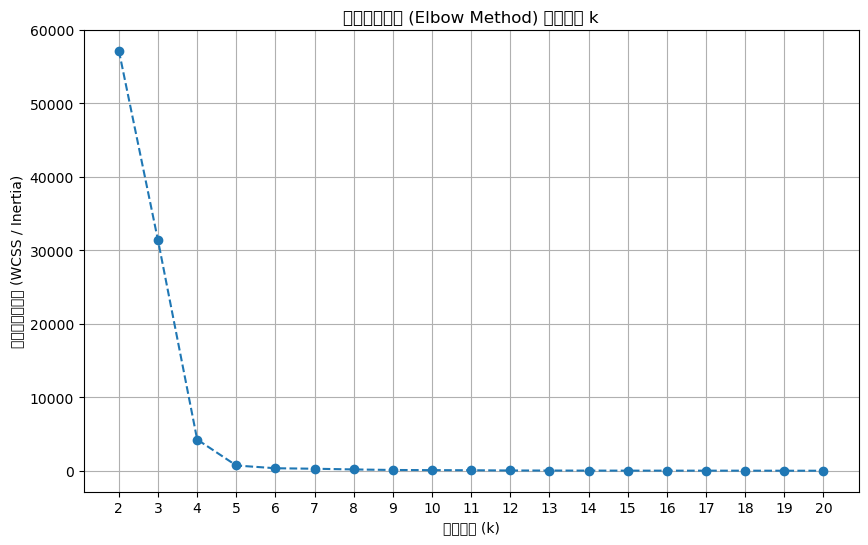

In [70]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("--- 租金地理聚类 步骤 2: 使用肘部法则寻找最佳 k ---")

# --- 1. 准备数据和参数 ---
try:
    # 确保缩放后的租金坐标数据存在
    if 'X_train_coords_scaled_rent' not in locals(): 
        raise NameError("X_train_coords_scaled_rent 未定义")
    
    # 使用完整的租金训练坐标数据
    data_for_elbow_rent = X_train_coords_scaled_rent
    print(f"正在使用全部 {len(data_for_elbow_rent)} 个租金训练样本点进行肘部法则计算 (可能需要1-2分钟)...")

    wcss_rent = [] # 存储租金数据的 WCSS
    k_range_rent = range(2, 21) # 尝试 k = 2 到 20

    # --- 2. 循环计算不同 k 值的 WCSS ---
    for k in k_range_rent:
        print(f"  正在计算 k = {k}...")
        kmeans_model_rent = KMeans(n_clusters=k, init='k-means++', n_init='auto', max_iter=300, random_state=111)
        kmeans_model_rent.fit(data_for_elbow_rent)
        wcss_rent.append(kmeans_model_rent.inertia_) # inertia_ 就是 WCSS

    print("租金 WCSS 计算完毕。")

    # --- 3. 绘制肘部法则图 ---
    print("\n--- 租金肘部法则图 (Elbow Method Plot) ---")
    plt.figure(figsize=(10, 6))
    plt.plot(k_range_rent, wcss_rent, marker='o', linestyle='--')
    plt.xlabel('聚类数量 (k)')
    plt.ylabel('簇内误差平方和 (WCSS / Inertia)')
    plt.title('租金肘部法则 (Elbow Method) 寻找最佳 k')
    plt.xticks(k_range_rent) # 确保 x 轴显示所有 k 值
    plt.grid(True)
    plt.show()

except NameError as e:
     print(f"🚨 错误：变量未找到 ({e})。请确保步骤 1 已成功运行。")
except Exception as e:
     print(f"🚨 寻找 k 时发生意外错误: {e}")

In [71]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

print("--- 租金地理聚类 步骤 3: 执行聚类 (k=5) 并分配标签 ---")

# --- 1. 设定选择的 k 值 ---
k_best_rent = 5 
print(f"将使用 k = {k_best_rent} 进行最终聚类。")

try:
    # 确保缩放后的坐标数据和主 DataFrame 存在
    if 'X_train_coords_scaled_rent' not in locals(): raise NameError("X_train_coords_scaled_rent 未定义")
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent (含TE/MLB) 未定义")

    # --- 2. 初始化并训练 K-Means 模型 (租金版) ---
    print(f"正在 X_train_coords_scaled_rent (租金训练坐标) 上训练 K-Means (k={k_best_rent})...")
    kmeans_final_model_rent = KMeans(n_clusters=k_best_rent, init='k-means++', n_init='auto', max_iter=300, random_state=111)
    
    # 在租金训练集坐标上 Fit
    kmeans_final_model_rent.fit(X_train_coords_scaled_rent)
    print("K-Means 模型 (租金版) 训练完毕。")

    # --- 3. 为所有三个数据集分配聚类标签 ---
    print("正在为 X_train_rent, X_val_rent, X_test_rent 分配聚类标签...")
    
    # 预测训练集
    cluster_labels_train_rent = kmeans_final_model_rent.predict(X_train_coords_scaled_rent)
    # 预测验证集
    cluster_labels_val_rent = kmeans_final_model_rent.predict(X_val_coords_scaled_rent)
    # 预测测试集
    cluster_labels_test_rent = kmeans_final_model_rent.predict(X_test_coords_scaled_rent)

    # --- 4. 将标签作为新特征添加到主 DataFrame ---
    # 我们将其转换为字符串 (object) 类型，以便后续的 OHE 步骤能正确识别它
    new_cluster_col_rent = 'Geo_Cluster_Rent'
    
    X_train_rent[new_cluster_col_rent] = cluster_labels_train_rent.astype(str)
    X_val_rent[new_cluster_col_rent] = cluster_labels_val_rent.astype(str)
    X_test_rent[new_cluster_col_rent] = cluster_labels_test_rent.astype(str)
    
    print(f"已成功将新的类别特征 '{new_cluster_col_rent}' (k={k_best_rent}) 添加到主 DataFrame。")
         
    print(f"\n处理后 X_train_rent 维度: {X_train_rent.shape}") 
    # 列数 = (原来的列数 + 1) -> 127 + 1 = 128 (基于你上次的 127 列)

except NameError as e:
     print(f"🚨 错误：变量未找到 ({e})。请确保步骤 1 已成功运行。")
except Exception as e:
     print(f"🚨 执行聚类或分配标签时发生意外错误: {e}")

--- 租金地理聚类 步骤 3: 执行聚类 (k=5) 并分配标签 ---
将使用 k = 5 进行最终聚类。
正在 X_train_coords_scaled_rent (租金训练坐标) 上训练 K-Means (k=5)...
K-Means 模型 (租金版) 训练完毕。
正在为 X_train_rent, X_val_rent, X_test_rent 分配聚类标签...
已成功将新的类别特征 'Geo_Cluster_Rent' (k=5) 添加到主 DataFrame。

处理后 X_train_rent 维度: (79119, 131)


C:\Users\31616\AppData\Local\Temp\ipykernel_25056\2047083994.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_rent[new_cluster_col_rent] = cluster_labels_train_rent.astype(str)
C:\Users\31616\AppData\Local\Temp\ipykernel_25056\2047083994.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_val_rent[new_cluster_col_rent] = cluster_labels_val_rent.astype(str)
C:\Users\31616\AppData\Local\Temp\ipykernel_25056\2047083994.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

In [72]:
import pandas as pd
import numpy as np

print("\n---创建 5 个交互项 ---")

# --- 1. 定义要创建的交互项 ---
interaction_pairs_rent = [
    # 面积 x 地理位置 (Size x Location)
    ('面积', 'TE_Block_Stratified_Rent', 'Area_x_TE_Block_Rent'), 
    # 面积 x 房龄 (Size x Age)
    ('面积', 'House_Age_Rent', 'Area_x_Age_Rent'),
    # 面积 x 质量 (Size x Quality)
    ('面积', 'Num_Baths', 'Area_x_Baths_Rent'),
    # 地理位置 x 楼层 (Location x Floor)
    ('TE_Block_Stratified_Rent', 'Floor_Num', 'TE_Block_x_Floor_Rent'),
    # 房龄 x 质量 (Age x Quality)
    ('House_Age_Rent', 'Amenity_空调', 'Age_x_AC_Rent') # 假设 'Amenity_空调' 存在
]

try:
    # 确保操作的 DataFrame 存在
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent 未定义")

    print(f"正在为 X_train_rent, X_val_rent, X_test_rent 创建 {len(interaction_pairs_rent)} 个交互项...")

    # 对每个数据集进行操作
    for df in [X_train_rent, X_val_rent, X_test_rent]:
        
        for col1, col2, new_col_name in interaction_pairs_rent:
            # 检查两个源列是否存在
            if col1 in df.columns and col2 in df.columns:
                df[new_col_name] = df[col1] * df[col2]
            else:
                # 如果源列不存在 (例如在测试集中)，创建 NaN 列
                df[new_col_name] = np.nan
                print(f"警告：在 DataFrame 中创建 '{new_col_name}' 失败，因为 '{col1}' 或 '{col2}' 不存在。")

    print("交互项创建完毕。")

         
    print(f"\n处理后 X_train_rent 维度: {X_train_rent.shape}") 
    # 列数 = (原来的列数 + 5) -> 132 + 5 = 137

except NameError as e:
     print(f"🚨 错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"🚨 创建交互项时发生意外错误: {e}")


---创建 5 个交互项 ---
正在为 X_train_rent, X_val_rent, X_test_rent 创建 5 个交互项...
交互项创建完毕。

处理后 X_train_rent 维度: (79119, 136)


C:\Users\31616\AppData\Local\Temp\ipykernel_25056\3321394173.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col_name] = df[col1] * df[col2]
C:\Users\31616\AppData\Local\Temp\ipykernel_25056\3321394173.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col_name] = df[col1] * df[col2]
C:\Users\31616\AppData\Local\Temp\ipykernel_25056\3321394173.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

In [73]:
import pandas as pd
import numpy as np

print("\n---创建多项式特征 (平方项) ---")

# --- 1. 定义要创建的平方项 ---
polynomial_features_to_create_rent = [
    ('面积', 'Area_sq_Rent'),
    ('House_Age_Rent', 'House_Age_Rent_sq'),
    ('Floor_Num', 'Floor_Num_sq') # 使用我们为租金创建的 Floor_Num
]

try:
    # 确保操作的 DataFrame 存在
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent 未定义")

    print(f"正在为 X_train_rent, X_val_rent, X_test_rent 创建 {len(polynomial_features_to_create_rent)} 个平方项特征...")

    # 对每个数据集进行操作
    for df in [X_train_rent, X_val_rent, X_test_rent]:
        
        for source_col, new_col_name in polynomial_features_to_create_rent:
            # 检查源列是否存在
            if source_col in df.columns:
                df[new_col_name] = df[source_col] ** 2
            else:
                # 如果源列不存在 (例如在测试集中)，创建 NaN 列
                df[new_col_name] = np.nan
                print(f"警告：在 DataFrame 中创建 '{new_col_name}' 失败，因为源列 '{source_col}' 不存在。")

    print("平方项特征创建完毕。")

         
    print(f"\n处理后 X_train_rent 维度: {X_train_rent.shape}") 
    # 列数 = (原来的列数 + 3) -> 137 + 3 = 140

except NameError as e:
     print(f"🚨 错误：变量未找到 ({e})。请确保回到了正确的步骤。")
except Exception as e:
     print(f"🚨 创建平方项时发生意外错误: {e}")


---创建多项式特征 (平方项) ---
正在为 X_train_rent, X_val_rent, X_test_rent 创建 3 个平方项特征...
平方项特征创建完毕。

处理后 X_train_rent 维度: (79119, 139)


C:\Users\31616\AppData\Local\Temp\ipykernel_25056\1327887446.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col_name] = df[source_col] ** 2
C:\Users\31616\AppData\Local\Temp\ipykernel_25056\1327887446.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col_name] = df[source_col] ** 2
C:\Users\31616\AppData\Local\Temp\ipykernel_25056\1327887446.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

In [74]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print("\n--- 清理, OHE, Outlier(IQR), Scale ---")

# --- 1. 定义最终要 *保留* 的核心数值/量化/TE/MLB/交互/平方 特征 ---
# (白名单，不含 lon/lat, *含* 新的交互项和平方项)
final_numeric_indicator_TE_cols_rent = [
    '面积', '容 积 率', '停车位',
    'Num_Rooms', 'Num_LivingRooms', 'Num_Kitchens', 'Num_Baths',
    'Floor_Num', 'Total_Floors_Rent',
    'House_Age_Rent', 'Total_Units_Rent', 'Total_Buildings_Rent',
    'Property_Fee_Rent', 'Greening_Rate_Rent', 'Gas_Fee_Rent', 'Parking_Fee_Rent',
    'TE_City_Rent', 'TE_District_Rent', 'TE_Block_Stratified_Rent',
    'Orientation_东', 'Orientation_南', 'Orientation_西', 'Orientation_北',
    'Orientation_东北', 'Orientation_东南', 'Orientation_西北', 'Orientation_西南',
    'Amenity_电视', 'Amenity_冰箱', 'Amenity_洗衣机', 'Amenity_空调', 'Amenity_热水器',
    'Amenity_床', 'Amenity_暖气', 'Amenity_宽带', 'Amenity_衣柜', 'Amenity_天然气',
    'Transaction_Year_Rent', 'Transaction_Month_Rent',
    # --- 新增的平方项 ---
    'Area_sq_Rent', 'House_Age_Rent_sq', 'Floor_Num_sq',
    # --- 新增的交互项 ---
    'Area_x_TE_Block_Rent', 'Area_x_Age_Rent', 'Area_x_Baths_Rent',
    'TE_Block_x_Floor_Rent', 'Age_x_AC_Rent'
]
# --- (!!! 自动获取所有手动创建的指示变量列 !!!) ---
try:
    prop_type_cols_generated = [col for col in X_train_rent.columns if col.startswith('PropTypeRent_')]
    rights_rent_cols_generated = [col for col in X_train_rent.columns if col.startswith('RightsRent_')]
    struct_rent_cols_generated = [col for col in X_train_rent.columns if col.startswith('Struct_')]
    final_numeric_indicator_TE_cols_rent.extend(prop_type_cols_generated)
    final_numeric_indicator_TE_cols_rent.extend(rights_rent_cols_generated)
    final_numeric_indicator_TE_cols_rent.extend(struct_rent_cols_generated)
    final_numeric_indicator_TE_cols_rent = sorted(list(set(final_numeric_indicator_TE_cols_rent)))
    print(f"白名单中共 {len(final_numeric_indicator_TE_cols_rent)} 个数值/TE/MLB/交互/平方 特征。")
except NameError as e:
    print(f"🚨 错误：尝试自动获取 MLB 列时出错 ({e})。请确保之前的步骤已运行。")

# --- 2. 识别需要 OHE 的 *真正剩余* 低基数类别特征 ---
try:
    if 'X_train_rent' not in locals(): raise NameError("X_train_rent (含所有特征) 未定义")
    object_cols_to_drop_rent = [
        '户型', '楼层', '建筑年代', '房屋总数', '楼栋总数',
        '物 业 费', '绿 化 率', '燃气费', '停车费用', '交易时间',
        '朝向', '配套设施', '物业类别', '产权描述', '建筑结构',
        '开发商', '物业公司', '城市', '区域', '板块', '区县',
        '年份', 'coord_x', 'coord_y', '供水', '供电', '供暖', '租期', '环线位置',
    ]
    current_object_cols_rent = X_train_rent.select_dtypes(include=['object']).columns.tolist()
    categorical_cols_for_ohe_rent = sorted([
        col for col in current_object_cols_rent if col not in object_cols_to_drop_rent
    ])
    print(f"最终将对 {len(categorical_cols_for_ohe_rent)} 个低基数类别列进行 OHE: {categorical_cols_for_ohe_rent}")
    # 预期: ['Geo_Cluster_Rent', '付款方式', '租赁方式', '电梯', '用水', '用电', '燃气'] (7 个)

    # --- 3. 执行最终清理 ---
    all_final_cols_rent = final_numeric_indicator_TE_cols_rent + categorical_cols_for_ohe_rent
    missing_in_train = [col for col in all_final_cols_rent if col not in X_train_rent.columns]
    if missing_in_train: raise KeyError(f"以下列在 X_train_rent 中缺失: {missing_in_train}")
    
    X_train_cleaned_rent = X_train_rent[all_final_cols_rent].copy()
    X_val_cleaned_rent = X_val_rent[all_final_cols_rent].copy()
    cols_in_test = [col for col in all_final_cols_rent if col in X_test_rent.columns] 
    X_test_rent_cleaned = X_test_rent[cols_in_test].copy()
    print("最终清理完成。")
    print(f"清理后维度 (编码前): {X_train_cleaned_rent.shape}") 

    # --- 4. 最终 OHE (剩余类别) + 对齐 ---
    if categorical_cols_for_ohe_rent: 
        print(f"正在执行最终 OHE (drop_first=True)...")
        X_train_final_rent = pd.get_dummies(X_train_cleaned_rent, columns=categorical_cols_for_ohe_rent, dummy_na=False, dtype=int, drop_first=True)
        X_val_final_rent = pd.get_dummies(X_val_cleaned_rent, columns=categorical_cols_for_ohe_rent, dummy_na=False, dtype=int, drop_first=True)
        X_test_rent_final = pd.get_dummies(X_test_rent_cleaned, columns=categorical_cols_for_ohe_rent, dummy_na=False, dtype=int, drop_first=True)
    else:
        X_train_final_rent = X_train_cleaned_rent.copy(); X_val_final_rent = X_val_cleaned_rent.copy(); X_test_rent_final = X_test_rent_cleaned.copy()
        
    final_train_columns_rent = X_train_final_rent.columns
    X_val_final_rent = X_val_final_rent.reindex(columns=final_train_columns_rent, fill_value=0)
    X_test_rent_final = X_test_rent_final.reindex(columns=final_train_columns_rent, fill_value=0)
    print("OHE, 对齐完成。")
    
    # 移除冗余数值列 (lon, lat 等)
    redundant_numeric_cols_to_drop = ['lon', 'lat', '区县', '年份'] 
    cols_to_drop_present = [col for col in redundant_numeric_cols_to_drop if col in X_train_final_rent.columns]
    if cols_to_drop_present:
        X_train_final_rent.drop(columns=cols_to_drop_present, inplace=True, errors='ignore')
        X_val_final_rent.drop(columns=cols_to_drop_present, inplace=True, errors='ignore')
        X_test_rent_final.drop(columns=cols_to_drop_present, inplace=True, errors='ignore')
        print(f"已移除冗余数值列: {cols_to_drop_present}")
        
    print(f"最终 OHE 和清理后维度: {X_train_final_rent.shape}") 

    # --- 5. 异常值处理 (IQR 方法) ---
    
    print("\n正在执行异常值处理 (IQR)...")
    # 识别要处理的列 (自动检测逻辑不变，它会自动包含新的平方/交互项)
    cols_to_treat_present = []
    # 查找所有非 0/1 的列
    for col in X_train_final_rent.columns:
        # 检查是否不是 int32 (OHE列) 且唯一值 > 2 (非 0/1 指示变量)
        if X_train_final_rent[col].dtype != 'int32' and len(X_train_final_rent[col].unique()) > 2:
               cols_to_treat_present.append(col)
               
    print(f"将对 {len(cols_to_treat_present)} 个特征应用 IQR 规则...")
    
    # 存储学到的界限
    iqr_bounds = {} 
    
    # (A) 只在 X_train_final_rent 上学习界限
    for col in cols_to_treat_present:
        Q1 = X_train_final_rent[col].quantile(0.25)
        Q3 = X_train_final_rent[col].quantile(0.75)
        IQR_val = Q3 - Q1
        
        # 计算边界
        lower_bound = Q1 - (1.5 * IQR_val)
        upper_bound = Q3 + (1.5 * IQR_val)
        
        # 仅在边界有意义时存储
        if IQR_val > 0: 
             iqr_bounds[col] = (lower_bound, upper_bound)

    # (B) 将学到的界限应用到所有三个数据集 (Clipping)
    # --- 保持变量名 X_train_winsorized_rent 不变，以契合后续代码 ---
    X_train_winsorized_rent = X_train_final_rent.copy()
    X_val_winsorized_rent = X_val_final_rent.copy()
    X_test_rent_winsorized_rent = X_test_rent_final.copy() # 修正变量名
    
    for col in iqr_bounds: 
        lower_bound, upper_bound = iqr_bounds[col]
        X_train_winsorized_rent[col] = X_train_winsorized_rent[col].clip(lower=lower_bound, upper=upper_bound)
        X_val_winsorized_rent[col] = X_val_winsorized_rent[col].clip(lower=lower_bound, upper=upper_bound)
        X_test_rent_winsorized_rent[col] = X_test_rent_winsorized_rent[col].clip(lower=lower_bound, upper=upper_bound) # 修正变量名
        
    print("IQR 异常值处理 (Clipping) 完成。")

    # --- 6. 特征缩放 (Scaling) ---
    print("\n正在执行特征缩放...")
    scaler_rent = StandardScaler()
    
    # --- 使用 IQR 处理后的数据 (变量名保持不变) ---
    X_train_scaled_rent = scaler_rent.fit_transform(X_train_winsorized_rent) 
    X_val_scaled_rent = scaler_rent.transform(X_val_winsorized_rent)     
    X_test_scaled_rent = scaler_rent.transform(X_test_rent_winsorized_rent) # 修正变量名
    
    final_columns_rent = X_train_winsorized_rent.columns 
    X_train_scaled_df_rent = pd.DataFrame(X_train_scaled_rent, index=X_train_winsorized_rent.index, columns=final_columns_rent)
    X_val_scaled_df_rent = pd.DataFrame(X_val_scaled_rent, index=X_val_winsorized_rent.index, columns=final_columns_rent)
    X_test_scaled_df_rent = pd.DataFrame(X_test_scaled_rent, index=X_test_rent_winsorized_rent.index, columns=final_columns_rent)
    print("Scaling 完成。")

    # --- 7. 最终确认 ---
    print(f"\n--- 租金数据最终准备完成 (v7 K-Means + IQR + Poly + Int)！---")
    print(f"最终用于建模的特征维度: {X_train_scaled_df_rent.shape}") 
    print("\n--- X_train_scaled_df_rent 类型确认 ---")
    X_train_scaled_df_rent.info() # 应为 float64

except NameError as e:
    print(f"🚨 错误：变量未找到 ({e})。请确保TE 和 MLB 步骤已成功运行。")
except KeyError as e:
    print(f"🚨 错误：列 '{e}' 缺失。请检查白名单或之前的步骤。")
except Exception as e:
    print(f"🚨 处理过程中发生意外错误: {e}")


--- 清理, OHE, Outlier(IQR), Scale ---
白名单中共 113 个数值/TE/MLB/交互/平方 特征。
最终将对 7 个低基数类别列进行 OHE: ['Geo_Cluster_Rent', '付款方式', '燃气', '用水', '用电', '电梯', '租赁方式']
最终清理完成。
清理后维度 (编码前): (79119, 120)
正在执行最终 OHE (drop_first=True)...
OHE, 对齐完成。
最终 OHE 和清理后维度: (79119, 133)

正在执行异常值处理 (IQR)...
将对 26 个特征应用 IQR 规则...
IQR 异常值处理 (Clipping) 完成。

正在执行特征缩放...
Scaling 完成。

--- 租金数据最终准备完成 (v7 K-Means + IQR + Poly + Int)！---
最终用于建模的特征维度: (79119, 133)

--- X_train_scaled_df_rent 类型确认 ---
<class 'pandas.core.frame.DataFrame'>
Index: 79119 entries, 66850 to 77652
Columns: 133 entries, Age_x_AC_Rent to 租赁方式_整租
dtypes: float64(133)
memory usage: 80.9 MB


In [75]:
# --- OLS 建模 ---

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error 
import numpy as np
import pandas as pd 
import warnings 

# --- 1. 评估函数 (确保已定义) ---
# ... (evaluate_model_safe 函数定义) ...
try:
    evaluate_model_safe
except NameError:
    print("Re-defining evaluate_model_safe function...")
    def evaluate_model_safe(y_true_log, y_pred_log, model_name="Model"):
        mae, rmse = np.nan, np.nan 
        y_true_orig = np.expm1(y_true_log)
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")
            try:
                y_pred_orig = np.expm1(y_pred_log)
                if not np.all(np.isfinite(y_pred_orig)): raise ValueError("Overflow/NaN after expm1")
                mae = mean_absolute_error(y_true_orig, y_pred_orig)
                rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
            except (OverflowError, ValueError) as e: print(f"🚨 Error: Overflow/invalid value during metric calculation for {model_name}! Returning NaN.")
            except NameError: print("🚨 Error: 'mean_absolute_error' or 'mean_squared_error' not imported!")
        print(f"--- {model_name} Performance ---")
        if not np.isnan(mae): print(f"MAE (原始租金): {mae:,.2f}"); print(f"RMSE (原始租金): {rmse:,.2f}")
        else: print(f"MAE (原始租金): N/A"); print(f"RMSE (原始租金): N/A")
        try: # Calculate log scale metrics too
            mae_log = mean_absolute_error(y_true_log, y_pred_log); rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
            print(f"MAE (对数尺度): {mae_log:.4f}"); print(f"RMSE (对数尺度): {rmse_log:.4f}")
        except NameError: pass # Ignore if metrics functions not imported here
        return mae, rmse

# --- 2. 初始化并训练 OLS 模型 ---
ols_model_rent = LinearRegression()
print("正在训练 OLS 模型 ...")
# --- 使用最终的租金数据 ---
ols_model_rent.fit(X_train_scaled_df_rent, y_train_rent_log) 
print("OLS 模型训练完毕。")

# --- 3. 样本内评估 ---
print("\n--- (A) 样本内 (In-sample) 评估 (Rent OLS v2) ---")
y_train_pred_log_ols_rent = ols_model_rent.predict(X_train_scaled_df_rent)
mae_in_ols_rent, rmse_in_ols_rent = evaluate_model_safe(y_train_rent_log, y_train_pred_log_ols_rent, "Rent OLS v2 In-sample")

# --- 4. 样本外评估 ---
print("\n--- (B) 样本外 (Out-of-sample) 评估 (Rent OLS v2) ---")
y_val_pred_log_ols_rent = ols_model_rent.predict(X_val_scaled_df_rent) 
mae_out_ols_rent, rmse_out_ols_rent = evaluate_model_safe(y_val_rent_log, y_val_pred_log_ols_rent, "Rent OLS v2 Out-of-sample")

# --- 5. 准备记录结果 ---
model_performance_rent = pd.DataFrame(index=['MAE_in', 'RMSE_in', 'MAE_out', 'RMSE_out'])
model_performance_rent['OLS'] = [mae_in_ols_rent, rmse_in_ols_rent, mae_out_ols_rent, rmse_out_ols_rent]
print("\n--- Rent OLS v2 模型性能已记录 ---")
print(model_performance_rent)

正在训练 OLS 模型 ...
OLS 模型训练完毕。

--- (A) 样本内 (In-sample) 评估 (Rent OLS v2) ---
--- Rent OLS v2 In-sample Performance ---
MAE (原始价格): 121,805.46
RMSE (原始价格): 302,271.70
MAE (对数尺度): 0.1979
RMSE (对数尺度): 0.2717

--- (B) 样本外 (Out-of-sample) 评估 (Rent OLS v2) ---
--- Rent OLS v2 Out-of-sample Performance ---
MAE (原始价格): 124,888.84
RMSE (原始价格): 292,710.00
MAE (对数尺度): 0.2061
RMSE (对数尺度): 0.2809

--- Rent OLS v2 模型性能已记录 ---
                    OLS
MAE_in    121805.462212
RMSE_in   302271.697341
MAE_out   124888.844051
RMSE_out  292709.999494


In [76]:
# --- LassoCV 调优 ---

from sklearn.linear_model import LassoCV
# (确保 evaluate_model_safe 函数已定义)
import numpy as np
import pandas as pd 
import warnings 
import time 

print("\n--- 使用 LassoCV 进行超参数调优  ---")

# --- 1. 定义 alpha 候选范围 ---
alphas_lasso_rent_final = np.logspace(-5, -2, 20) # 搜索更小的值
print(f"Lasso (Rent) 将尝试以下 alpha 值 (约): {alphas_lasso_rent_final}")

# --- 2. 初始化并运行 LassoCV ---
lasso_cv_model_rent_final = LassoCV(alphas=alphas_lasso_rent_final, 
                                    cv=6, # 6 折
                                    random_state=111, 
                                    n_jobs=-1, 
                                    max_iter=10000, # 增加迭代次数
                                    tol=1e-4, # 恢复较严格 tol
                                    verbose=0) 

print(f"正在运行 LassoCV (Rent, 120 feat)...")
start_time = time.time() 
# --- 使用最终的租金数据 ---
lasso_cv_model_rent_final.fit(X_train_scaled_df_rent, y_train_rent_log) 
end_time = time.time() 
elapsed_time = end_time - start_time
print(f"LassoCV (Rent) 完成。耗时: {elapsed_time:.2f} 秒")

# --- 3. 获取最佳 alpha ---
best_alpha_lasso_rent_final = lasso_cv_model_rent_final.alpha_
print(f"LassoCV (Rent) 找到的最佳 alpha 是: {best_alpha_lasso_rent_final:.6f}")

# --- 4. 使用最佳 alpha 模型评估 ---
best_lasso_model_rent_final = lasso_cv_model_rent_final 
coeffs_best_lasso_rent_final = best_lasso_model_rent_final.coef_
num_non_zero_coeffs_final_rent = np.sum(coeffs_best_lasso_rent_final != 0)
print(f"Best Lasso (Rent Final) 选择了 {num_non_zero_coeffs_final_rent} 个特征 / {X_train_scaled_df_rent.shape[1]}。")

print("\n--- (A) 样本内评估 (Best Rent Lasso v2) ---")
y_train_pred_log_best_lasso_rent = best_lasso_model_rent_final.predict(X_train_scaled_df_rent)
mae_in_best_lasso_rent, rmse_in_best_lasso_rent = evaluate_model_safe(y_train_rent_log, y_train_pred_log_best_lasso_rent, "Best Rent Lasso v2 In-sample")

print("\n--- (B) 样本外评估 (Best Rent Lasso v2) ---")
y_val_pred_log_best_lasso_rent = best_lasso_model_rent_final.predict(X_val_scaled_df_rent) 
mae_out_best_lasso_rent, rmse_out_best_lasso_rent = evaluate_model_safe(y_val_rent_log, y_val_pred_log_best_lasso_rent, "Best Rent Lasso v2 Out-of-sample")

# --- 5. 更新性能记录表 ---
try:
    # 移除之前的 Lasso 列
    lasso_cols_to_drop = [col for col in model_performance_rent.columns if 'Lasso' in col]
    if lasso_cols_to_drop: model_performance_rent = model_performance_rent.drop(columns=lasso_cols_to_drop)
    model_performance_rent[f'Lasso (alpha={best_alpha_lasso_rent_final:.4f})'] = [mae_in_best_lasso_rent, rmse_in_best_lasso_rent, mae_out_best_lasso_rent, rmse_out_best_lasso_rent]
except NameError: pass 

print("\n--- Best Rent Lasso v2 模型性能已记录 ---")
print(model_performance_rent)


--- 使用 LassoCV 进行超参数调优  ---
Lasso (Rent) 将尝试以下 alpha 值 (约): [1.00000000e-05 1.43844989e-05 2.06913808e-05 2.97635144e-05
 4.28133240e-05 6.15848211e-05 8.85866790e-05 1.27427499e-04
 1.83298071e-04 2.63665090e-04 3.79269019e-04 5.45559478e-04
 7.84759970e-04 1.12883789e-03 1.62377674e-03 2.33572147e-03
 3.35981829e-03 4.83293024e-03 6.95192796e-03 1.00000000e-02]
正在运行 LassoCV (Rent, 120 feat)...
LassoCV (Rent) 完成。耗时: 496.05 秒
LassoCV (Rent) 找到的最佳 alpha 是: 0.000014
Best Lasso (Rent Final) 选择了 127 个特征 / 133。

--- (A) 样本内评估 (Best Rent Lasso v2) ---
--- Best Rent Lasso v2 In-sample Performance ---
MAE (原始价格): 121,814.74
RMSE (原始价格): 302,398.49
MAE (对数尺度): 0.1979
RMSE (对数尺度): 0.2717

--- (B) 样本外评估 (Best Rent Lasso v2) ---
--- Best Rent Lasso v2 Out-of-sample Performance ---
MAE (原始价格): 121,773.16
RMSE (原始价格): 293,741.15
MAE (对数尺度): 0.2002
RMSE (对数尺度): 0.2745

--- Best Rent Lasso v2 模型性能已记录 ---
                    OLS  Lasso (alpha=0.0000)
MAE_in    121805.462212         121814.740498
RMSE_

In [77]:
# --- RidgeCV 调优 ---

from sklearn.linear_model import RidgeCV
# (确保 evaluate_model_safe 函数已定义)
import numpy as np
import pandas as pd 
import warnings 
import time 

print("\n--- 使用 RidgeCV 进行超参数调优 ---")

# --- 1. 定义 alpha 候选范围 ---
alphas_ridge_rent_final = np.logspace(0, 4, 20) # 1 到 10000
print(f"Ridge (Rent) 将尝试以下 alpha 值 (约): {alphas_ridge_rent_final}")

# --- 2. 初始化并运行 RidgeCV ---
ridge_cv_model_rent_final = RidgeCV(alphas=alphas_ridge_rent_final, 
                                    cv=6, 
                                    scoring=None) # 默认 R^2

print(f"正在运行 RidgeCV (Rent, 120 feat)...")
start_time = time.time() 
ridge_cv_model_rent_final.fit(X_train_scaled_df_rent, y_train_rent_log) 
end_time = time.time() 
elapsed_time = end_time - start_time
print(f"RidgeCV (Rent) 完成。耗时: {elapsed_time:.2f} 秒")

# --- 3. 获取最佳 alpha ---
best_alpha_ridge_rent_final = ridge_cv_model_rent_final.alpha_
print(f"RidgeCV (Rent) 找到的最佳 alpha 是: {best_alpha_ridge_rent_final:.6f}")

# --- 4. 使用最佳 alpha 模型评估 ---
best_ridge_model_rent_final = ridge_cv_model_rent_final 

print("\n--- (A) 样本内评估 (Best Rent Ridge v2) ---")
y_train_pred_log_best_ridge_rent = best_ridge_model_rent_final.predict(X_train_scaled_df_rent)
mae_in_best_ridge_rent, rmse_in_best_ridge_rent = evaluate_model_safe(y_train_rent_log, y_train_pred_log_best_ridge_rent, "Best Rent Ridge v2 In-sample")

print("\n--- (B) 样本外评估 (Best Rent Ridge v2) ---")
y_val_pred_log_best_ridge_rent = best_ridge_model_rent_final.predict(X_val_scaled_df_rent) 
mae_out_best_ridge_rent, rmse_out_best_ridge_rent = evaluate_model_safe(y_val_rent_log, y_val_pred_log_best_ridge_rent, "Best Rent Ridge v2 Out-of-sample")

# --- 5. 更新性能记录表 ---
try:
    # 移除之前的 Ridge 列
    ridge_cols_to_drop = [col for col in model_performance_rent.columns if 'Ridge' in col]
    if ridge_cols_to_drop: model_performance_rent = model_performance_rent.drop(columns=ridge_cols_to_drop)
    model_performance_rent[f'Ridge (alpha={best_alpha_ridge_rent_final:.2f})'] = [mae_in_best_ridge_rent, rmse_in_best_ridge_rent, mae_out_best_ridge_rent, rmse_out_best_ridge_rent]
except NameError: pass

print("\n--- Best Rent Ridge v2 模型性能已记录 ---")
print(model_performance_rent)


--- 使用 RidgeCV 进行超参数调优 ---
Ridge (Rent) 将尝试以下 alpha 值 (约): [1.00000000e+00 1.62377674e+00 2.63665090e+00 4.28133240e+00
 6.95192796e+00 1.12883789e+01 1.83298071e+01 2.97635144e+01
 4.83293024e+01 7.84759970e+01 1.27427499e+02 2.06913808e+02
 3.35981829e+02 5.45559478e+02 8.85866790e+02 1.43844989e+03
 2.33572147e+03 3.79269019e+03 6.15848211e+03 1.00000000e+04]
正在运行 RidgeCV (Rent, 120 feat)...
RidgeCV (Rent) 完成。耗时: 36.15 秒
RidgeCV (Rent) 找到的最佳 alpha 是: 1.623777

--- (A) 样本内评估 (Best Rent Ridge v2) ---
--- Best Rent Ridge v2 In-sample Performance ---
MAE (原始价格): 121,812.34
RMSE (原始价格): 302,367.40
MAE (对数尺度): 0.1979
RMSE (对数尺度): 0.2717

--- (B) 样本外评估 (Best Rent Ridge v2) ---
--- Best Rent Ridge v2 Out-of-sample Performance ---
MAE (原始价格): 124,042.73
RMSE (原始价格): 292,782.73
MAE (对数尺度): 0.2046
RMSE (对数尺度): 0.2792

--- Best Rent Ridge v2 模型性能已记录 ---
                    OLS  Lasso (alpha=0.0000)  Ridge (alpha=1.62)
MAE_in    121805.462212         121814.740498       121812.342630
RMSE_in   

In [78]:
# --- ElasticNetCV 调优 ---

from sklearn.linear_model import ElasticNetCV
import numpy as np
import pandas as pd 
import warnings 
import time 

print("\n--- 使用 ElasticNetCV 进行超参数调优 ---")

# --- 1. 定义 alpha 和 l1_ratio 候选范围 ---
# Alpha 范围 (类似 Lasso, 搜索小值)
alphas_enet_rent_final = np.logspace(-5, -2, 10) # 0.00001 到 0.01

# L1 Ratio 范围 (从接近 Ridge 到接近 Lasso)
l1_ratios_enet_final = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0] # 包含 Lasso (1.0)

print(f"ElasticNet (Rent) 将尝试 alpha 值 (约): {alphas_enet_rent_final}")
print(f"ElasticNet (Rent) 将尝试 l1_ratio 值: {l1_ratios_enet_final}")

# --- 2. 初始化并运行 ElasticNetCV ---
enet_cv_model_rent_final = ElasticNetCV(alphas=alphas_enet_rent_final,
                                      l1_ratio=l1_ratios_enet_final,
                                      cv=6, # 6 折
                                      random_state=111,
                                      n_jobs=-1, # 使用适中的并行数
                                      max_iter=10000,
                                      tol=1e-4, 
                                      verbose=0) 

print(f"正在运行 ElasticNetCV (Rent, 120 feat)...")
start_time = time.time()
# --- 使用最终的租金数据 ---
enet_cv_model_rent_final.fit(X_train_scaled_df_rent, y_train_rent_log) 
end_time = time.time()
elapsed_time = end_time - start_time
print(f"ElasticNetCV (Rent) 完成。耗时: {elapsed_time:.2f} 秒")

# --- 3. 获取最佳参数 ---
best_alpha_enet_rent_final = enet_cv_model_rent_final.alpha_
best_l1_ratio_enet_rent_final = enet_cv_model_rent_final.l1_ratio_
print(f"\nElasticNetCV (Rent) 找到的最佳 alpha 是: {best_alpha_enet_rent_final:.6f}")
print(f"ElasticNetCV (Rent) 找到的最佳 l1_ratio 是: {best_l1_ratio_enet_rent_final:.6f}")

# --- 4. 使用最佳参数模型评估 ---
best_enet_model_rent_final = enet_cv_model_rent_final
coeffs_best_enet_rent_final = best_enet_model_rent_final.coef_
num_non_zero_coeffs_final_enet_rent = np.sum(coeffs_best_enet_rent_final != 0)
print(f"Best ElasticNet (Rent Final) 选择了 {num_non_zero_coeffs_final_enet_rent} 个特征 / {X_train_scaled_df_rent.shape[1]}。")

print("\n--- (A) 样本内评估 (Best Rent ElasticNet v2) ---")
y_train_pred_log_best_enet_rent = best_enet_model_rent_final.predict(X_train_scaled_df_rent)
mae_in_best_enet_rent, rmse_in_best_enet_rent = evaluate_model_safe(y_train_rent_log, y_train_pred_log_best_enet_rent, "Best Rent ElasticNet v2 In-sample")

print("\n--- (B) 样本外评估 (Best Rent ElasticNet v2) ---")
y_val_pred_log_best_enet_rent = best_enet_model_rent_final.predict(X_val_scaled_df_rent)
mae_out_best_enet_rent, rmse_out_best_enet_rent = evaluate_model_safe(y_val_rent_log, y_val_pred_log_best_enet_rent, "Best Rent ElasticNet v2 Out-of-sample")

# --- 5. 更新性能记录表 ---
try:
    if 'model_performance_rent' not in locals(): raise NameError("model_performance_rent DataFrame 未定义。")
    if len(model_performance_rent.index) != 4: # 确保 OLS, Lasso, Ridge 已添加
        print(f"警告：性能表行数 ({len(model_performance_rent.index)}) 不为 4，MAE_cv 可能尚未计算。")
        # 我们假设 MAE_cv 行存在，如果不存在，下面会报错
        
    # 移除之前的 ElasticNet 列 (如果存在)
    enet_cols_to_drop = [col for col in model_performance_rent.columns if 'ElasticNet' in col]
    if enet_cols_to_drop: model_performance_rent = model_performance_rent.drop(columns=enet_cols_to_drop)
    
    new_col_name_rent = f'ElasticNet (a={best_alpha_enet_rent_final:.4f},l1={best_l1_ratio_enet_rent_final:.2f})'
    
    # 查找 Lasso 的 MAE_cv 值
    lasso_cv_mae_rent = np.nan # 默认为 NaN
    lasso_col_name = [col for col in model_performance_rent.columns if 'Lasso' in col]
    if lasso_col_name and 'MAE_cv' in model_performance_rent.index:
        lasso_cv_mae_rent = model_performance_rent.loc['MAE_cv', lasso_col_name[0]]

    # 创建包含 5 个值的 Series (最后一个是 MAE_cv 的占位符)
    enet_results_rent = pd.Series([
        mae_in_best_enet_rent, 
        rmse_in_best_enet_rent, 
        mae_out_best_enet_rent, 
        rmse_out_best_enet_rent, 
        np.nan # MAE_cv 的占位符
    ], index=model_performance_rent.index) # 使用 DataFrame 的索引
    
    model_performance_rent[new_col_name_rent] = enet_results_rent
    
    # 填充 MAE_cv 
    if np.isclose(best_l1_ratio_enet_rent_final, 1.0) and not np.isnan(lasso_cv_mae_rent):
         model_performance_rent.loc['MAE_cv', new_col_name_rent] = lasso_cv_mae_rent
    else:
         print(f"\n注意：需要单独为 ElasticNet (l1_ratio={best_l1_ratio_enet_rent_final:.2f}) 计算 CV MAE。当前值为 N/A。")

except NameError as e: print(f"错误：变量未找到 ({e})。")
except ValueError as e: print(f"错误: {e}")
except Exception as e: print(f"更新性能表时出错: {e}")


print("\n--- Best Rent ElasticNet v2 模型性能已记录 ---")
if 'model_performance_rent' in locals():
    print(model_performance_rent.to_string(float_format='{:,.2f}'.format, na_rep='N/A'))
else:
    print("无法打印租金性能表，因为它未定义。")


--- 使用 ElasticNetCV 进行超参数调优 ---
ElasticNet (Rent) 将尝试 alpha 值 (约): [1.00000000e-05 2.15443469e-05 4.64158883e-05 1.00000000e-04
 2.15443469e-04 4.64158883e-04 1.00000000e-03 2.15443469e-03
 4.64158883e-03 1.00000000e-02]
ElasticNet (Rent) 将尝试 l1_ratio 值: [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]
正在运行 ElasticNetCV (Rent, 120 feat)...


C:\Users\31616\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13.169842147989584, tolerance: 3.803793299612173
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\31616\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 18.153719751529025, tolerance: 3.8144379672053867
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\31616\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 70.19837529449933, tolerance: 3.798995301979718
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\31616\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:617:

ElasticNetCV (Rent) 完成。耗时: 488.86 秒

ElasticNetCV (Rent) 找到的最佳 alpha 是: 0.000022
ElasticNetCV (Rent) 找到的最佳 l1_ratio 是: 1.000000
Best ElasticNet (Rent Final) 选择了 126 个特征 / 133。

--- (A) 样本内评估 (Best Rent ElasticNet v2) ---
--- Best Rent ElasticNet v2 In-sample Performance ---
MAE (原始价格): 121,813.82
RMSE (原始价格): 302,421.62
MAE (对数尺度): 0.1979
RMSE (对数尺度): 0.2717

--- (B) 样本外评估 (Best Rent ElasticNet v2) ---
--- Best Rent ElasticNet v2 Out-of-sample Performance ---
MAE (原始价格): 121,769.70
RMSE (原始价格): 293,754.63
MAE (对数尺度): 0.2002
RMSE (对数尺度): 0.2745
错误: Length of values (5) does not match length of index (4)

--- Best Rent ElasticNet v2 模型性能已记录 ---
                OLS  Lasso (alpha=0.0000)  Ridge (alpha=1.62)
MAE_in   121,805.46            121,814.74          121,812.34
RMSE_in  302,271.70            302,398.49          302,367.40
MAE_out  124,888.84            121,773.16          124,042.73
RMSE_out 292,710.00            293,741.15          292,782.73


In [79]:
# ---计算所有模型的 6 折 CV MAE ---

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error # 确保导入
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet # <-- 导入 ElasticNet
import numpy as np
import pandas as pd
import warnings

print("\n--- 计算所有模型的 6 折交叉验证 MAE  ---")

# --- 1. 确保评分器已定义 ---
try: 
    mae_scorer 
except NameError:
    print("Re-defining mae_scorer...")
    def mae_original_scale_scorer(y_true_log, y_pred_log):
        try:
            y_true_orig = np.expm1(y_true_log); y_pred_orig = np.expm1(y_pred_log)
            if not np.all(np.isfinite(y_pred_orig)): return -np.inf 
            mae = mean_absolute_error(y_true_orig, y_pred_orig); return -mae 
        except (OverflowError, ValueError): return -np.inf
    mae_scorer = make_scorer(mae_original_scale_scorer, greater_is_better=True)

# --- 2. 准备 CV ---
kf = KFold(n_splits=6, shuffle=True, random_state=111) 
X_rent = X_train_scaled_df_rent 
y_rent = y_train_rent_log      

# --- 3. 计算 OLS CV MAE ---
print("\n正在计算 Rent OLS 的 6 折 CV MAE ...")
ols_model_for_cv_rent = LinearRegression()
with warnings.catch_warnings(): 
    warnings.simplefilter("ignore")
    ols_cv_scores_neg_mae_rent = cross_val_score(ols_model_for_cv_rent, X_rent, y_rent, cv=kf, scoring=mae_scorer, n_jobs=4)
ols_cv_scores_mae_rent = -ols_cv_scores_neg_mae_rent
ols_cv_mae_mean_rent = np.mean(ols_cv_scores_mae_rent[np.isfinite(ols_cv_scores_mae_rent)]) if np.any(np.isfinite(ols_cv_scores_mae_rent)) else np.nan
print(f"Rent OLS 6 折 CV MAE: {ols_cv_mae_mean_rent:,.2f}" if not np.isnan(ols_cv_mae_mean_rent) else "Rent OLS 6 折 CV MAE: N/A")

# --- 4. 计算 Best Lasso CV MAE ---
# (确保 best_alpha_lasso_rent_final 存在)
try:
    print("\n正在计算 Best Rent Lasso (alpha={:.6f}) 的 6 折 CV MAE...".format(best_alpha_lasso_rent_final))
    best_lasso_for_cv_rent = Lasso(alpha=best_alpha_lasso_rent_final, max_iter=10000, tol=1e-4, random_state=111) 
    lasso_cv_scores_neg_mae_rent = cross_val_score(best_lasso_for_cv_rent, X_rent, y_rent, cv=kf, scoring=mae_scorer, n_jobs=4)
    lasso_cv_mae_mean_rent = -np.mean(lasso_cv_scores_neg_mae_rent)
    print(f"Best Rent Lasso 6 折 CV MAE: {lasso_cv_mae_mean_rent:,.2f}")
except NameError as e:
    print(f"跳过 Best Lasso CV 计算：{e}")
    lasso_cv_mae_mean_rent = np.nan

# --- 5. 计算 Best Ridge CV MAE ---
# (确保 best_alpha_ridge_rent_final 存在)
try:
    print("\n正在计算 Best Rent Ridge (alpha={:.2f}) 的 6 折 CV MAE...".format(best_alpha_ridge_rent_final))
    best_ridge_for_cv_rent = Ridge(alpha=best_alpha_ridge_rent_final, random_state=111)
    ridge_cv_scores_neg_mae_rent = cross_val_score(best_ridge_for_cv_rent, X_rent, y_rent, cv=kf, scoring=mae_scorer, n_jobs=4)
    ridge_cv_mae_mean_rent = -np.mean(ridge_cv_scores_neg_mae_rent)
    print(f"Best Rent Ridge 6 折 CV MAE: {ridge_cv_mae_mean_rent:,.2f}")
except NameError as e:
    print(f"跳过 Best Ridge CV 计算：{e}")
    ridge_cv_mae_mean_rent = np.nan

# --- 5.5 (新增): 计算 Best ElasticNet CV MAE ---
# (确保 best_alpha_enet_rent_final 和 best_l1_ratio_enet_rent_final 存在)
try:
    print("\n正在计算 Best Rent ElasticNet (alpha={:.6f}, l1_ratio={:.2f}) 的 6 折 CV MAE...".format(best_alpha_enet_rent_final, best_l1_ratio_enet_rent_final))
    best_enet_for_cv_rent = ElasticNet(
        alpha=best_alpha_enet_rent_final,
        l1_ratio=best_l1_ratio_enet_rent_final,
        max_iter=10000, 
        tol=1e-4, 
        random_state=111
    ) 
    enet_cv_scores_neg_mae_rent = cross_val_score(best_enet_for_cv_rent, X_rent, y_rent, cv=kf, scoring=mae_scorer, n_jobs=4)
    enet_cv_mae_mean_rent = -np.mean(enet_cv_scores_neg_mae_rent)
    print(f"Best Rent ElasticNet 6 折 CV MAE: {enet_cv_mae_mean_rent:,.2f}")
except NameError as e:
    print(f"跳过 Best ElasticNet CV 计算：{e}")
    enet_cv_mae_mean_rent = np.nan

# --- 6. 更新或创建最终性能表 ---
try:
    if 'model_performance_rent' not in locals(): raise NameError("model_performance_rent 未定义")
        
    # 查找模型列名 (以防 alpha 略有不同)
    ols_col_name = 'OLS'
    lasso_col_name_rent = [col for col in model_performance_rent.columns if 'Lasso' in col][0]
    ridge_col_name_rent = [col for col in model_performance_rent.columns if 'Ridge' in col][0]
    enet_col_name_rent = [col for col in model_performance_rent.columns if 'ElasticNet' in col][0]
    
    # 使用 .loc 安全地更新或添加 MAE_cv 行
    model_performance_rent.loc['MAE_cv', ols_col_name] = ols_cv_mae_mean_rent
    model_performance_rent.loc['MAE_cv', lasso_col_name_rent] = lasso_cv_mae_mean_rent
    model_performance_rent.loc['MAE_cv', ridge_col_name_rent] = ridge_cv_mae_mean_rent
    model_performance_rent.loc['MAE_cv', enet_col_name_rent] = enet_cv_mae_mean_rent
    
    print("\n--- 最终租金性能表 (已更新所有 CV MAE) ---")
    print(model_performance_rent.to_string(float_format='{:,.2f}'.format, na_rep='N/A'))
    
except NameError as e:
     print(f"\n错误：{e}。无法更新性能表。")
except IndexError as e:
     print(f"\n错误：无法在性能表中找到模型列 ({e})。")
except Exception as e:
     print(f"\n更新性能表时出错: {e}")


--- 计算所有模型的 6 折交叉验证 MAE  ---

正在计算 Rent OLS 的 6 折 CV MAE ...
Rent OLS 6 折 CV MAE: 122,062.05

正在计算 Best Rent Lasso (alpha=0.000014) 的 6 折 CV MAE...
Best Rent Lasso 6 折 CV MAE: 122,053.40

正在计算 Best Rent Ridge (alpha=1.62) 的 6 折 CV MAE...
Best Rent Ridge 6 折 CV MAE: 122,052.48

正在计算 Best Rent ElasticNet (alpha=0.000022, l1_ratio=1.00) 的 6 折 CV MAE...
Best Rent ElasticNet 6 折 CV MAE: 122,054.94

错误：无法在性能表中找到模型列 (list index out of range)。


In [80]:
# ---生成最终 Kaggle 提交文件 (租金) ---

import pandas as pd
import numpy as np

print("\n--- 生成最终 Kaggle 提交文件 (租金) ---")

# --- 1. 确认测试集 ID 是否可用 ---
try:
    if 'test_ids_rent' not in locals() or test_ids_rent is None:
        print("警告：test_ids_rent 未找到，尝试重新加载...")
        original_test_filename = 'KAGGLE_TEST_FILE.csv' # ！！确保文件名正确！！
        df_test_original = pd.read_csv(original_test_filename)
        if 'ID' in df_test_original.columns:
            test_ids_rent = df_test_original['ID']
            print(f"成功加载了 {len(test_ids_rent)} 个测试 ID。")
            # 验证 ID 数量
            if 'X_test_scaled_df_rent' in locals():
                if len(test_ids_rent) != X_test_scaled_df_rent.shape[0]:
                     print(f"🚨 警告：ID 数量 ({len(test_ids_rent)}) 与测试集行数 ({X_test_scaled_df_rent.shape[0]}) 不匹配！")
            else:
                print("🚨 错误: X_test_scaled_df_rent 未定义，无法验证 ID 数量。")
        else:
            raise KeyError("原始测试集中未找到 'ID' 列")
            
    print(f"使用 {len(test_ids_rent)} 个测试 ID。")

except NameError: print(f"🚨 错误：变量 test_ids_rent 未定义。")
except FileNotFoundError: print(f"🚨 错误：无法在重新加载时找到原始 Kaggle 测试文件。")
except KeyError as e: print(f"🚨 错误: {e}") 
except Exception as e: print(f"获取测试 ID 时出错: {e}")

# --- 2. 使用最佳模型 (Best ElasticNet v2) 进行预测 ---
try:
    # 确保最佳 ElasticNet 模型存在
    if 'best_enet_model_rent_final' not in locals(): raise NameError("best_enet_model_rent_final 未定义")
    # 确保最终缩放测试数据存在 (126列)
    if 'X_test_scaled_df_rent' not in locals(): raise NameError("X_test_scaled_df_rent 未定义")
    
    print("正在使用 Best ElasticNet (v2) 模型对 Kaggle 测试集进行租金预测...")
    y_test_pred_log_rent = best_enet_model_rent_final.predict(X_test_scaled_df_rent)
    print("预测完成 (对数尺度)。")

except NameError as e: print(f"🚨 错误：模型或测试数据变量未找到 ({e})。")
except Exception as e: print(f"预测过程中发生错误: {e}")

# --- 3. 转换回原始租金尺度 ---
print("正在将预测结果转换回原始租金尺度...")
try:
    y_test_pred_orig_rent = np.expm1(y_test_pred_log_rent)
    print("转换完成。")
except NameError: print("🚨 错误：y_test_pred_log_rent 未定义。")
except Exception as e: print(f"转换回原始尺度时出错: {e}")
     
# --- 4. 创建提交 DataFrame ---
# 假设 Kaggle 期望列名为 'Price' (与房价任务一致)
submission_col_name = 'Price' 
print(f"创建租金提交文件，预测列名为 '{submission_col_name}'...")

try:
    if 'test_ids_rent' not in locals(): raise NameError("test_ids_rent 未定义")
    if 'y_test_pred_orig_rent' not in locals(): raise NameError("y_test_pred_orig_rent 未定义")
        
    if len(test_ids_rent) == len(y_test_pred_orig_rent):
        submission_df_rent = pd.DataFrame({'ID': test_ids_rent, submission_col_name: y_test_pred_orig_rent})
        print("\n已创建最终租金提交 DataFrame:")
        print(submission_df_rent.head())

        # --- 5. 保存为 prediction_rent.csv 文件 ---
        submission_filename_rent = 'prediction_rent.csv' # 使用这个文件名
        submission_df_rent.to_csv(submission_filename_rent, index=False)
        print(f"\n最终租金预测结果已成功保存到 '{submission_filename_rent}'！")
        print("你可以将这个文件提交到 Kaggle。")

    else:
        print(f"🚨 错误：ID 数量 ({len(test_ids_rent)}) 和预测数量 ({len(y_test_pred_orig_rent)}) 不匹配，无法创建提交文件。")

except NameError as e: print(f"🚨 错误：必需变量未定义 ({e})。")
except Exception as e: print(f"创建或保存 DataFrame 时出错: {e}")


--- 生成最终 Kaggle 提交文件 (租金) ---
使用 9773 个测试 ID。
正在使用 Best ElasticNet (v2) 模型对 Kaggle 测试集进行租金预测...
预测完成 (对数尺度)。
正在将预测结果转换回原始租金尺度...
转换完成。
创建租金提交文件，预测列名为 'Price'...

已创建最终租金提交 DataFrame:
        ID         Price
0  2000000  1.789529e+05
1  2000001  3.906213e+05
2  2000002  4.289568e+05
3  2000003  1.444674e+06
4  2000004  1.306679e+06

最终租金预测结果已成功保存到 'prediction_rent.csv'！
你可以将这个文件提交到 Kaggle。


In [81]:
import pandas as pd

print("--- 开始合并预测文件 ---")

# --- 1. 定义文件名 ---
price_prediction_file = 'prediction.csv'
rent_prediction_file = 'prediction_rent.csv'
merged_output_file = 'merged_prediction.csv'

try:
    # --- 2. 加载两个 CSV 文件 ---
    print(f"正在加载房价预测文件: {price_prediction_file}...")
    df_price = pd.read_csv(price_prediction_file)
    print(f"  成功加载 {len(df_price)} 行。")

    print(f"正在加载租金预测文件: {rent_prediction_file}...")
    df_rent = pd.read_csv(rent_prediction_file)
    print(f"  成功加载 {len(df_rent)} 行。")

    # --- 3. 检查列名是否一致 (可选但推荐) ---
    if list(df_price.columns) != list(df_rent.columns):
        print("🚨 警告：两个文件的列名不完全一致！")
        print(f"  房价文件列名: {list(df_price.columns)}")
        print(f"  租金文件列名: {list(df_rent.columns)}")
        # 你可能需要在这里停止或手动统一列名

    # --- 4. 按顺序合并 DataFrame ---
    # pd.concat 会将 DataFrame 垂直堆叠
    # ignore_index=True 会创建一个新的连续索引 (0, 1, 2...)
    print("\n正在合并两个 DataFrame (房价在前，租金在后)...")
    merged_df = pd.concat([df_price, df_rent], ignore_index=True)
    print("合并完成。")

    # --- 5. 检查合并后的结果 (可选) ---
    print(f"\n合并后的 DataFrame 维度: {merged_df.shape}") # 行数应为两者之和
    print("合并后的 DataFrame (前 3 行):")
    print(merged_df.head(3))
    print("合并后的 DataFrame (后 3 行):")
    print(merged_df.tail(3))

    # --- 6. 保存合并后的 DataFrame 到新 CSV 文件 ---
    print(f"\n正在将合并结果保存到: {merged_output_file}...")
    # index=False 确保不将 DataFrame 的索引写入 CSV 文件
    merged_df.to_csv(merged_output_file, index=False)
    print(f"合并后的预测已成功保存到 '{merged_output_file}'！")

except FileNotFoundError:
    print(f"🚨 错误：找不到文件 '{price_prediction_file}' 或 '{rent_prediction_file}'。请确保文件在当前目录下且文件名正确。")
except Exception as e:
    print(f"合并或保存文件时发生错误: {e}")

--- 开始合并预测文件 ---
正在加载房价预测文件: prediction.csv...
  成功加载 34017 行。
正在加载租金预测文件: prediction_rent.csv...
  成功加载 9773 行。

正在合并两个 DataFrame (房价在前，租金在后)...
合并完成。

合并后的 DataFrame 维度: (43790, 2)
合并后的 DataFrame (前 3 行):
        ID         Price
0  1000000  1.704454e+07
1  1000001  2.803807e+06
2  1000002  3.807453e+06
合并后的 DataFrame (后 3 行):
            ID          Price
43787  2009770  223148.786507
43788  2009771  745905.836125
43789  2009772  975849.003453

正在将合并结果保存到: merged_prediction.csv...
合并后的预测已成功保存到 'merged_prediction.csv'！
